# Predicting Air Quality Using Machine Learning

## Project Overview
This project aims to analyze air quality data in India to gain insights into pollution levels, their spatial and temporal variations, and potential contributing factors. By examining trends and patterns in air quality measurements, the project seeks to understand the impact of pollution on public health and the environment. The findings will help inform strategies for pollution mitigation and environmental policy.

## Approach
We will follow these steps:

1. Problem Definition  
2. Data Definition  
3. Data Exploration  
4. Data Preprocessing  
5. Feature Engineering  
6. Model Selection  
7. Model Training  
8. Model Evaluation  
9. Hyperparameter Tuning  
10. Model Interpretation  

**Dataset Link:** [Air Quality Data in India](https://www.kaggle.com/datasets/rohanrao/air-quality-data-in-india)

---

## 1. Problem Definition
This project involves various tasks such as data collection, preprocessing, exploratory data analysis, feature engineering, statistical analysis, machine learning modeling, and visualization. The ultimate goal is to leverage data-driven insights to address air pollution challenges and promote sustainable development and public well-being in India.

---

## 2. Data Definition

### 1. City
- **Description:** The name of the city where air quality measurements were recorded. Pollution levels vary based on city size, population density, industrial activity, and geographical location.
- **Type:** Categorical
- **Example Values:** "Delhi", "Mumbai", "Bangalore", "Chennai"

### 2. Date
- **Description:** The date on which air quality measurements were taken. Time-series analysis can reveal seasonal variations, trends, and short-term fluctuations.
- **Type:** Temporal
- **Example Values:** "2022-01-01", "2022-01-02"

### 3. PM2.5 (Particulate Matter 2.5)
- **Description:** Fine particulate matter with a diameter of 2.5 micrometers or less, originating from vehicle emissions, industrial processes, and biomass burning. These particles are small enough to penetrate deep into the lungs and can cause respiratory and cardiovascular health issues.
- **Type:** Continuous (µg/m³)
- **Typical Range:** 0 - several hundred µg/m³

### 4. PM10 (Particulate Matter 10)
- **Description:** Coarse particles (diameter ≤ 10 micrometers) found in dust, pollen, and construction activities. These particles can irritate the respiratory system and exacerbate existing health conditions.
- **Type:** Continuous (µg/m³)
- **Typical Range:** 0 - several hundred µg/m³

### 5. NO (Nitric Oxide)
- **Description:** A colorless gas produced by combustion processes, such as vehicle engines and industrial operations. It can react with other pollutants in the atmosphere to form nitrogen dioxide (NO2) and contribute to the formation of ground-level ozone and fine particulate matter.
- **Type:** Continuous (µg/m³)
- **Typical Range:** 0 - several hundred µg/m³

### 6. NO2 (Nitrogen Dioxide)
- **Description:** A reddish-brown gas that forms from the oxidation of nitric oxide (NO) in the atmosphere. It is a key component of nitrogen oxides (NOx) and is primarily emitted from vehicle exhaust, industrial facilities, and power plants. NO2 can irritate the respiratory system and contribute to the formation of smog and acid rain.
- **Type:** Continuous (µg/m³)
- **Typical Range:** 0 - several hundred µg/m³

### 7. NOx (Nitrogen Oxides)
- **Description:** A group of reactive gases that include nitric oxide (NO) and nitrogen dioxide (NO2). They are produced from combustion processes, particularly those involving high temperatures, such as vehicle engines, power plants, and industrial boilers. NOx emissions contribute to air pollution, acid rain, and the formation of ground-level ozone.
- **Type:** Continuous (µg/m³)
- **Typical Range:** 0 - several hundred µg/m³

### 8. NH3 (Ammonia)
- **Description:** A colorless gas with a pungent odor that is commonly used in agricultural fertilizers and industrial processes. It can also be emitted from livestock operations and wastewater treatment plants. Ammonia can react with other pollutants in the atmosphere to form fine particulate matter and contribute to air pollution and eutrophication of water bodies.
- **Type:** Continuous (µg/m³)
- **Typical Range:** 0 - several hundred µg/m³

### 9. CO (Carbon Monoxide)
- **Description:** A colorless, odorless gas produced by incomplete combustion of fossil fuels, biomass, and other organic materials. It is a common air pollutant in urban areas and can be emitted from vehicle exhaust, industrial processes, and residential heating systems. CO is toxic at high concentrations and can impair oxygen transport in the bloodstream, leading to adverse health effects.
- **Type:** Continuous (ppm or mg/m³)
- **Typical Range:** 0 - several ppm or mg/m³

### 10. SO2 (Sulfur Dioxide)
- **Description:** A colorless gas with a pungent odor that is produced by burning fossil fuels containing sulfur, such as coal and oil. It is a major air pollutant emitted from industrial processes, power plants, and vehicle engines. SO2 can irritate the respiratory system, contribute to the formation of acid rain, and exacerbate respiratory conditions such as asthma and bronchitis.
- **Type:** Continuous (µg/m³)
- **Typical Range:** 0 - several hundred µg/m³

### 11. O3 (Ozone)
- **Description:** A colorless gas composed of three oxygen atoms (O3) that occurs naturally in the Earth's upper atmosphere (stratosphere) and is also formed in the lower atmosphere (troposphere) through chemical reactions involving sunlight and pollutants such as nitrogen oxides (NOx) and volatile organic compounds (VOCs). Ground-level ozone is a key component of smog and can cause respiratory problems, especially in vulnerable populations.
- **Type:** Continuous (µg/m³)
- **Typical Range:** 0 - several hundred µg/m³

### 12. Benzene
- **Description:** A colorless, flammable liquid with a sweet odor that is used as a solvent in various industrial processes and is also found in motor vehicle exhaust, cigarette smoke, and certain consumer products. It is a known carcinogen.
- **Type:** Continuous (µg/m³)
- **Typical Range:** 0 - several hundred µg/m³

### 13. AQI (Air Quality Index)
- **Description:** A standardized index used to communicate the quality of the air and associated health risks to the public.
- **Type:** Discrete
- **Typical Range:** 0 - 500

### 14. AQI Bucket
- **Description:** Categorical variable representing the classification of AQI into predefined buckets.
- **Type:** Categorical
- **Example Values:** "Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"

---

In [ ]:
# %pip install shap

In [1]:
# %pip install numpy scipy pandas scikit-learn

In [2]:
# %pip install lightgbm

In [3]:
# import shap
import warnings
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
from scipy import interpolate
from matplotlib import pyplot as plt
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
pd.set_option('display.max_columns', None)
warnings.filterwarnings("ignore")
np.random.seed(0)
%matplotlib inline

In [4]:
df = pd.read_csv("city_aqi_day.csv", parse_dates=["Date"], low_memory=False)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        29531 non-null  object        
 1   Date        29531 non-null  datetime64[ns]
 2   PM2.5       24933 non-null  float64       
 3   PM10        18391 non-null  float64       
 4   NO          25949 non-null  float64       
 5   NO2         25946 non-null  float64       
 6   NOx         25346 non-null  float64       
 7   NH3         19203 non-null  float64       
 8   CO          27472 non-null  float64       
 9   SO2         25677 non-null  float64       
 10  O3          25509 non-null  float64       
 11  Benzene     23908 non-null  float64       
 12  Toluene     21490 non-null  float64       
 13  Xylene      11422 non-null  float64       
 14  AQI         24850 non-null  float64       
 15  AQI_Bucket  24850 non-null  object        
dtypes: datetime64[ns](1), 

In [6]:
df.describe()

,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,29531,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,2018-05-14 05:40:15.807118080,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
min,2015-01-01 00:00:00,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,2017-04-16 00:00:00,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,2018-08-05 00:00:00,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,2019-09-03 00:00:00,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,2020-07-01 00:00:00,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000
std,NaN,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585


In [7]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


### **Missing values**


In [8]:
round(df.isna().sum() / len(df) * 100, 2)

City           0.00
Date           0.00
PM2.5         15.57
PM10          37.72
NO            12.13
NO2           12.14
NOx           14.17
NH3           34.97
CO             6.97
SO2           13.05
O3            13.62
Benzene       19.04
Toluene       27.23
Xylene        61.32
AQI           15.85
AQI_Bucket    15.85
dtype: float64

### **AQI_Bucket category count**


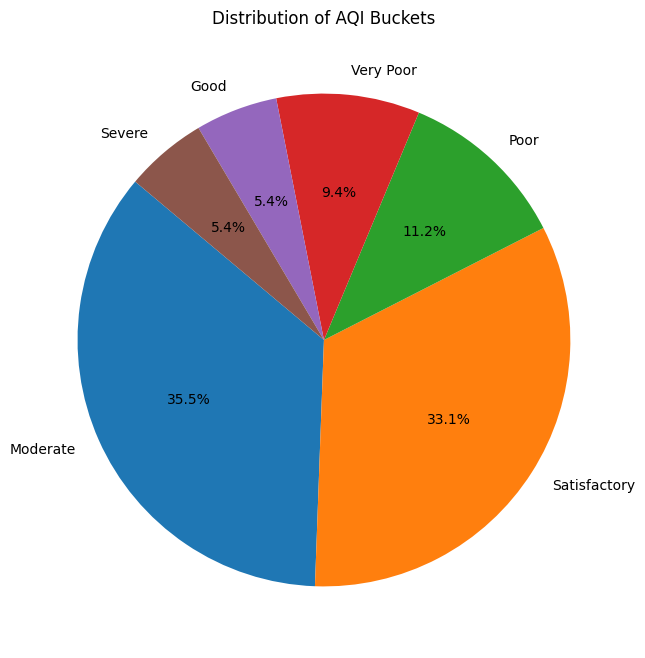

In [9]:
aqi_bucket_percentages = (df["AQI_Bucket"].value_counts() / len(df)) * 100
plt.figure(figsize=(8, 8))
plt.pie(
    aqi_bucket_percentages,
    labels=aqi_bucket_percentages.index,
    autopct="%1.1f%%",
    startangle=140,
)
plt.title("Distribution of AQI Buckets")
plt.show()

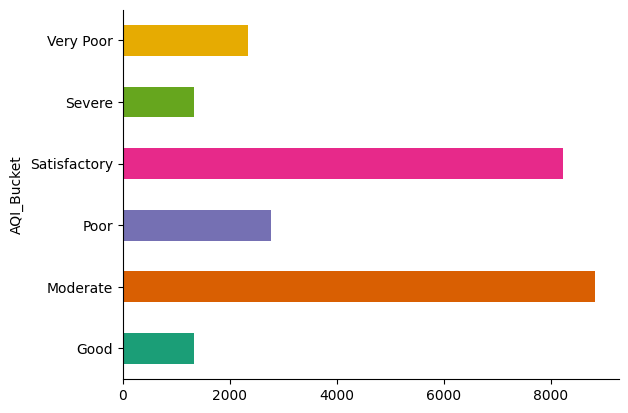

In [ ]:
df.groupby("AQI_Bucket").size().plot(
    kind="barh", color=sns.palettes.mpl_palette("Dark2")
)

plt.gca().spines[
    [
        "top",
        "right",
    ]
].set_visible(False)

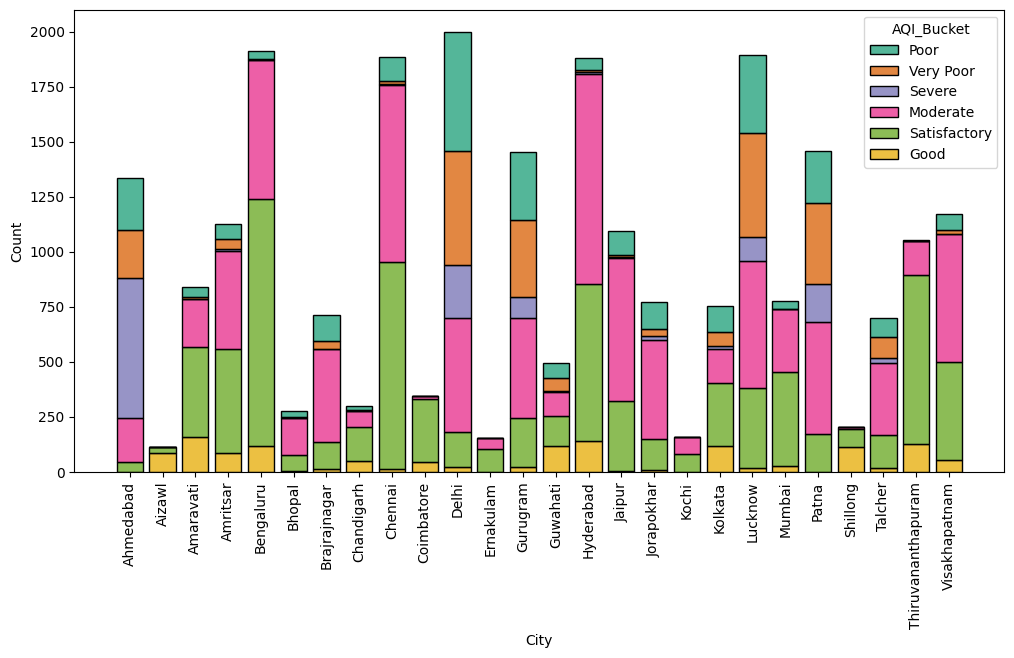

In [11]:
# AQI_Bucket with respect to cities
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df, x="City", hue="AQI_Bucket", palette="Dark2", multiple="stack", shrink=0.8
)
plt.xticks(rotation=90)
plt.show()

In [12]:
def pair_plot(df):
    sns.pairplot(
        df,
        diag_kind="kde",
        markers="+",
        plot_kws=dict(s=50, edgecolor="b", linewidth=1),
        diag_kws=dict(shade=True),
    )

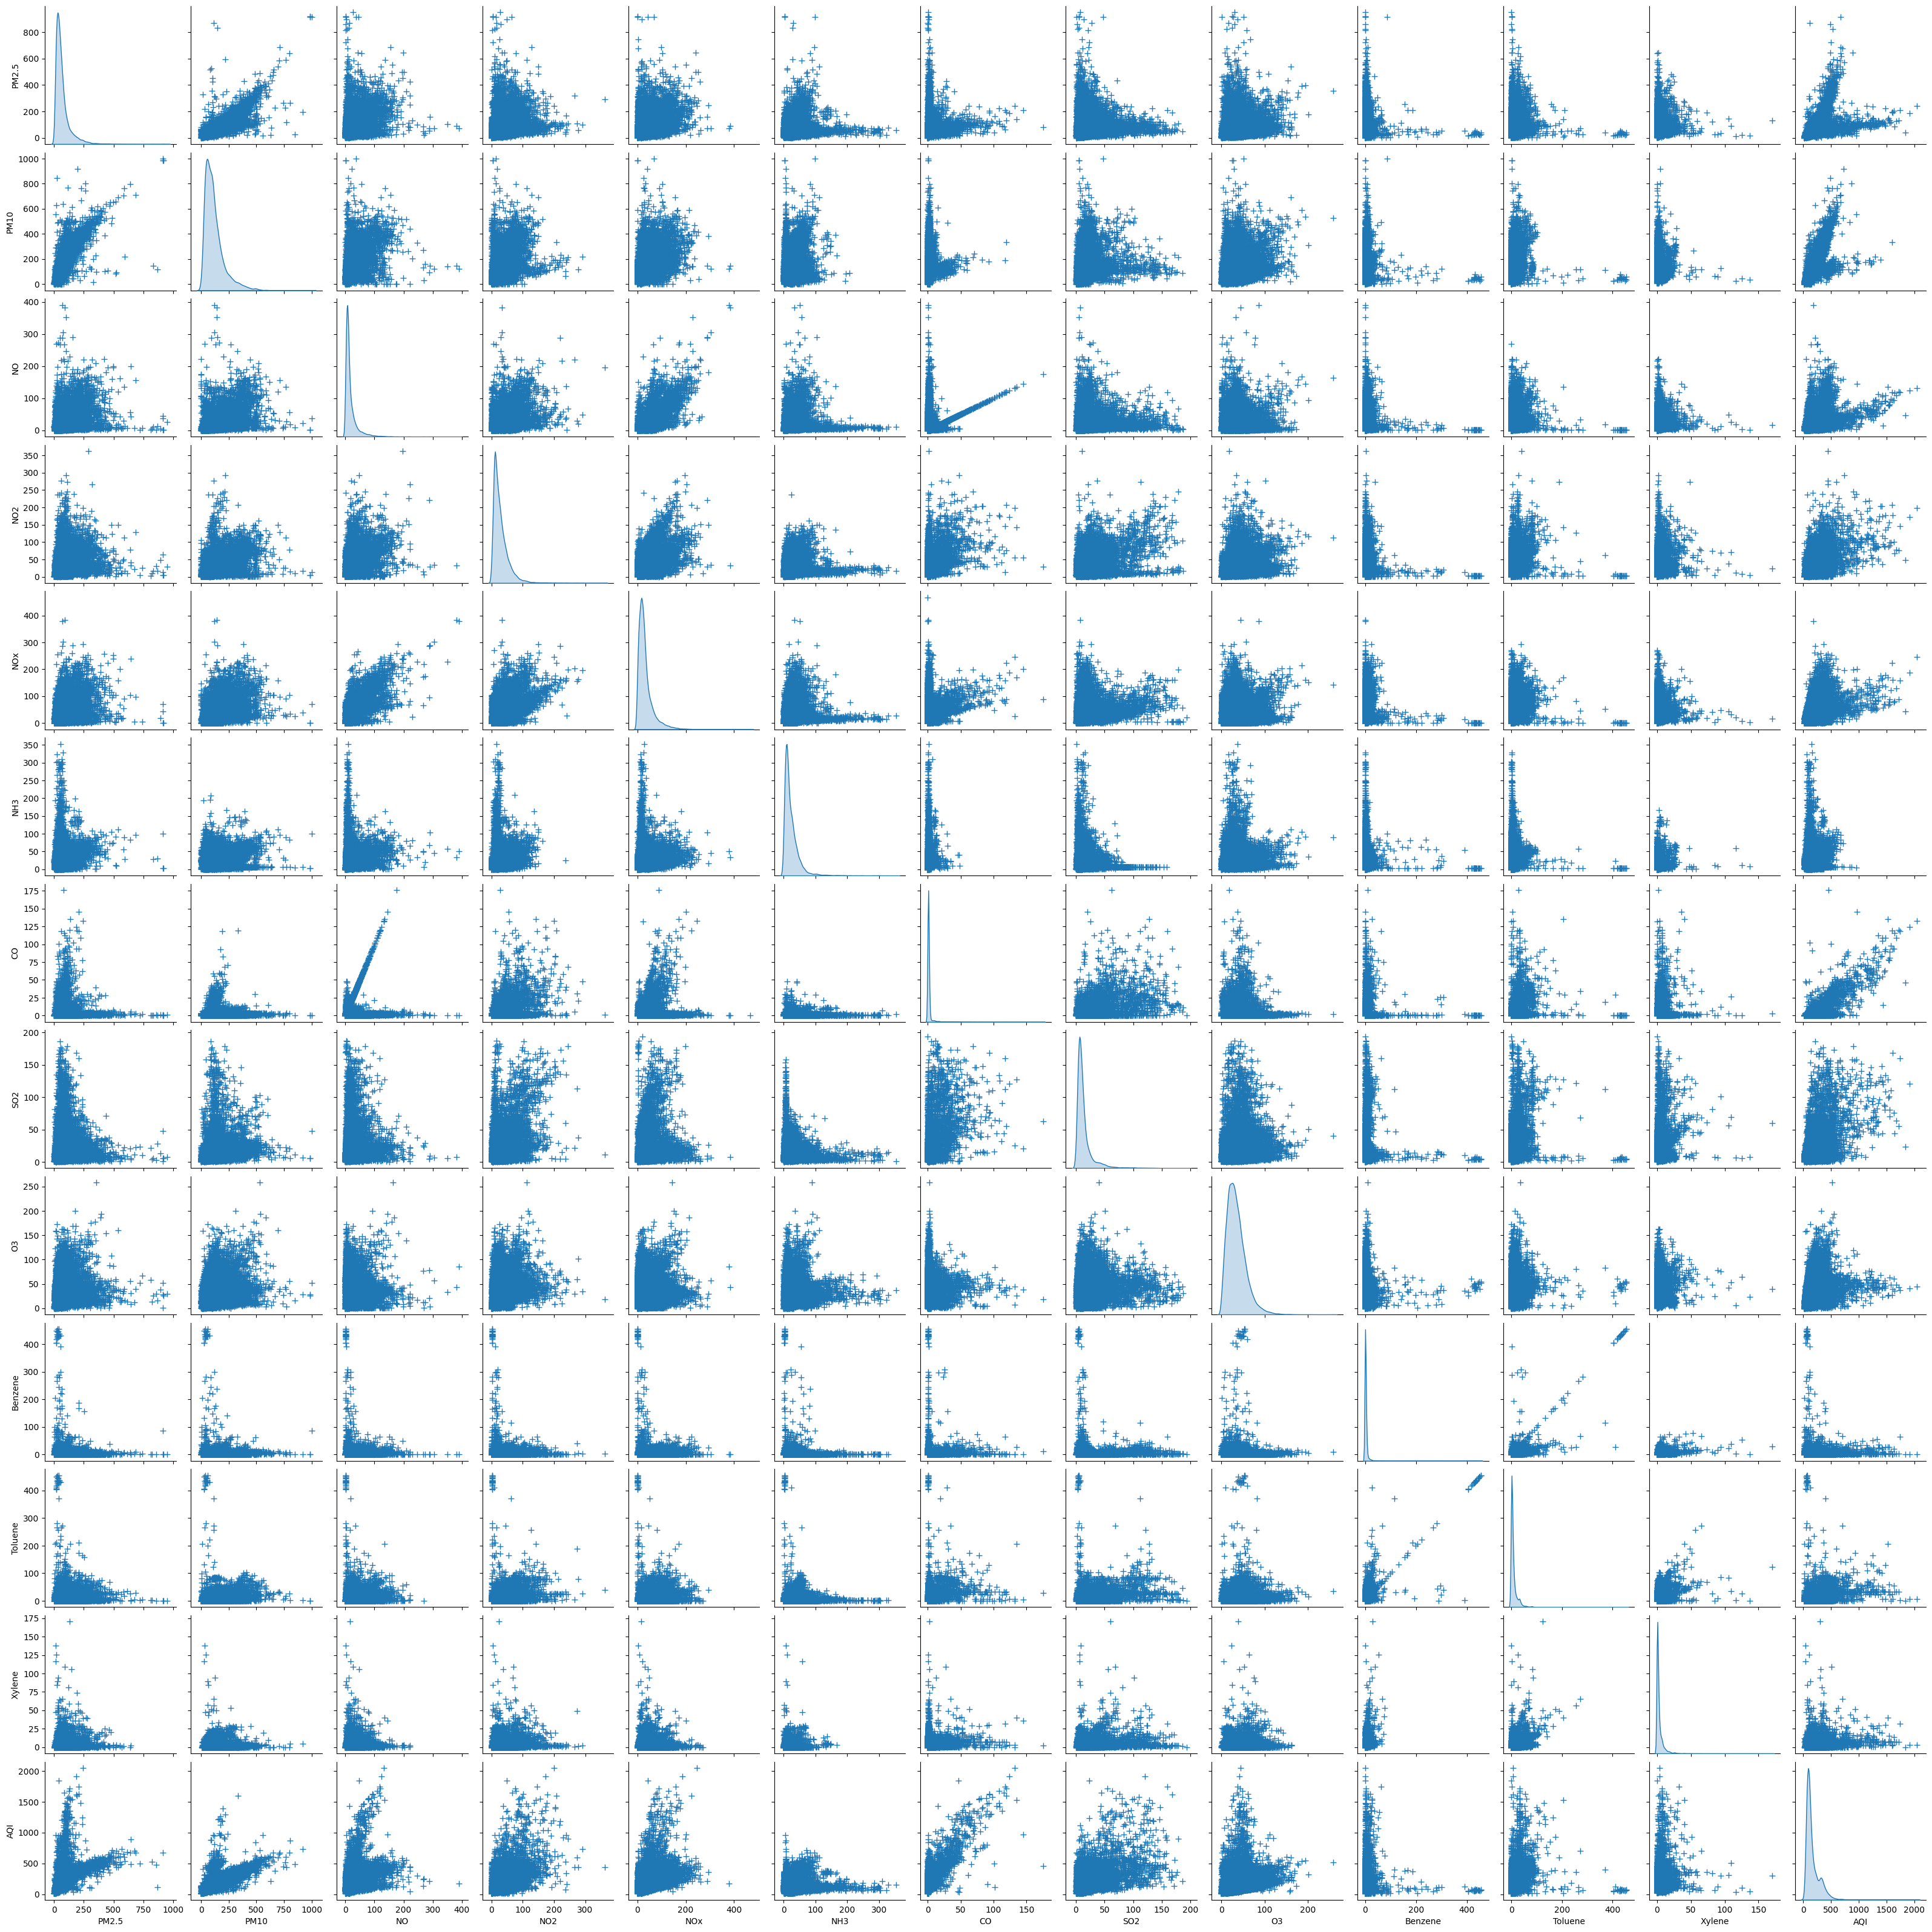

In [13]:
pair_plot(df)

In [14]:
def column_density(df, columns):
    n_rows = len(columns)
    fig, axes = plt.subplots(nrows=n_rows, ncols=1, figsize=(10, 10))

    for i, col in enumerate(columns):
        sns.kdeplot(data=df, x=col, color="red", fill=True, ax=axes[i])

    plt.tight_layout()
    plt.show()

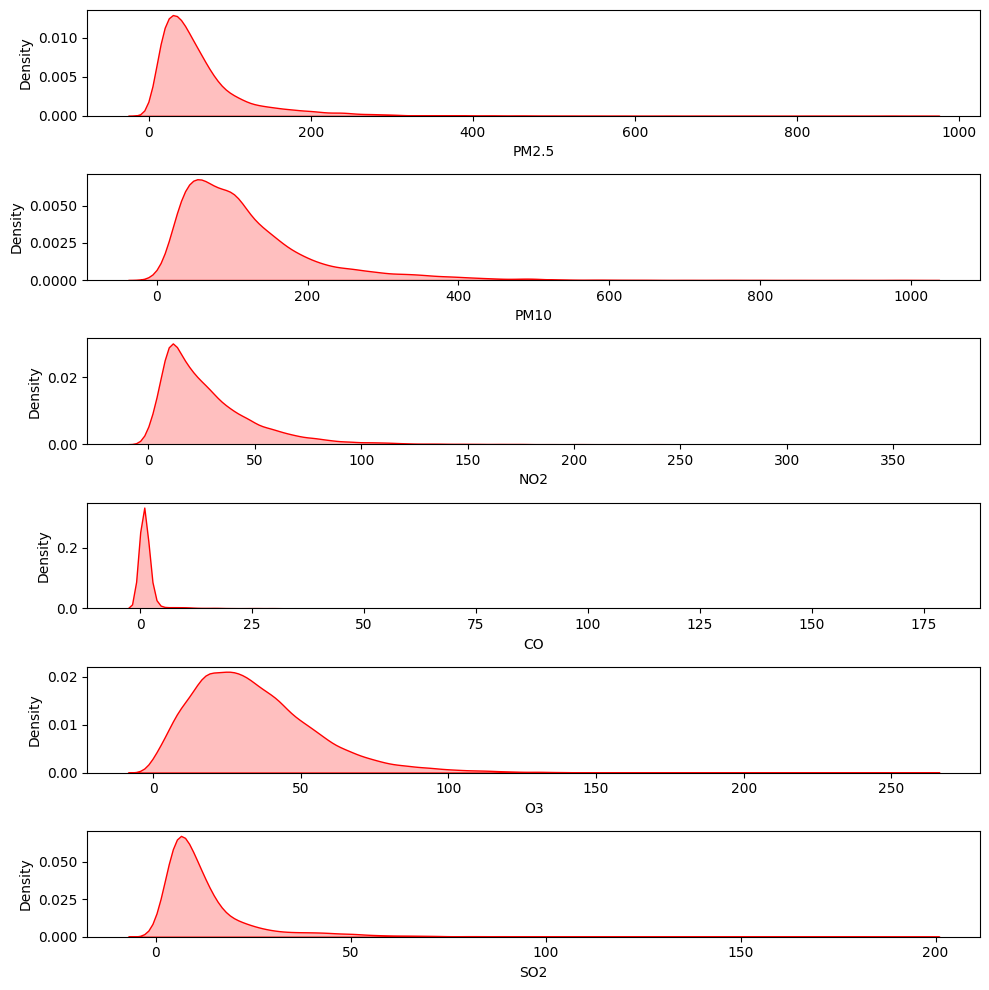

In [15]:
col = ["PM2.5", "PM10", "NO2", "CO", "O3", "SO2"]
column_density(df, col)

In [16]:
def outlier_detection(df, columns):
    n_rows = len(columns)
    fig, axes = plt.subplots(nrows=n_rows, ncols=1, figsize=(10, 25))

    for i, col in enumerate(columns):
        sns.boxplot(
            data=df, x="AQI_Bucket", y=col, palette="Dark2", fill=True, ax=axes[i]
        )
    plt.show()

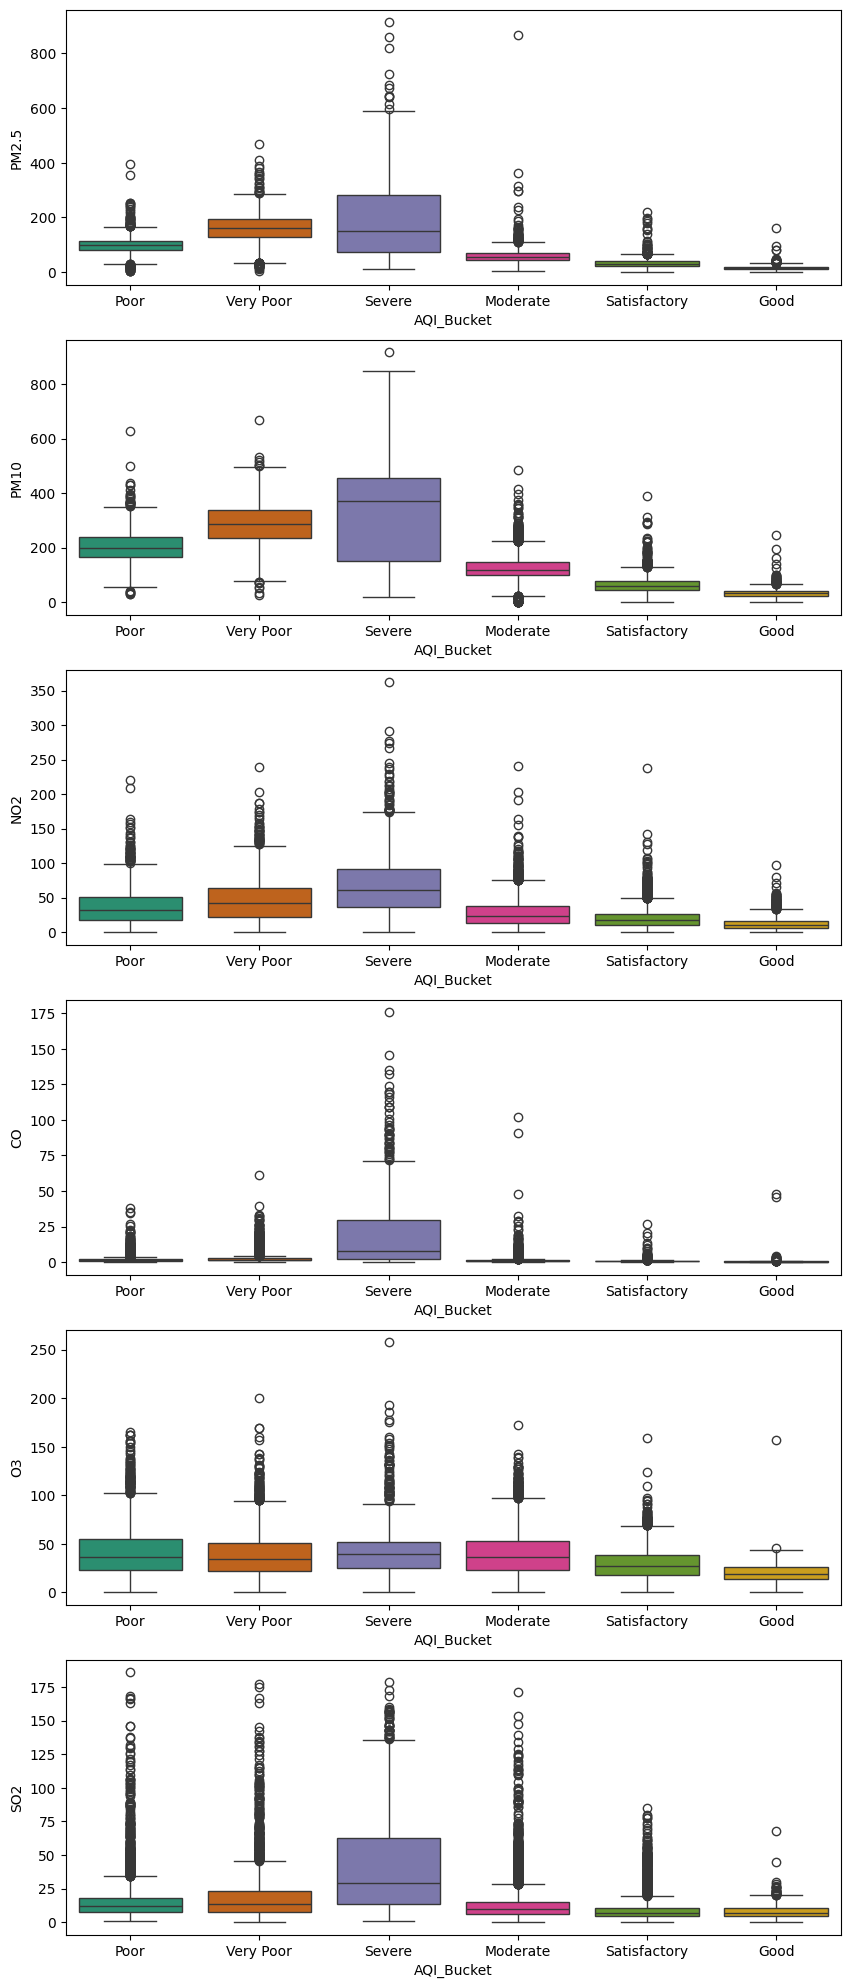

In [17]:
col = ["PM2.5", "PM10", "NO2", "CO", "O3", "SO2"]
outlier_detection(df, col)

### **Filling missing values**


In [18]:
df.isna().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

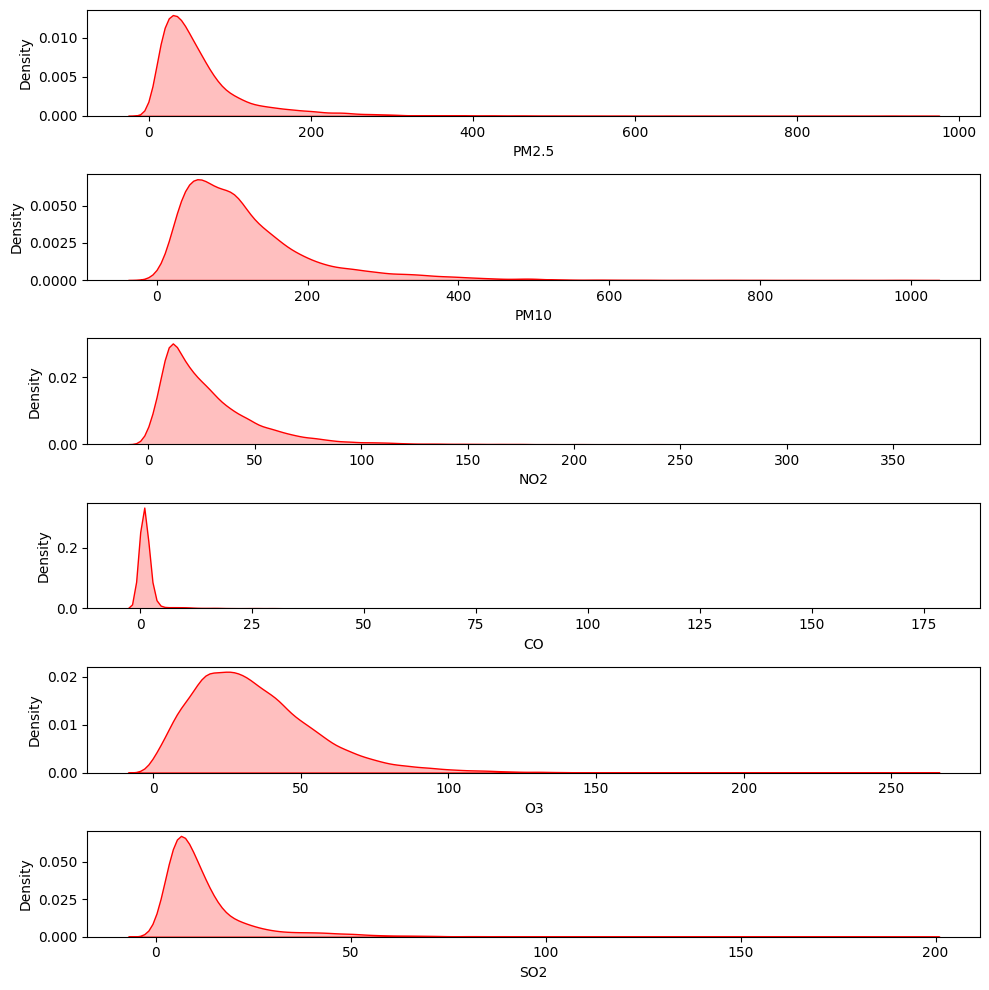

In [19]:
col = ["PM2.5", "PM10", "NO2", "CO", "O3", "SO2"]
column_density(df, col)

### **Correlation matrix**


In [20]:
def plot_corr_matrix(df):
    # Create the correlation matrix
    numeric_columns = df.select_dtypes(include=["float64"]).columns
    plt.figure(figsize=(12, 6))
    correlation_matrix = df[numeric_columns].corr()

    # Generate a heatmap
    sns.heatmap(correlation_matrix, annot=True)
    plt.show()

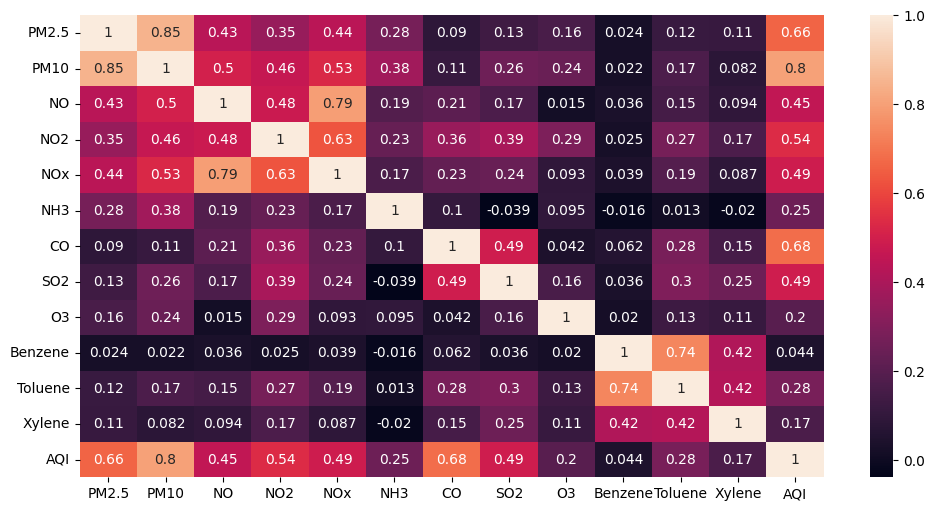

In [21]:
plot_corr_matrix(df)

As we can see in correlation matrix that benzene,toluene and xylene are not contributing so much in predicting AQI.


In [22]:
df.dropna(subset=["AQI_Bucket"], inplace=True)
df.sort_values(by=["City", "AQI_Bucket", "Date"], inplace=True)

In [23]:
df.shape

(24850, 16)

In [24]:
df1 = df.copy()

In [25]:
df1.isna().sum()

City              0
Date              0
PM2.5           678
PM10           7086
NO              387
NO2             391
NOx            1857
NH3            6536
CO              445
SO2             605
O3              807
Benzene        3535
Toluene        5826
Xylene        15372
AQI               0
AQI_Bucket        0
dtype: int64

In [26]:
# Step 1: Exclude specified columns
columns_to_exclude = ["Date", "NOx", "NH3", "Benzene", "Xylene", "Toluene", "AQI"]
columns_to_interpolate = [col for col in df1.columns if col not in columns_to_exclude]

# Perform interpolation and group by 'City' and 'AQI_Bucket'
df1_grouped = df1.groupby(["City", "AQI_Bucket"]).apply(
    lambda x: x[columns_to_interpolate].interpolate(
        method="linear", limit_direction="both"
    )
)

# Merge the interpolated values back to the original DataFrame df1 using index
df1 = df1.set_index(["City", "AQI_Bucket"]).combine_first(
    df1_grouped.set_index(["City", "AQI_Bucket"])
)

# Reset the index
df1.reset_index(inplace=True)

In [27]:
print(df1.columns)

Index(['City', 'AQI_Bucket', 'AQI', 'Benzene', 'CO', 'Date', 'NH3', 'NO',
       'NO2', 'NOx', 'O3', 'PM10', 'PM2.5', 'SO2', 'Toluene', 'Xylene'],
      dtype='object')


In [28]:
cols_to_drop = ["NOx", "NH3", "Benzene", "Xylene", "Toluene"]
df1.drop(columns=df1.columns.intersection(cols_to_drop), inplace=True)

In [29]:
df1.sort_values(by=["City", "AQI_Bucket", "Date"], inplace=True)
df1.head()

,City,AQI_Bucket,AQI,CO,Date,NO,NO2,O3,PM10,PM2.5,SO2
0,Ahmedabad,Good,48.0,0.06,2015-07-24,0.06,9.57,5.08,NaN,29.22,13.58
1,Ahmedabad,Moderate,149.0,2.60,2015-02-05,2.60,21.39,53.54,152.67,58.36,32.66
2,Ahmedabad,Moderate,190.0,1.16,2015-02-06,1.16,26.94,59.30,152.67,79.29,67.41
3,Ahmedabad,Moderate,189.0,9.07,2015-03-02,9.07,18.21,34.75,152.67,60.78,29.48
4,Ahmedabad,Moderate,190.0,3.51,2015-03-08,3.51,16.83,57.16,152.67,71.56,30.28


In [30]:
# For DataFrame df
df_selection = df[(df["City"] == "Ahmedabad") & (df["AQI_Bucket"] == "Moderate")]

# For DataFrame df1
df1_selection = df1[(df1["City"] == "Ahmedabad") & (df1["AQI_Bucket"] == "Moderate")]

In [31]:
df_selection.isna().sum()

City            0
Date            0
PM2.5           1
PM10          103
NO              4
NO2             4
NOx             1
NH3           198
CO              4
SO2            31
O3              7
Benzene         9
Toluene         9
Xylene          9
AQI             0
AQI_Bucket      0
dtype: int64

In [32]:
len(df_selection)

198

In [33]:
print(df_selection)
print(df1_selection)

           City       Date  PM2.5    PM10     NO    NO2    NOx  NH3    CO  \
35    Ahmedabad 2015-02-05  58.36     NaN   2.60  21.39  23.31  NaN  2.60   
36    Ahmedabad 2015-02-06  79.29     NaN   1.16  26.94  26.83  NaN  1.16   
60    Ahmedabad 2015-03-02  60.78     NaN   9.07  18.21  27.34  NaN  9.07   
66    Ahmedabad 2015-03-08  71.56     NaN   3.51  16.83  20.32  NaN  3.51   
74    Ahmedabad 2015-03-16  30.76     NaN   2.72  14.14  16.98  NaN  2.72   
...         ...        ...    ...     ...    ...    ...    ...  ...   ...   
1989  Ahmedabad 2020-06-12  21.40   93.89   5.28  22.40  14.85  NaN  0.85   
1996  Ahmedabad 2020-06-19  17.65  135.16  19.86  33.84  22.86  NaN  0.71   
1997  Ahmedabad 2020-06-20  22.90  120.70  11.79  15.81  10.10  NaN  0.50   
1998  Ahmedabad 2020-06-21  24.28  138.12   3.45  12.44   8.23  NaN  0.70   
2008  Ahmedabad 2020-07-01  37.63     NaN   4.42  35.04  20.17  NaN  0.28   

        SO2     O3  Benzene  Toluene  Xylene    AQI AQI_Bucket  
35    32.6

In [34]:
df.drop(["NOx", "NH3", "Benzene", "Xylene", "Toluene"], axis=1).sort_values(
    by=["City", "AQI_Bucket", "Date"], inplace=True
)


df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
204,Ahmedabad,2015-07-24,29.22,NaN,0.06,9.57,7.77,NaN,0.06,13.58,5.08,1.37,3.65,0.32,48.0,Good
35,Ahmedabad,2015-02-05,58.36,NaN,2.60,21.39,23.31,NaN,2.60,32.66,53.54,0.00,0.00,0.00,149.0,Moderate
36,Ahmedabad,2015-02-06,79.29,NaN,1.16,26.94,26.83,NaN,1.16,67.41,59.30,0.00,0.00,0.00,190.0,Moderate
60,Ahmedabad,2015-03-02,60.78,NaN,9.07,18.21,27.34,NaN,9.07,29.48,34.75,2.05,0.55,0.22,189.0,Moderate
66,Ahmedabad,2015-03-08,71.56,NaN,3.51,16.83,20.32,NaN,3.51,30.28,57.16,3.95,8.01,0.63,190.0,Moderate


In [35]:
df1.isna().sum()

City             0
AQI_Bucket       0
AQI              0
CO               0
Date             0
NO               0
NO2              0
O3             174
PM10          1900
PM2.5           18
SO2             21
dtype: int64

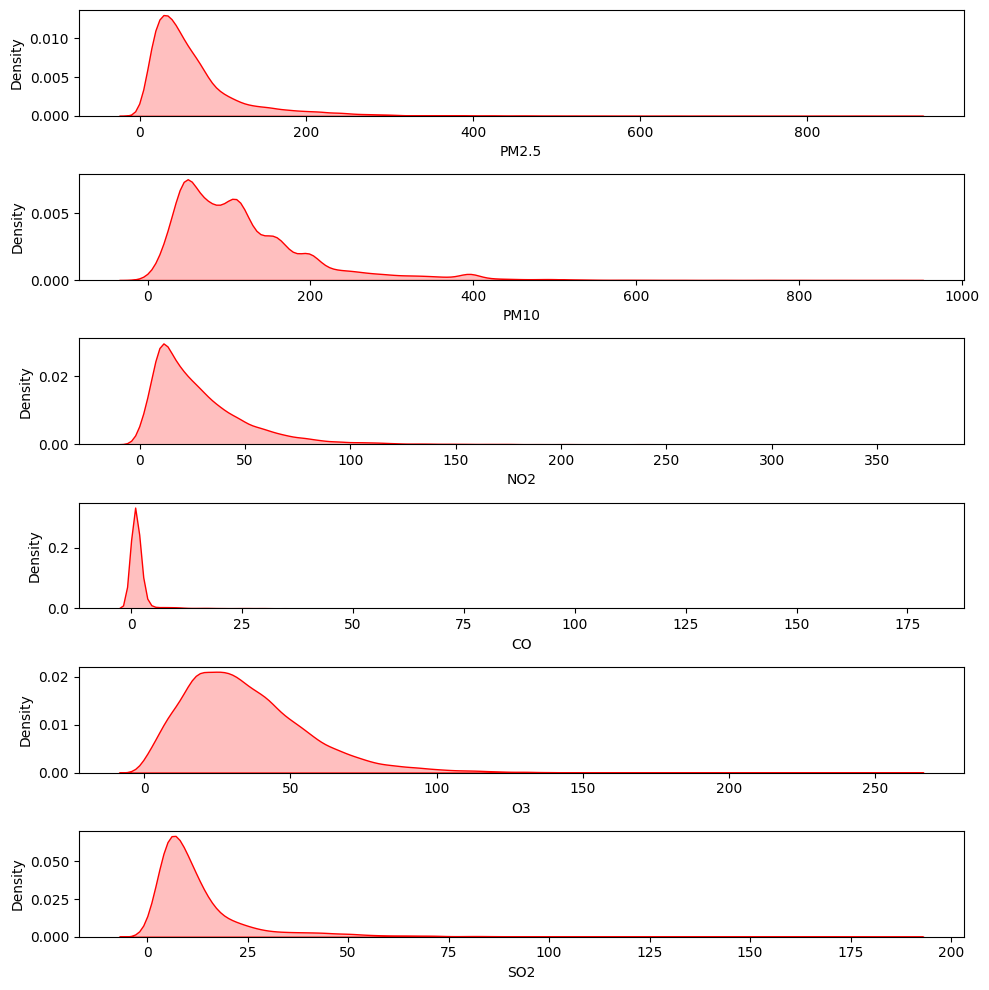

In [36]:
col = ["PM2.5", "PM10", "NO2", "CO", "O3", "SO2"]
column_density(df1, col)

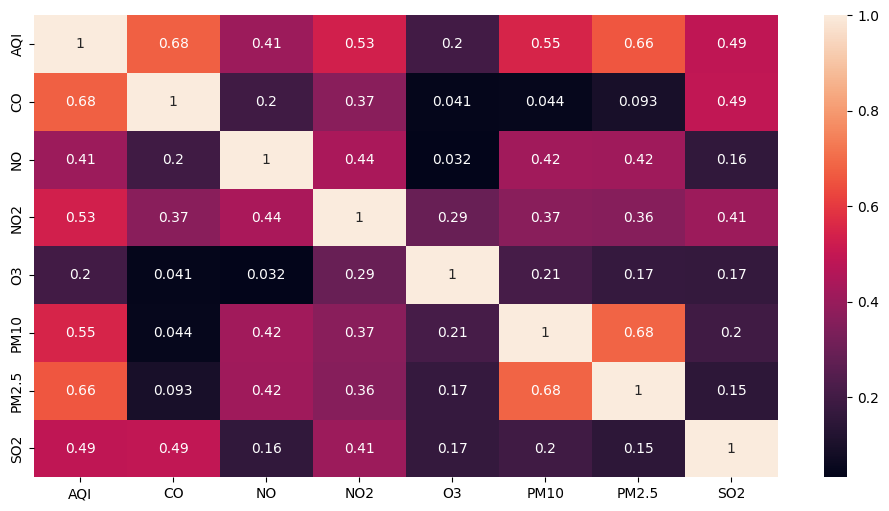

In [37]:
plot_corr_matrix(df1)

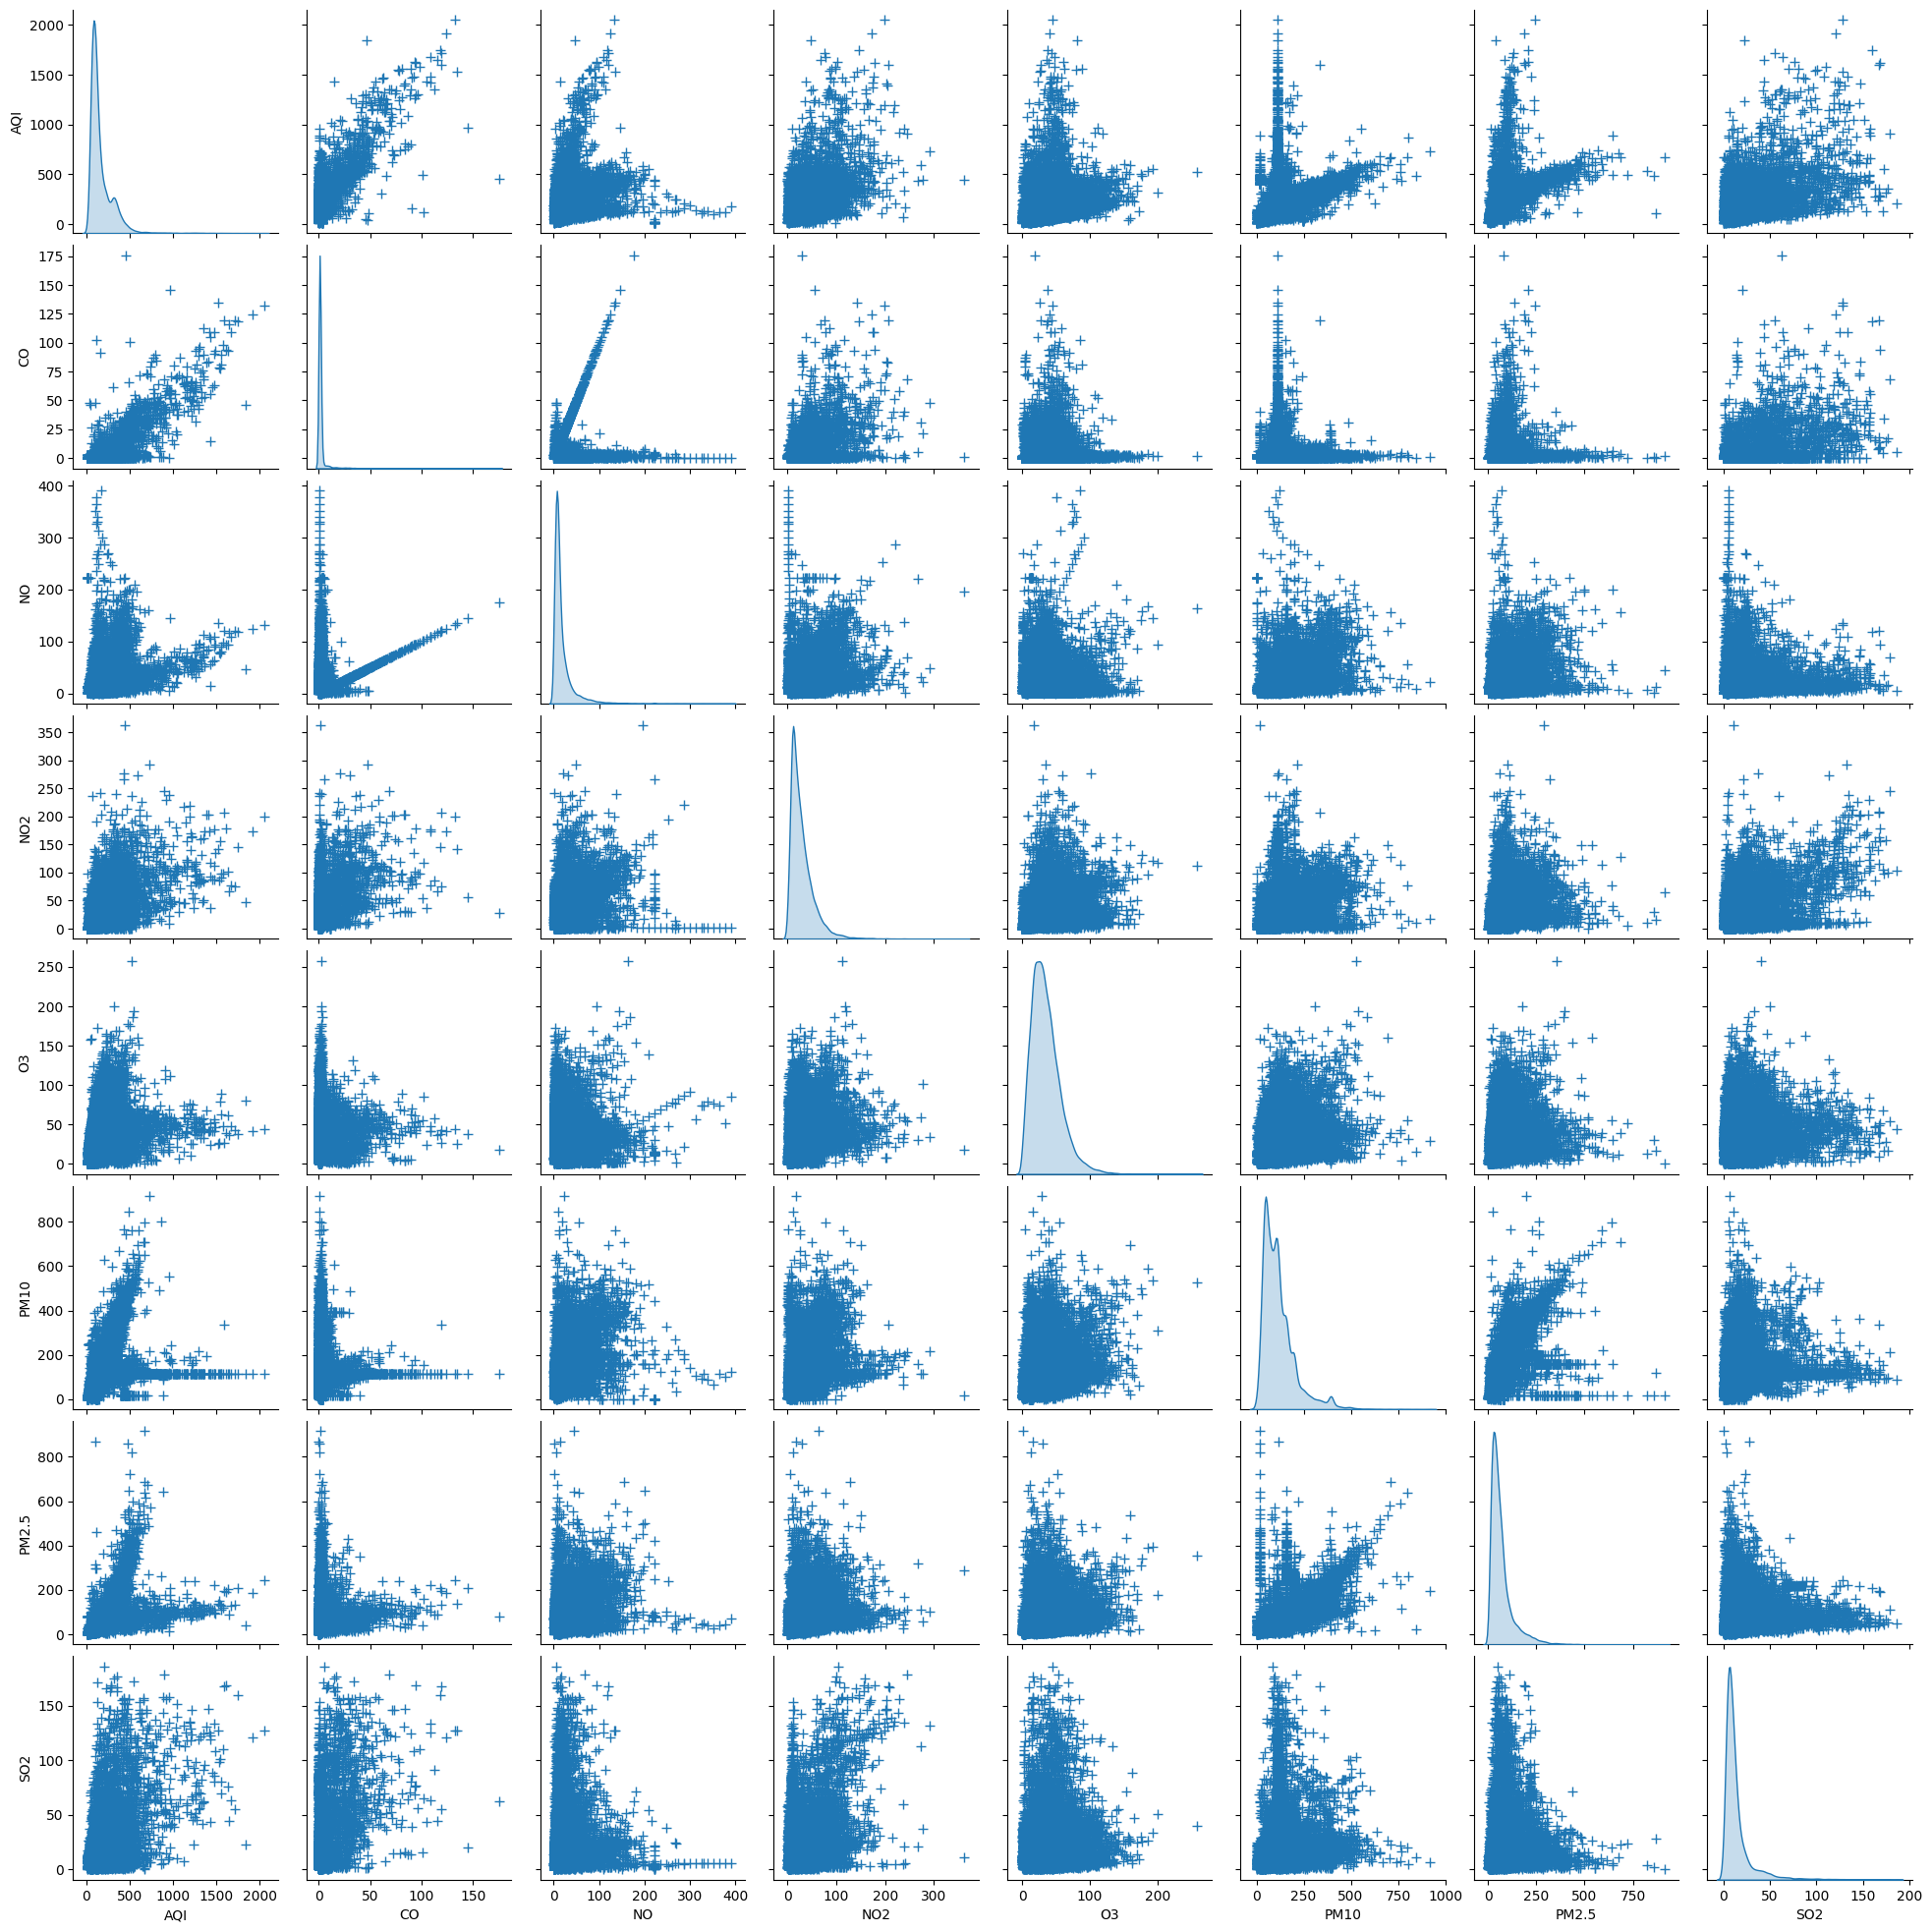

In [38]:
pair_plot(df1)

In [39]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24850 entries, 0 to 24849
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        24850 non-null  object        
 1   AQI_Bucket  24850 non-null  object        
 2   AQI         24850 non-null  float64       
 3   CO          24850 non-null  float64       
 4   Date        24850 non-null  datetime64[ns]
 5   NO          24850 non-null  float64       
 6   NO2         24850 non-null  float64       
 7   O3          24676 non-null  float64       
 8   PM10        22950 non-null  float64       
 9   PM2.5       24832 non-null  float64       
 10  SO2         24829 non-null  float64       
dtypes: datetime64[ns](1), float64(8), object(2)
memory usage: 2.1+ MB


In [40]:
df1.isna().sum()

City             0
AQI_Bucket       0
AQI              0
CO               0
Date             0
NO               0
NO2              0
O3             174
PM10          1900
PM2.5           18
SO2             21
dtype: int64

In [41]:
# Assuming df1 is your DataFrame
df2 = df1.copy()

# Columns to fill with interpolation
columns_to_fill = ["O3", "PM10", "PM2.5", "SO2", "City"]

# Perform interpolation and group by 'City'
df2_grouped = df2.groupby(["City"]).apply(
    lambda x: x[columns_to_fill].interpolate(method="linear", limit_direction="both")
)

# Merge the interpolated values back to the original DataFrame df2 using index
df2 = df2.set_index(["City"]).combine_first(df2_grouped.set_index(["City"]))

# Reset the index
df2.reset_index(inplace=True)

In [42]:
df2["City"].value_counts()

City
Delhi                 1999
Bengaluru             1910
Lucknow               1893
Chennai               1884
Hyderabad             1880
Patna                 1459
Gurugram              1453
Ahmedabad             1334
Visakhapatnam         1171
Amritsar              1126
Jaipur                1094
Thiruvananthapuram    1052
Amaravati              841
Mumbai                 775
Jorapokhar             771
Kolkata                754
Brajrajnagar           713
Talcher                698
Guwahati               495
Coimbatore             344
Chandigarh             299
Bhopal                 278
Shillong               205
Kochi                  158
Ernakulam              153
Aizawl                 111
Name: count, dtype: int64

In [43]:
df1.isna().sum()

City             0
AQI_Bucket       0
AQI              0
CO               0
Date             0
NO               0
NO2              0
O3             174
PM10          1900
PM2.5           18
SO2             21
dtype: int64

In [44]:
df2.isna().sum()

City             0
AQI              0
AQI_Bucket       0
CO               0
Date             0
NO               0
NO2              0
O3             153
PM10          1893
PM2.5            0
SO2              0
dtype: int64

In [45]:
# For DataFrame df2
df2_selection = df2[(df2["City"] == "Delhi")]
df1_selection = df1[(df1["City"] == "Delhi")]

# Reset indices for both DataFrames
df1_selection.reset_index(drop=True, inplace=True)
df2_selection.reset_index(drop=True, inplace=True)

# Ensure both DataFrames have the same column order
df1_selection = df1_selection[df2_selection.columns]

# Iterate over each row and find modified values
modified_values = []

for idx in range(len(df1_selection)):
    row1 = set(df1_selection.iloc[idx])
    row2 = set(df2_selection.iloc[idx])
    differences = row1.symmetric_difference(row2)
    if differences:
        modified_values.append((idx, differences))

# Display modified values
for idx, values in modified_values:
    print(f"Row {idx}:")
    for value in values:
        print(value)
    print()

Row 0:
2.65
nan
19.71
nan

Row 1:
nan
2.65
19.71
nan

Row 2:
2.65
nan
19.71
nan

Row 3:
2.65
nan
19.71
nan

Row 4:
2.65
nan
19.71
nan

Row 5:
2.65
nan
19.71
nan

Row 6:
2.65
nan
19.71
nan

Row 7:
2.65
nan
19.71
nan

Row 8:
2.65
nan
19.71
nan

Row 9:
2.65
nan
19.71
nan

Row 10:
2.65
nan
19.71
nan

Row 11:
2.65
19.71
nan
nan

Row 12:
2.65
nan
19.71
nan

Row 13:
2.65
nan
nan
19.71

Row 14:
2.65
nan
19.71
nan

Row 15:
2.65
nan
19.71
nan

Row 16:
nan
2.65
nan
19.71

Row 17:
2.65
nan
19.71
nan

Row 18:
2.65
nan
19.71
nan

Row 19:
2.65
nan
19.71
nan

Row 20:
2.65
nan
nan
19.71



In [46]:
df1_selection.isna().sum()

City           0
AQI            0
AQI_Bucket     0
CO             0
Date           0
NO             0
NO2            0
O3            21
PM10           0
PM2.5          0
SO2           21
dtype: int64

In [47]:
df1_selection.head(25)

,City,AQI,AQI_Bucket,CO,Date,NO,NO2,O3,PM10,PM2.5,SO2
0,Delhi,46.0,Good,0.00,2017-06-30,44.88,32.97,NaN,90.41,25.830,NaN
1,Delhi,49.0,Good,0.00,2017-07-03,28.86,20.06,NaN,246.98,46.710,NaN
2,Delhi,47.0,Good,0.00,2017-07-12,25.59,19.98,NaN,246.98,22.350,NaN
3,Delhi,39.0,Good,0.00,2017-07-13,25.51,21.59,NaN,246.98,22.440,NaN
4,Delhi,40.0,Good,0.00,2017-07-14,17.20,38.36,NaN,246.98,30.350,NaN
5,Delhi,30.0,Good,0.00,2017-07-22,20.65,19.90,NaN,246.98,18.540,NaN
6,Delhi,37.0,Good,0.00,2017-07-23,18.67,18.22,NaN,246.98,22.650,NaN
7,Delhi,35.0,Good,0.00,2017-07-24,28.89,19.95,NaN,246.98,17.520,NaN
8,Delhi,37.0,Good,0.00,2017-07-25,21.08,18.10,NaN,246.98,22.170,NaN
9,Delhi,32.0,Good,0.00,2017-07-26,20.61,21.95,NaN,246.98,20.170,NaN


In [48]:
df2_selection.head(25)

,City,AQI,AQI_Bucket,CO,Date,NO,NO2,O3,PM10,PM2.5,SO2
0,Delhi,46.0,Good,0.00,2017-06-30,44.88,32.97,19.71,90.41,25.830,2.65
1,Delhi,49.0,Good,0.00,2017-07-03,28.86,20.06,19.71,246.98,46.710,2.65
2,Delhi,47.0,Good,0.00,2017-07-12,25.59,19.98,19.71,246.98,22.350,2.65
3,Delhi,39.0,Good,0.00,2017-07-13,25.51,21.59,19.71,246.98,22.440,2.65
4,Delhi,40.0,Good,0.00,2017-07-14,17.20,38.36,19.71,246.98,30.350,2.65
5,Delhi,30.0,Good,0.00,2017-07-22,20.65,19.90,19.71,246.98,18.540,2.65
6,Delhi,37.0,Good,0.00,2017-07-23,18.67,18.22,19.71,246.98,22.650,2.65
7,Delhi,35.0,Good,0.00,2017-07-24,28.89,19.95,19.71,246.98,17.520,2.65
8,Delhi,37.0,Good,0.00,2017-07-25,21.08,18.10,19.71,246.98,22.170,2.65
9,Delhi,32.0,Good,0.00,2017-07-26,20.61,21.95,19.71,246.98,20.170,2.65


In [49]:
df2.isna().sum()

City             0
AQI              0
AQI_Bucket       0
CO               0
Date             0
NO               0
NO2              0
O3             153
PM10          1893
PM2.5            0
SO2              0
dtype: int64

In [50]:
# Columns to fill with ffill and bfill method
columns_to_fill = ["O3", "PM10"]

# Perform filling with ffill method
df2[columns_to_fill] = df2.groupby(["AQI_Bucket"])[columns_to_fill].fillna(
    method="ffill"
)

# Perform filling with bfill method
df2[columns_to_fill] = df2.groupby(["AQI_Bucket"])[columns_to_fill].fillna(
    method="bfill"
)

# Reset the index
df2.reset_index(drop=True, inplace=True)

In [51]:
df2.isna().sum()

City          0
AQI           0
AQI_Bucket    0
CO            0
Date          0
NO            0
NO2           0
O3            0
PM10          0
PM2.5         0
SO2           0
dtype: int64

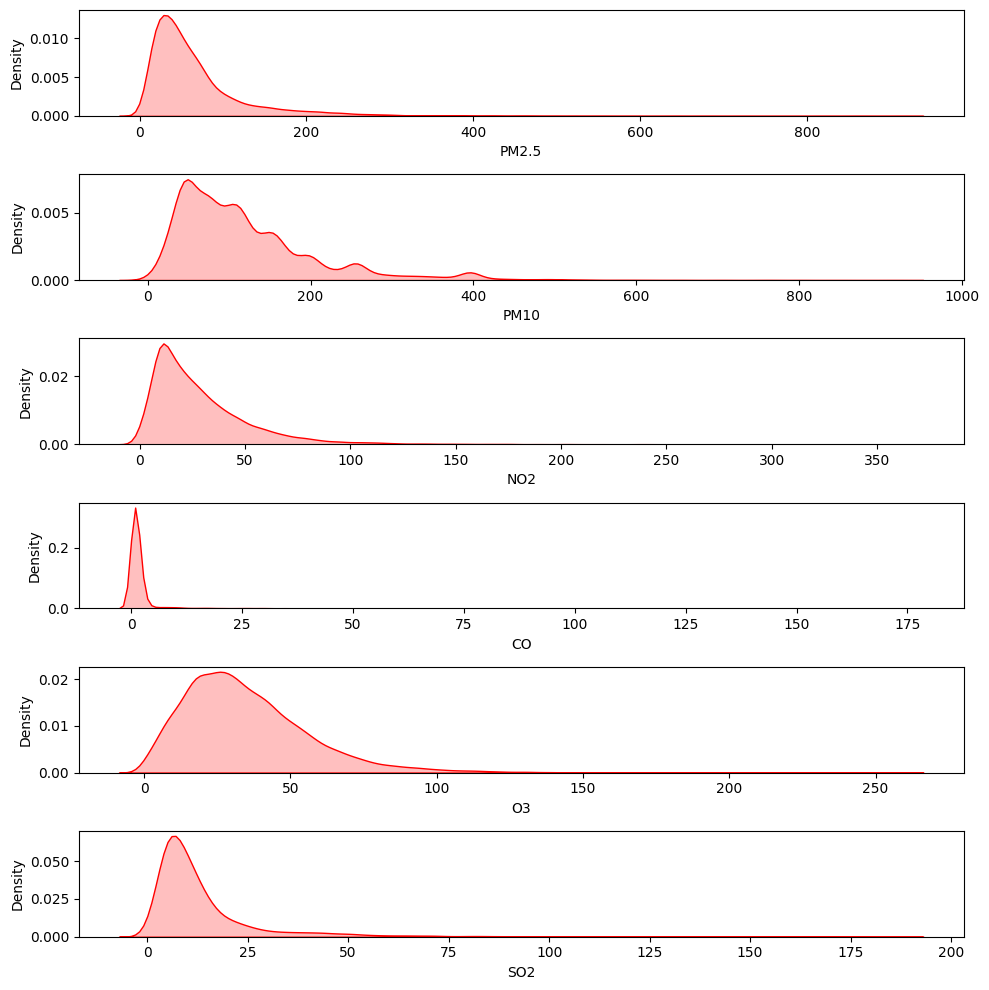

In [52]:
col = ["PM2.5", "PM10", "NO2", "CO", "O3", "SO2"]
column_density(df2, col)

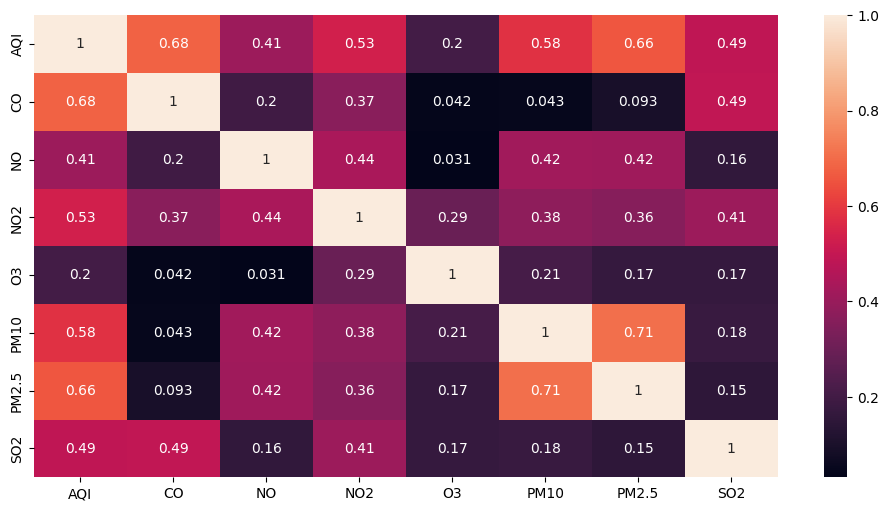

In [53]:
plot_corr_matrix(df2)

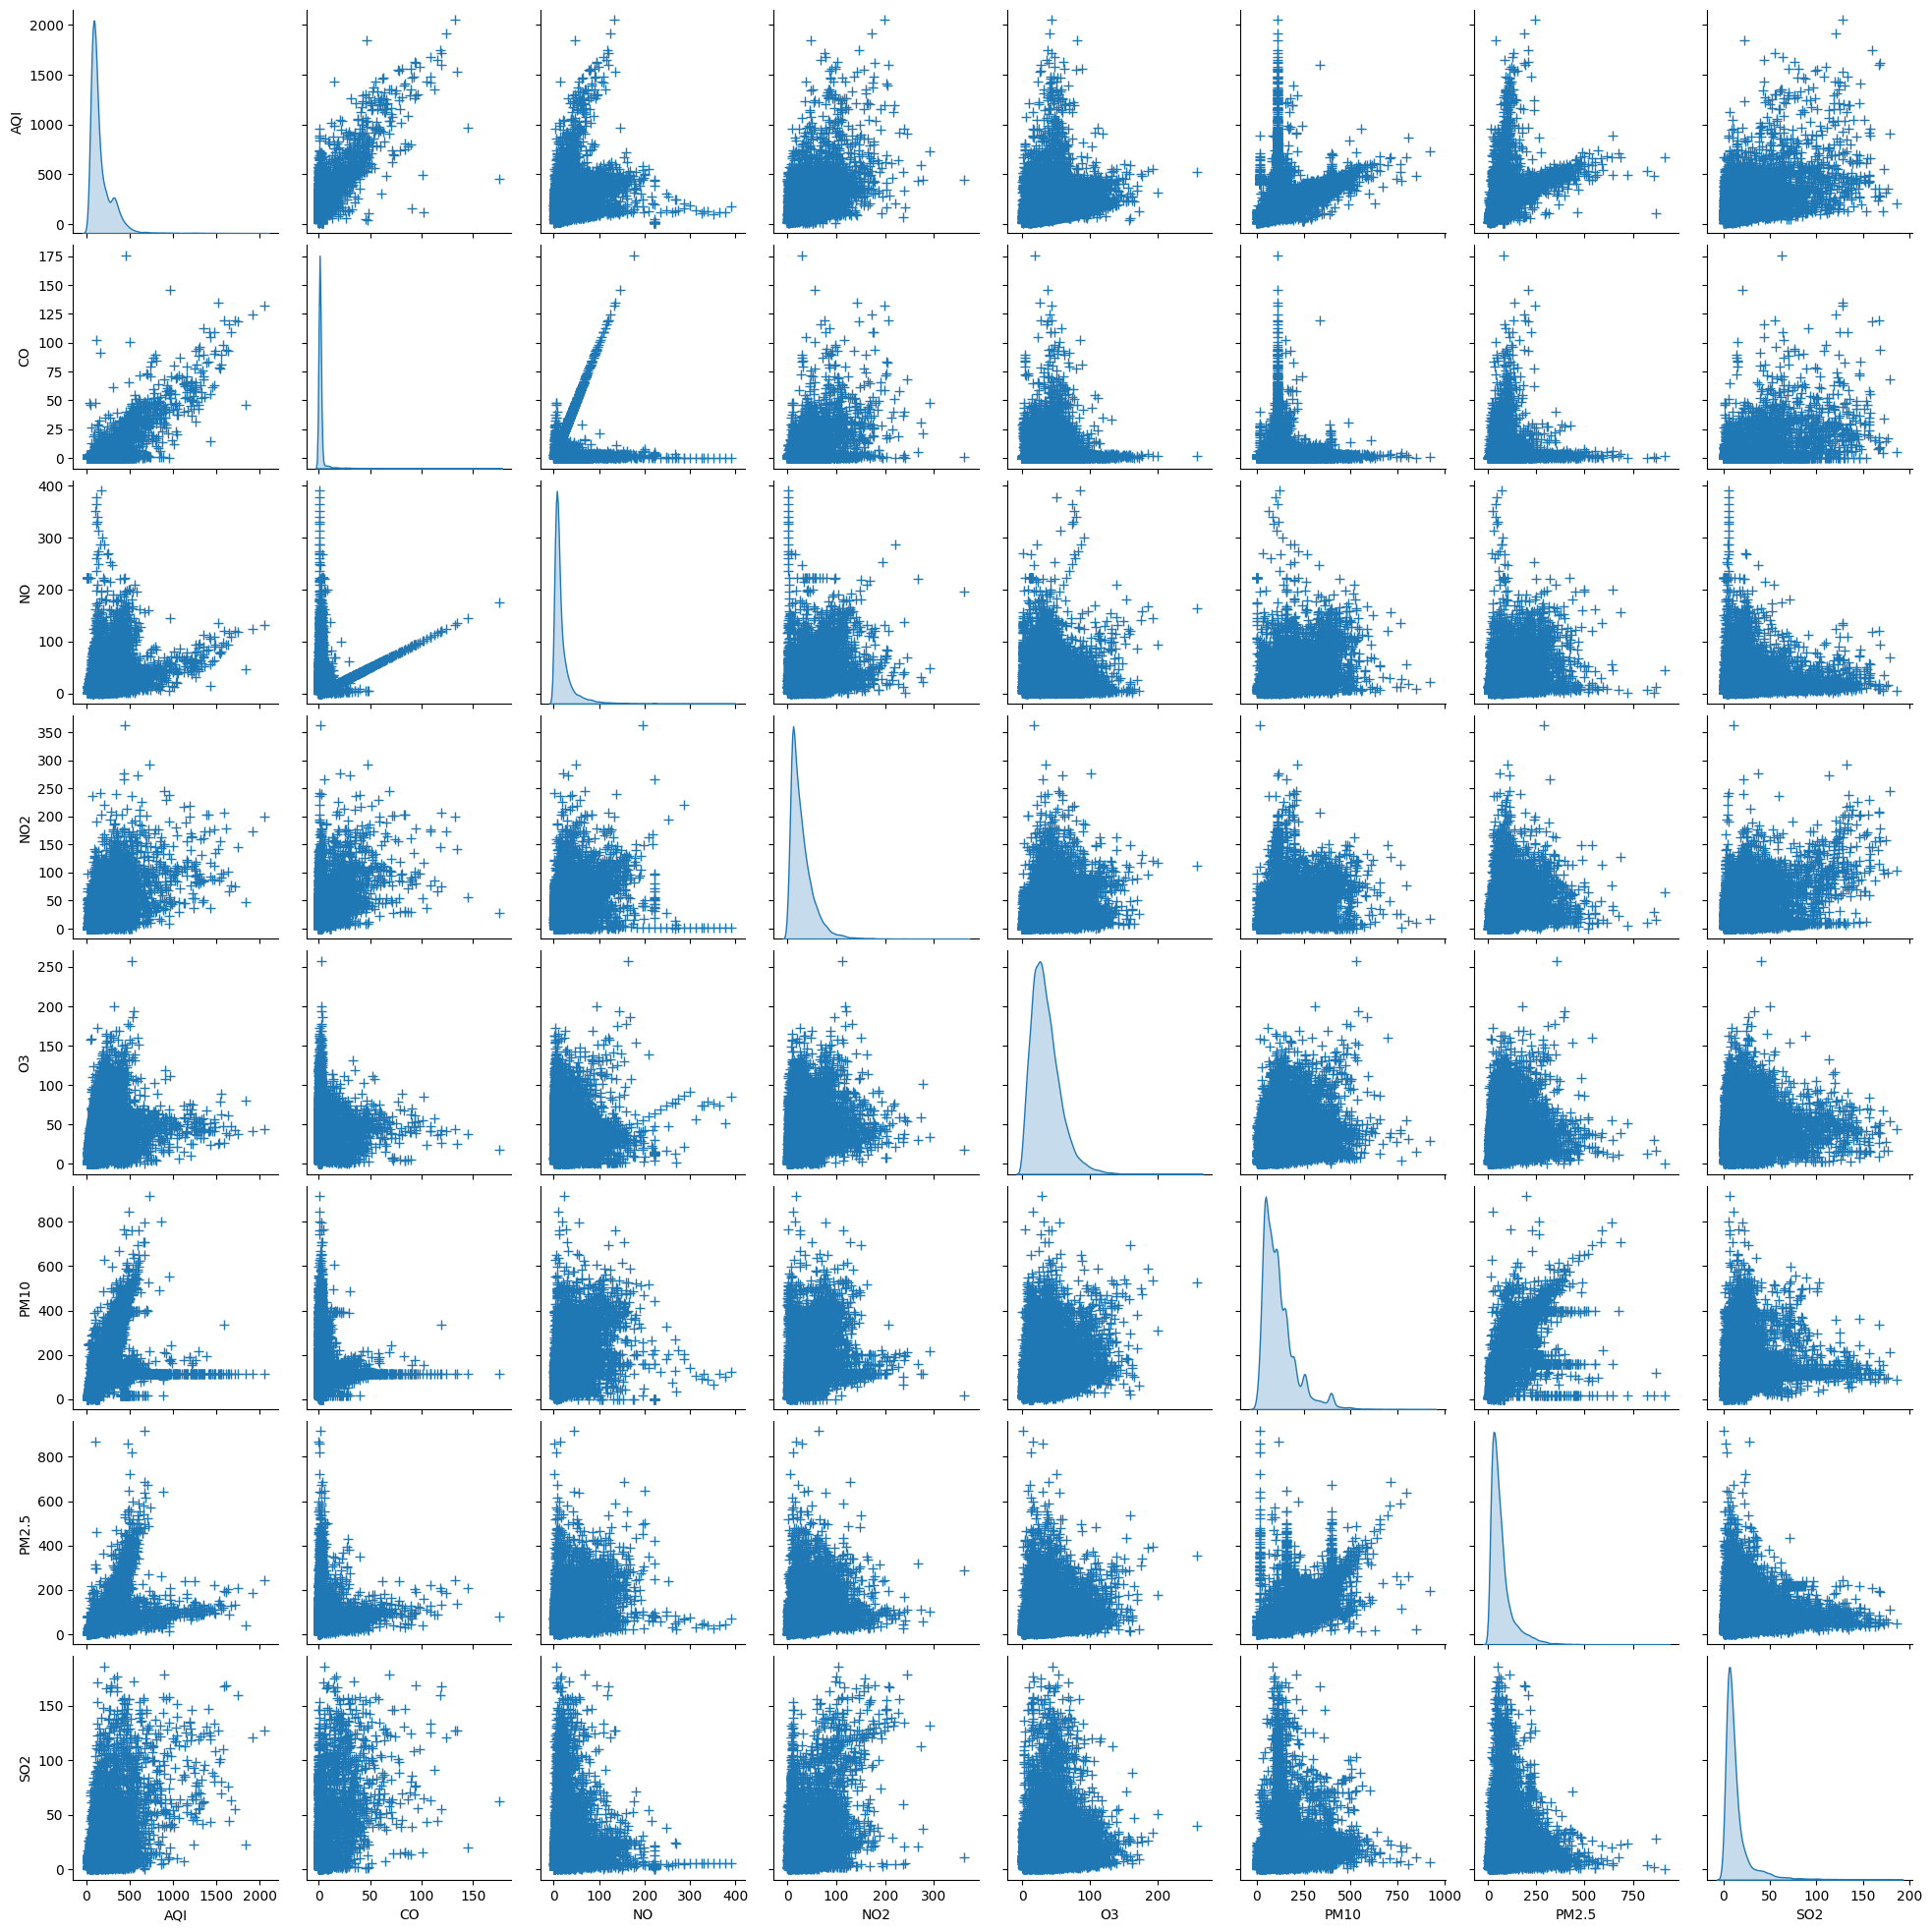

In [54]:
pair_plot(df2)

In [55]:
# Specify the desired column order
desired_column_order = [
    "City",
    "Date",
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "CO",
    "SO2",
    "O3",
    "AQI",
    "AQI_Bucket",
]

# Reorder columns of df2
df2 = df2[desired_column_order]

In [56]:
df.describe()

,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24850,24172.000000,17764.000000,24463.000000,24459.000000,22993.000000,18314.000000,24405.000000,24245.000000,24043.000000,21315.000000,19024.000000,9478.000000,24850.000000
mean,2018-07-24 18:51:25.714285824,67.476613,118.454435,17.622421,28.978391,32.289012,23.848366,2.345267,14.362933,34.912885,3.458668,9.525714,3.588683,166.463581
min,2015-01-01 00:00:00,0.040000,0.030000,0.030000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,2017-08-16 00:00:00,29.000000,56.777500,5.660000,11.940000,13.110000,8.960000,0.590000,5.730000,19.250000,0.230000,1.027500,0.390000,81.000000
50%,2018-11-05 00:00:00,48.785000,96.180000,9.910000,22.100000,23.680000,16.310000,0.930000,9.220000,31.250000,1.290000,3.575000,1.420000,118.000000
75%,2019-10-11 00:00:00,80.925000,150.182500,20.030000,38.240000,40.170000,30.360000,1.480000,15.140000,46.080000,3.340000,10.180000,4.120000,208.000000
max,2020-07-01 00:00:00,914.940000,917.080000,390.680000,362.210000,378.240000,352.890000,175.810000,186.080000,257.730000,455.030000,454.850000,170.370000,2049.000000
std,NaN,63.075398,89.487976,22.421138,24.627054,30.712855,25.875981,7.075208,17.428693,21.724525,16.036020,20.881085,6.754324,140.696585


In [57]:
df2.describe()

,Date,PM2.5,PM10,NO,NO2,CO,SO2,O3,AQI
count,24850,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000
mean,2018-07-24 18:51:25.714285824,67.380505,119.850432,18.011497,28.785019,2.328596,14.534486,34.880414,166.463581
min,2015-01-01 00:00:00,0.040000,0.030000,0.030000,0.010000,0.000000,0.010000,0.010000,13.000000
25%,2017-08-16 00:00:00,28.960000,55.190000,5.660000,11.770000,0.580000,5.720000,19.362143,81.000000
50%,2018-11-05 00:00:00,48.715000,98.465000,9.960000,21.910000,0.930000,9.240000,31.090000,118.000000
75%,2019-10-11 00:00:00,80.307500,152.670000,20.138750,38.020000,1.480000,15.310000,45.970000,208.000000
max,2020-07-01 00:00:00,914.940000,917.080000,390.680000,362.210000,175.810000,186.080000,257.730000,2049.000000
std,NaN,62.896522,88.642308,24.264149,24.668995,7.016986,17.714703,21.656538,140.696585


In [58]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24850 entries, 0 to 24849
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        24850 non-null  object        
 1   Date        24850 non-null  datetime64[ns]
 2   PM2.5       24850 non-null  float64       
 3   PM10        24850 non-null  float64       
 4   NO          24850 non-null  float64       
 5   NO2         24850 non-null  float64       
 6   CO          24850 non-null  float64       
 7   SO2         24850 non-null  float64       
 8   O3          24850 non-null  float64       
 9   AQI         24850 non-null  float64       
 10  AQI_Bucket  24850 non-null  object        
dtypes: datetime64[ns](1), float64(8), object(2)
memory usage: 2.1+ MB


In [59]:
df2.shape

(24850, 11)

In [60]:
df2.to_csv("no_missing.csv", index=False)

# **OUTLIERS DETECT & REMOVE**


In [61]:
df_no_missing = pd.read_csv("no_missing.csv", parse_dates=["Date"], low_memory=False)

In [62]:
df_no_missing02 = df_no_missing.copy()  # data frame where the ouliers will be removed

In [63]:
buckets = df.AQI_Bucket.unique()
columns = ["PM2.5", "PM10", "NO", "NO2", "CO", "SO2", "O3"]
print(buckets)

['Good' 'Moderate' 'Poor' 'Satisfactory' 'Severe' 'Very Poor']


In [64]:
# function for calculating lower and upper bounds for each column using percentiles


def evaluate_limits(df, aqi_bucket, single_column):

    # Get the data for the current aqi_bucket

    data = df[df["AQI_Bucket"] == aqi_bucket]

    lower_percentile = 5

    upper_percentile = 95

    lower_bound = data[single_column].quantile(lower_percentile / 100)

    upper_bound = data[single_column].quantile(upper_percentile / 100)

    return lower_bound, upper_bound

In [65]:
from tabulate import tabulate


def show_limits(df, buckets, columns):

    for aqi_bucket in buckets:

        table_data = []  # List to store table rows

        # Get the data for the current aqi_bucket

        data = df[df["AQI_Bucket"] == aqi_bucket]

        for column in columns:

            # Getting upper and lower bound from calling functions

            lower_bound, upper_bound = evaluate_limits(df, aqi_bucket, column)

            table_data.append([column, lower_bound, upper_bound])

            # Print the table using tabulate with pipe format

        print(f"AQI Bucket: {aqi_bucket}")

        print("-" * 44)

        print(
            tabulate(
                table_data,
                headers=["Column", "Lower Bound", "Upper Bound"],
                tablefmt="pipe",
            )
        )

        print("-" * 44)

        print()

        print()

In [66]:
# show limits before removal of outliers
columns = ["PM2.5", "PM10", "NO2", "CO", "O3", "SO2"]
buckets = ["Severe", "Poor", "Very Poor", "Moderate", "Satisfactory", "Good"]
show_limits(df_no_missing, buckets, columns)

AQI Bucket: Severe
--------------------------------------------
| Column   |   Lower Bound |   Upper Bound |
|:---------|--------------:|--------------:|
| PM2.5    |       34.508  |      423.583  |
| PM10     |       39.1273 |      501.082  |
| NO2      |        9.2705 |      155.721  |
| CO       |        0.7285 |       63.0555 |
| O3       |        7.5255 |       96.1035 |
| SO2      |        4.672  |      127.85   |
--------------------------------------------


AQI Bucket: Poor
--------------------------------------------
| Column   |   Lower Bound |   Upper Bound |
|:---------|--------------:|--------------:|
| PM2.5    |         42.25 |        148.62 |
| PM10     |         79.08 |        292.56 |
| NO2      |          7.08 |         78.7  |
| CO       |          0.18 |          9.36 |
| O3       |          7.89 |         93.17 |
| SO2      |          2.98 |         54.32 |
--------------------------------------------


AQI Bucket: Very Poor
--------------------------------------

In [67]:
# print first 3 outliers of some columns


def show_outliers(df, buckets, specific_columns):

    for aqi_bucket in buckets:

        for column in specific_columns:

            lower_bound, upper_bound = evaluate_limits(df, aqi_bucket, column)

            print(f"Column: {column}   AQI Bucket: {aqi_bucket}")

            outliers = df[(df[column] > upper_bound) | (df[column] < lower_bound)].head(
                3
            )

            if not outliers.empty:

                # Specify the columns to show the spcific ones

                outliers_filtered = outliers[specific_columns]
                print(outliers_filtered)

            else:

                print("No outliers found.")
            print()
            print()
            print()


specific_columns = ["PM2.5", "PM10", "NO2", "CO", "O3", "SO2"]


buckets = ["Severe", "Poor", "Very Poor", "Moderate", "Satisfactory", "Good"]


show_outliers(df_no_missing, buckets, specific_columns)

Column: PM2.5   AQI Bucket: Severe
    PM2.5    PM10    NO2    CO     O3    SO2
0   29.22  152.67   9.57  0.06   5.08  13.58
5   30.76  152.67  14.14  2.72  54.78  43.62
23  25.14  152.67  18.73  6.01  38.52  38.05



Column: PM10   AQI Bucket: Severe
      PM2.5   PM10    NO2     CO     O3     SO2
135   22.93  37.12  18.52   5.23  34.41   16.19
470   14.79  11.50  19.65   0.81  18.20    9.40
1302  21.94  34.95  65.04  11.62  42.88  101.99



Column: NO2   AQI Bucket: Severe
    PM2.5    PM10   NO2    CO     O3    SO2
10  65.11  152.67  4.58  3.14  32.26  22.27
40  65.37  152.67  8.07  0.64   8.02  16.31
41  56.28  152.67  8.02  0.60   6.20  18.93



Column: CO   AQI Bucket: Severe
    PM2.5    PM10   NO2    CO    O3    SO2
0   29.22  152.67  9.57  0.06  5.08  13.58
40  65.37  152.67  8.07  0.64  8.02  16.31
41  56.28  152.67  8.02  0.60  6.20  18.93



Column: O3   AQI Bucket: Severe
    PM2.5    PM10    NO2    CO    O3    SO2
0   29.22  152.67   9.57  0.06  5.08  13.58
22  45.29  152

In [68]:
def replace_outliers(df, buckets, columns):
    for aqi_bucket in buckets:
        # Get the data for the current label
        data = df[df["AQI_Bucket"] == aqi_bucket]

        # getting lower and upper bounds for each column by calling predefined function
        for column in columns:
            lower_bound, upper_bound = evaluate_limits(df, aqi_bucket, column)

            # Find the outlier indices
            outlier_indices = data[
                ((data[column] > upper_bound) | (data[column] < lower_bound))
            ].index

            # Replace outliers with the mean
            df.loc[outlier_indices, column] = data[column].mean()
    return df

In [69]:
buckets = ["Severe", "Poor", "Very Poor", "Moderate", "Satisfactory", "Good"]
columns = ["PM2.5", "PM10", "NO2", "CO", "O3", "SO2"]

# removinf the outliers from dataframe df_no_missing02
df_no_missing02 = replace_outliers(df_no_missing02, buckets, columns)

In [70]:
# print limits after removal of outliers
columns = ["PM2.5", "PM10", "NO2", "CO", "O3", "SO2"]
buckets = ["Severe", "Poor", "Very Poor", "Moderate", "Satisfactory", "Good"]
show_limits(df_no_missing02, buckets, columns)

AQI Bucket: Severe
--------------------------------------------
| Column   |   Lower Bound |   Upper Bound |
|:---------|--------------:|--------------:|
| PM2.5    |       43.4725 |      359.38   |
| PM10     |      110.53   |      451.613  |
| NO2      |       15.3395 |      121.404  |
| CO       |        1.17   |       45.8965 |
| O3       |       12.8305 |       70.663  |
| SO2      |        7.0455 |      106.188  |
--------------------------------------------


AQI Bucket: Poor
--------------------------------------------
| Column   |   Lower Bound |   Upper Bound |
|:---------|--------------:|--------------:|
| PM2.5    |         56    |        133.56 |
| PM10     |        122.41 |        261.71 |
| NO2      |          9.47 |         65.21 |
| CO       |          0.48 |          6.11 |
| O3       |         12.88 |         75.4  |
| SO2      |          4.62 |         38.55 |
--------------------------------------------


AQI Bucket: Very Poor
--------------------------------------

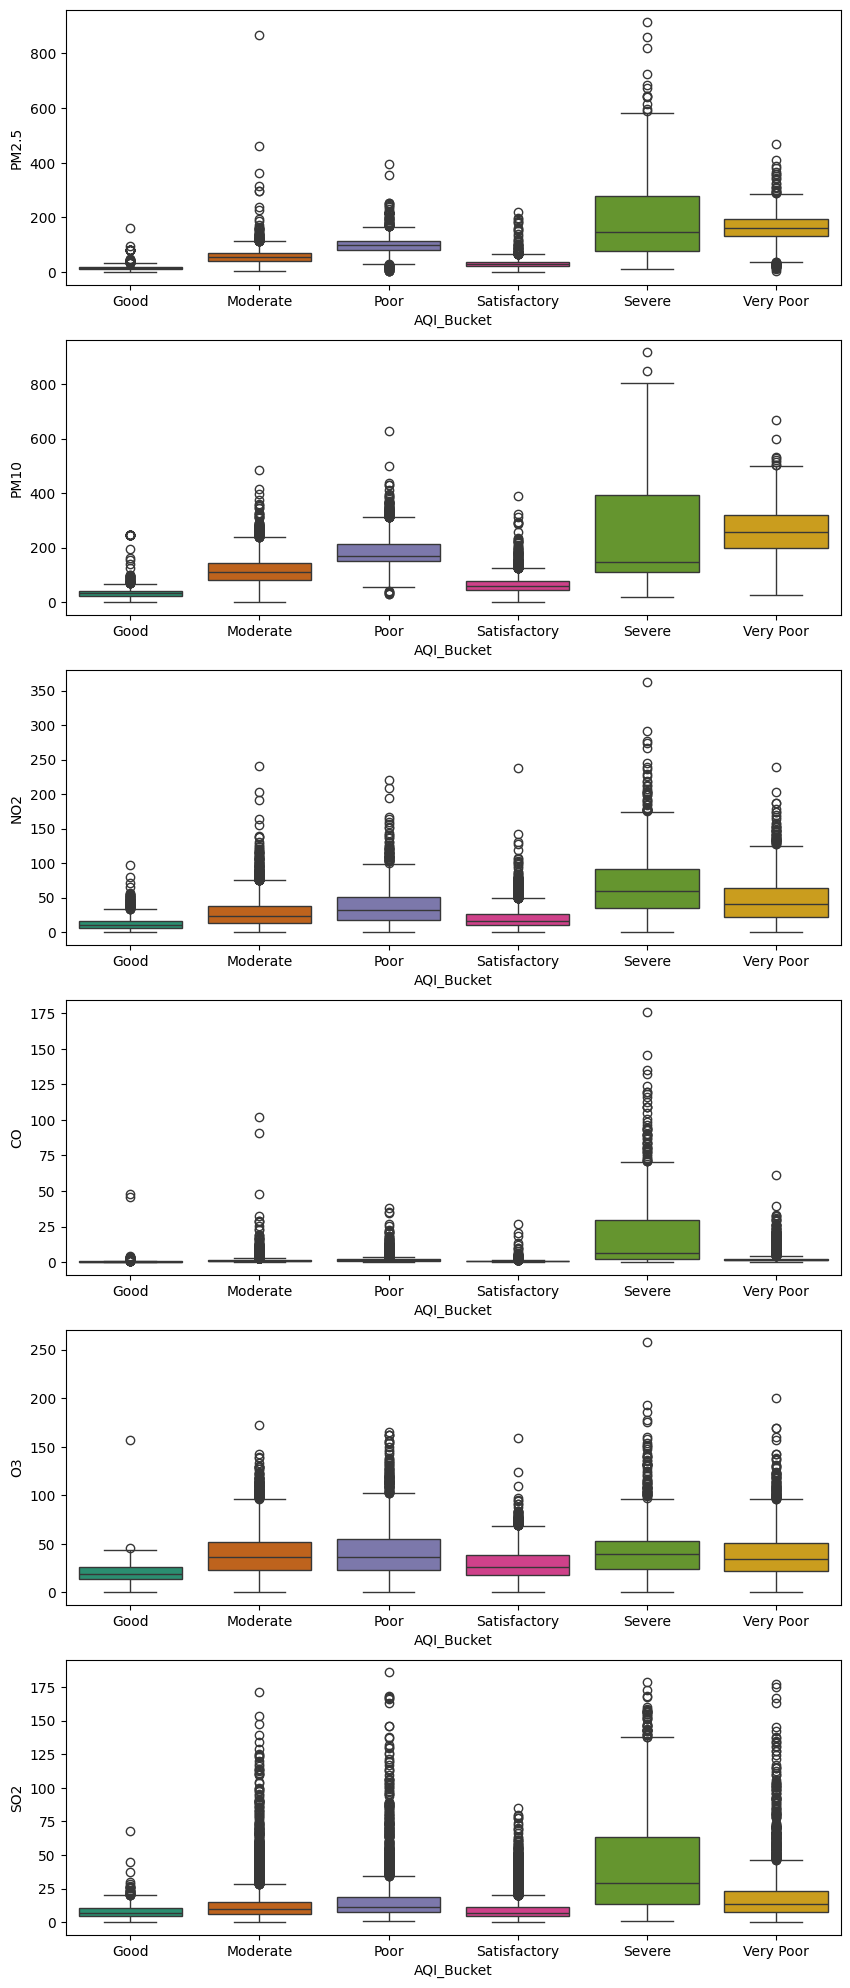

In [71]:
# boxplot before removal of outliers
outlier_detection(df_no_missing, columns)

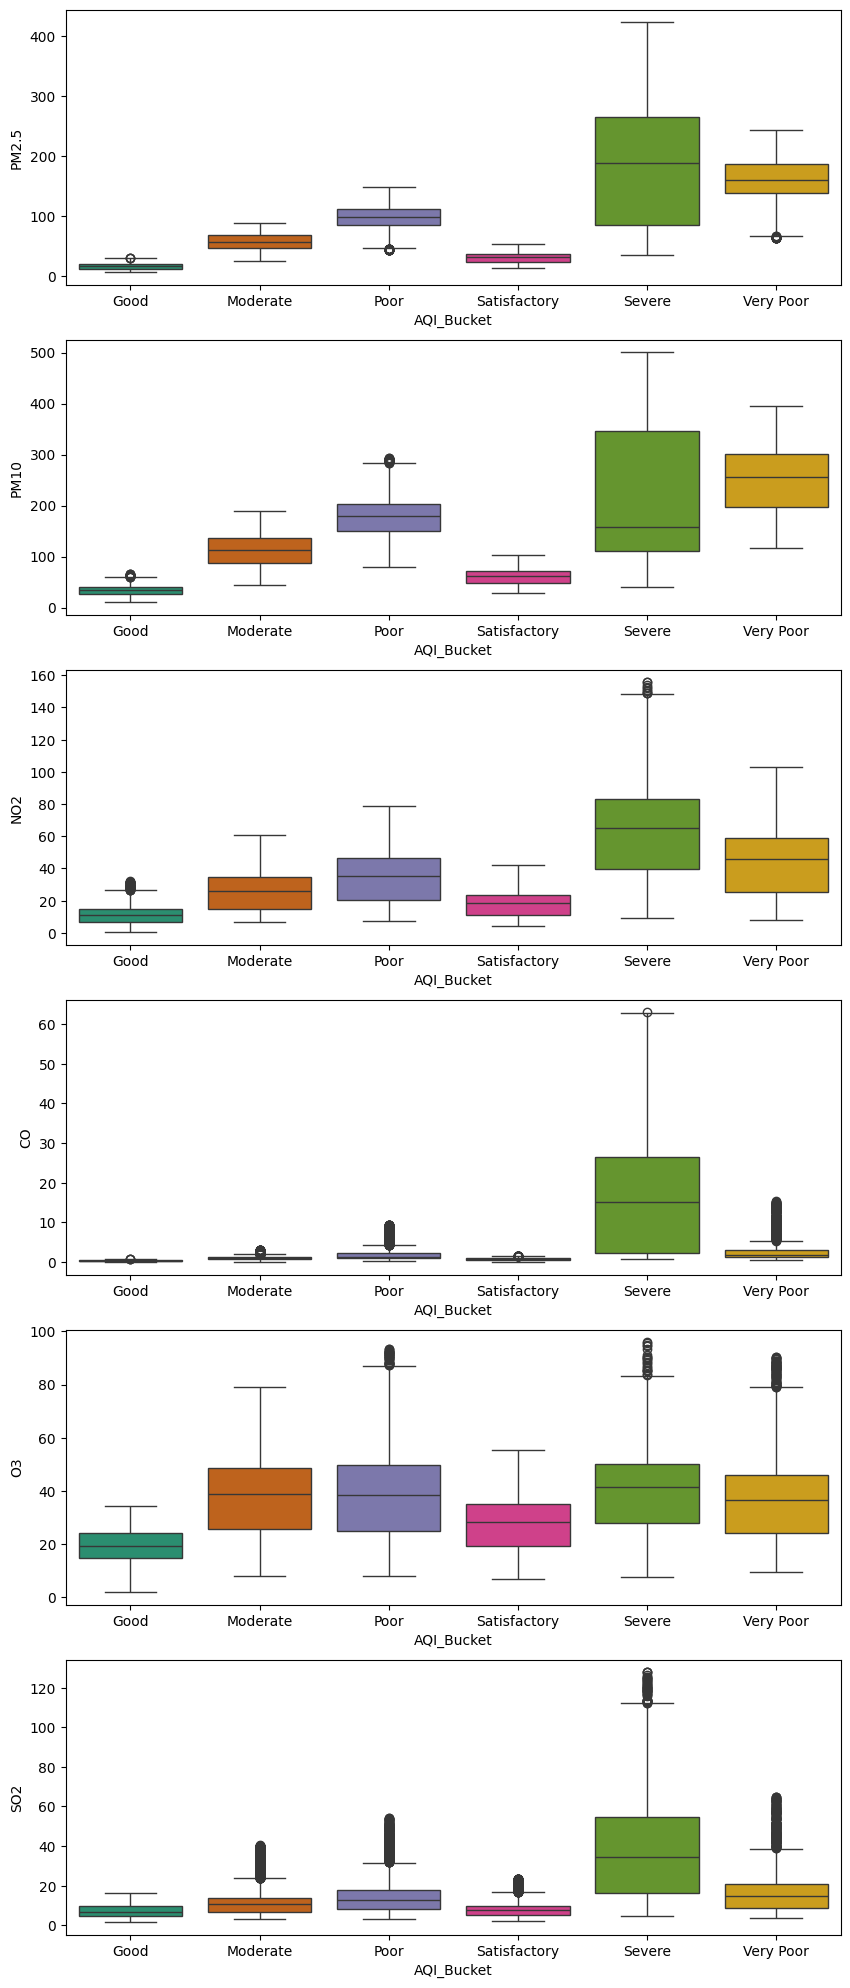

In [72]:
# boxplot after removal of outliers
outlier_detection(df_no_missing02, columns)

In [73]:
df_no_missing.describe()

,Date,PM2.5,PM10,NO,NO2,CO,SO2,O3,AQI
count,24850,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000
mean,2018-07-24 18:51:25.714285824,67.380505,119.850432,18.011497,28.785019,2.328596,14.534486,34.880414,166.463581
min,2015-01-01 00:00:00,0.040000,0.030000,0.030000,0.010000,0.000000,0.010000,0.010000,13.000000
25%,2017-08-16 00:00:00,28.960000,55.190000,5.660000,11.770000,0.580000,5.720000,19.362143,81.000000
50%,2018-11-05 00:00:00,48.715000,98.465000,9.960000,21.910000,0.930000,9.240000,31.090000,118.000000
75%,2019-10-11 00:00:00,80.307500,152.670000,20.138750,38.020000,1.480000,15.310000,45.970000,208.000000
max,2020-07-01 00:00:00,914.940000,917.080000,390.680000,362.210000,175.810000,186.080000,257.730000,2049.000000
std,NaN,62.896522,88.642308,24.264149,24.668995,7.016986,17.714703,21.656538,140.696585


In [74]:
df_no_missing02.describe()

,Date,PM2.5,PM10,NO,NO2,CO,SO2,O3,AQI
count,24850,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000
mean,2018-07-24 18:51:25.714285824,66.404498,117.259680,18.011497,27.403642,1.998140,12.940791,33.844248,166.463581
min,2015-01-01 00:00:00,5.900000,10.720000,0.030000,0.470000,0.000000,1.600000,2.000000,13.000000
25%,2017-08-16 00:00:00,30.618251,60.490000,5.660000,13.392500,0.650000,6.290000,21.480000,81.000000
50%,2018-11-05 00:00:00,49.880000,98.890000,9.960000,22.485000,0.950000,9.440000,31.660000,118.000000
75%,2019-10-11 00:00:00,79.040000,151.240000,20.138750,36.027500,1.410000,14.370000,42.567500,208.000000
max,2020-07-01 00:00:00,423.520000,500.880000,390.680000,155.720000,63.030000,127.840000,95.940000,2049.000000
std,NaN,55.769519,80.036389,24.264149,19.189661,5.068409,12.350394,16.115729,140.696585


In [75]:
df_no_missing02.isna().sum()

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
CO            0
SO2           0
O3            0
AQI           0
AQI_Bucket    0
dtype: int64

Normal Boxplot beore removal of Outliers



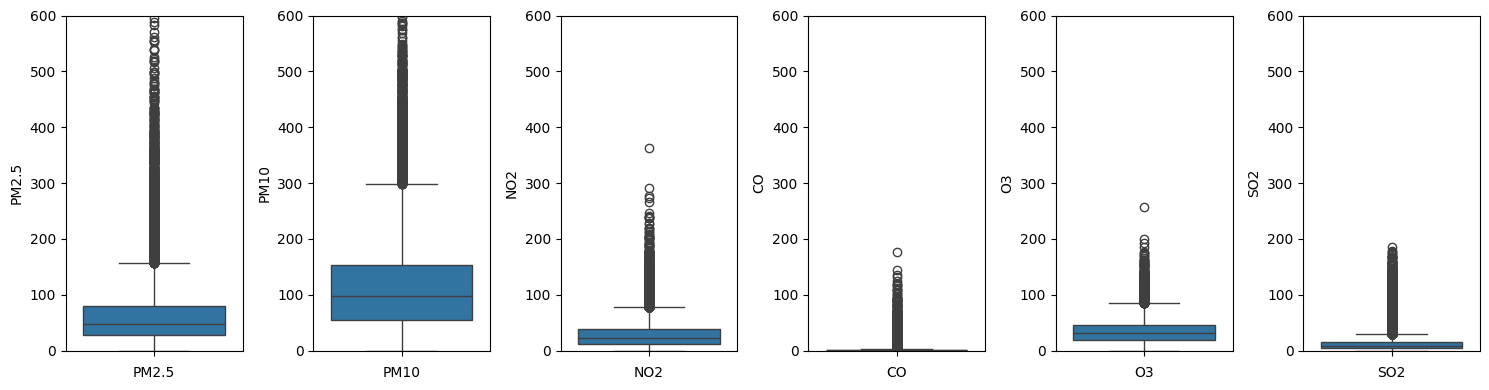




Normal Boxplot after removal of Outliers



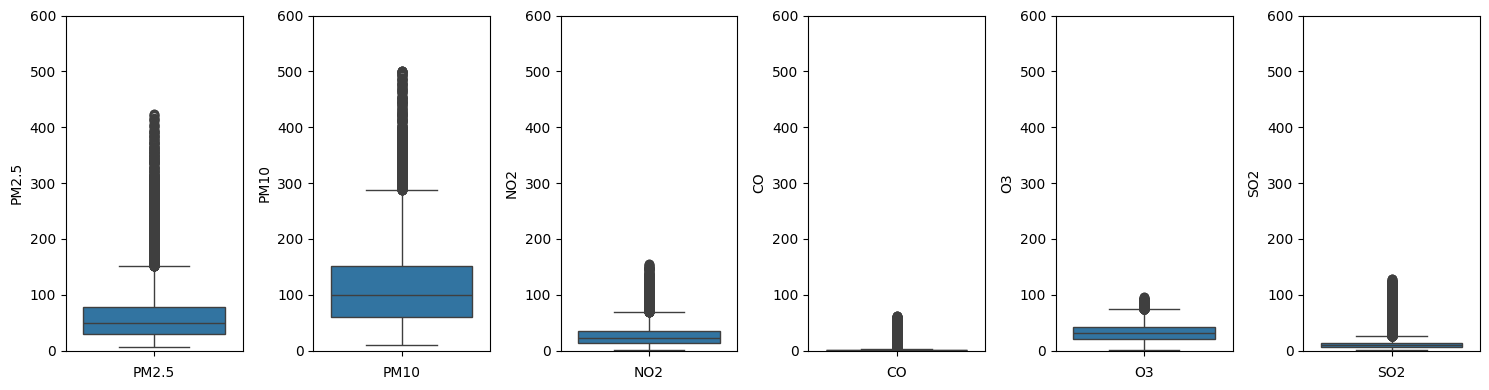

In [76]:
# plotting without AQI_BUCKET for visualizing the whole data
def boxplt(df, columns):
    fig, axes = plt.subplots(
        1, len(columns), figsize=(15, 4)
    )  # Adjust figsize as needed
    for idx, col in enumerate(columns):
        sns.boxplot(y=df[col], ax=axes[idx])
        axes[idx].set_xlabel(col)
        axes[idx].set_ylim(0, 600)  # Set the y-axis range from 0 to 300
    plt.tight_layout()
    plt.show()


columns = ["PM2.5", "PM10", "NO2", "CO", "O3", "SO2"]
print("Normal Boxplot beore removal of Outliers")
print()
boxplt(df_no_missing, columns)
print("\n\n")
print("Normal Boxplot after removal of Outliers")
print()
boxplt(df_no_missing02, columns)

Correlation matrix before removal of outliers



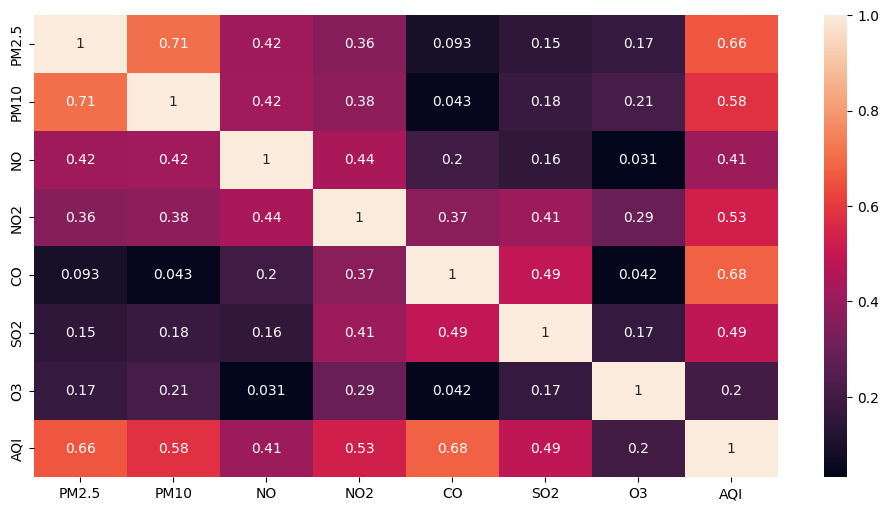

In [77]:
# Create the correlation matrix
print("Correlation matrix before removal of outliers")
print()
plot_corr_matrix(df_no_missing)

Correlation matrix before removal of outliers



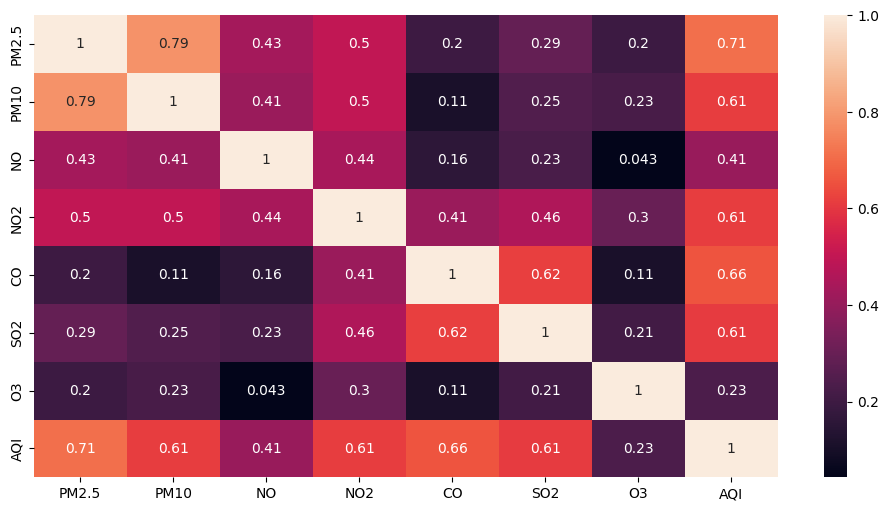

In [78]:
# Create the correlation matrix
print("Correlation matrix before removal of outliers")
print()
plot_corr_matrix(df_no_missing02)

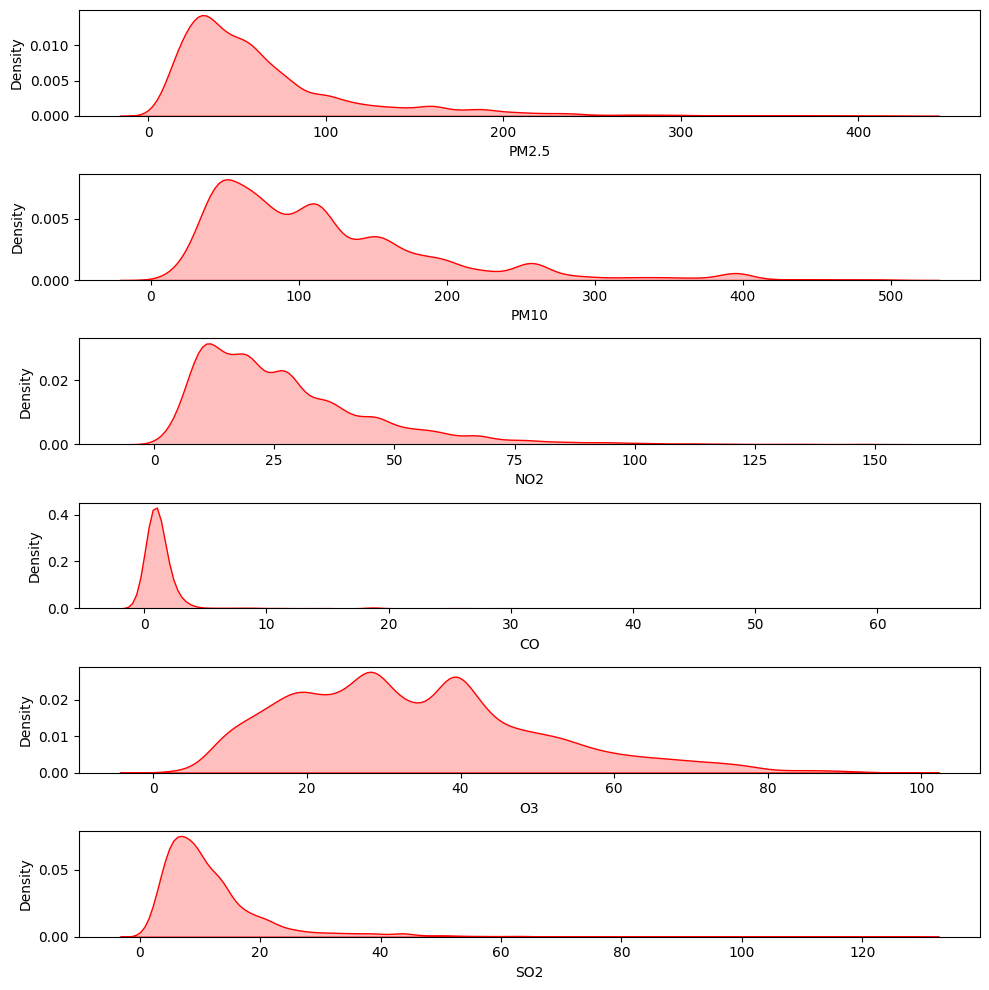

In [79]:
col = ["PM2.5", "PM10", "NO2", "CO", "O3", "SO2"]
column_density(df_no_missing02, col)

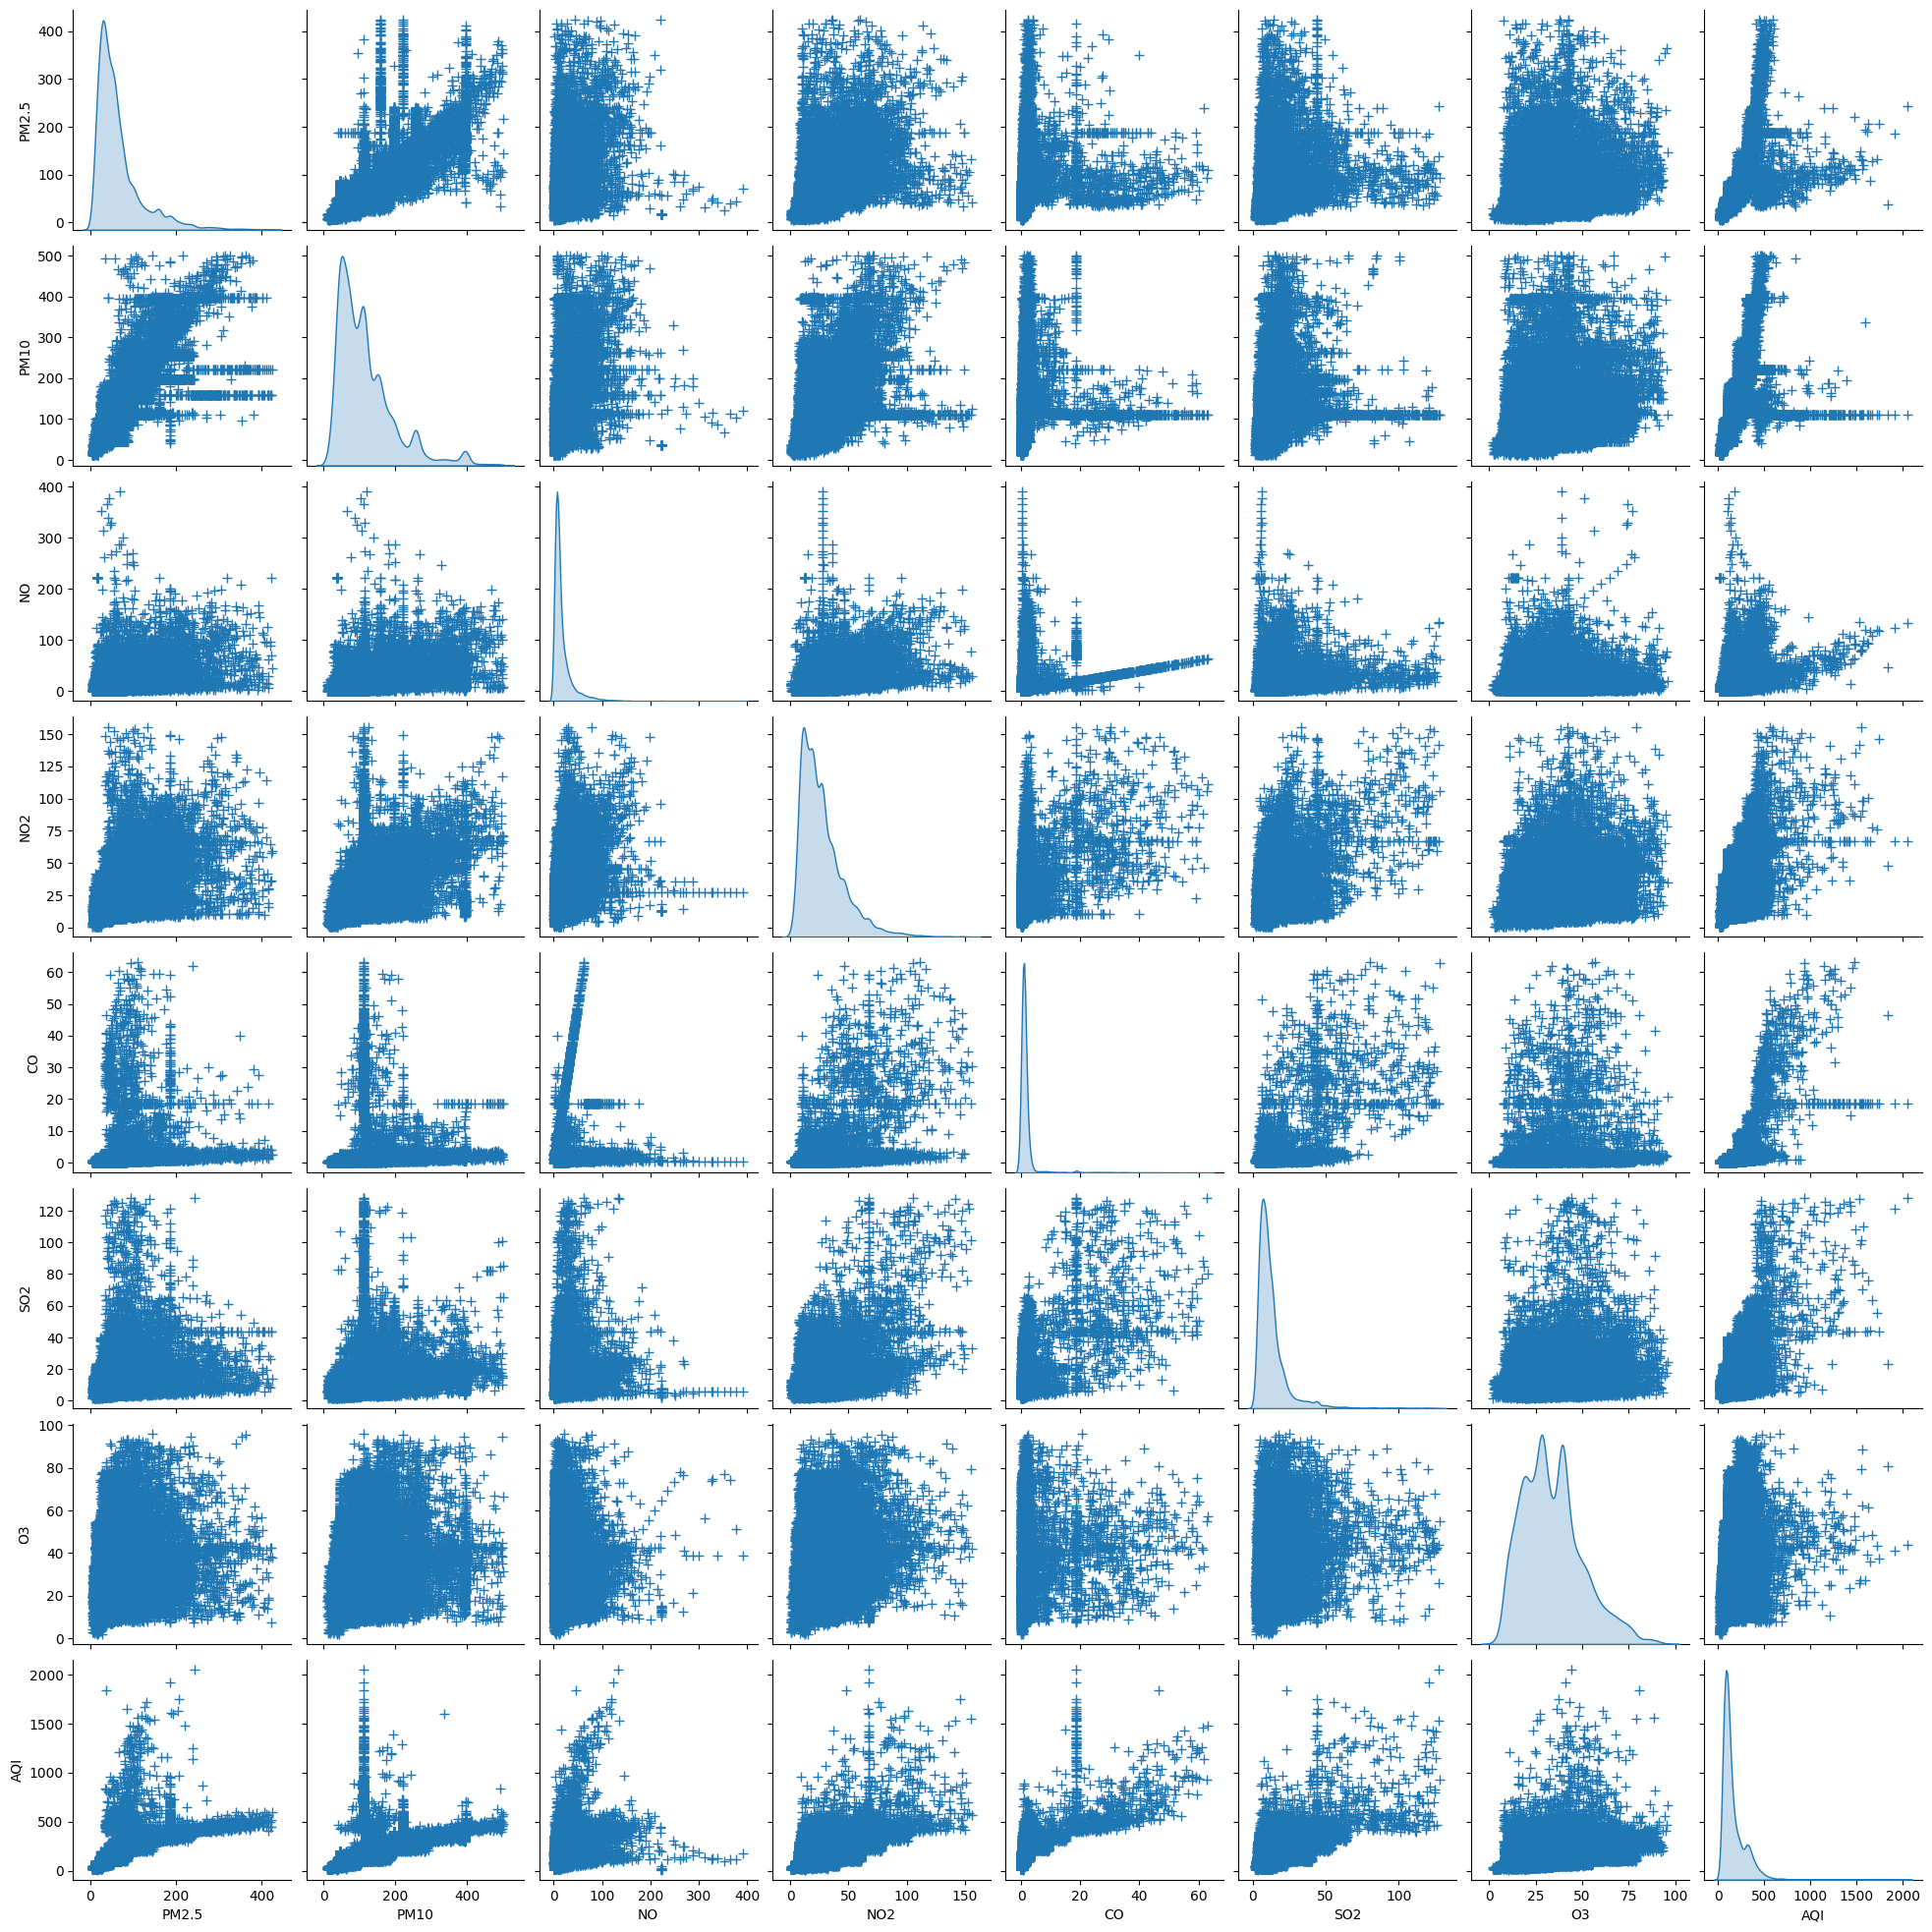

In [80]:
pair_plot(df_no_missing02)

In [81]:
df_no_missing02.to_csv("clean_data.csv", index=False)

# Feature Engineering

1. Feature Encode
2. Train and Test Split
3. Rolling Average (Feature Creation)
4. Feature Scaling

Steps followed:

1. First encode the city
2. Split the encoded dataframe into train and test dataframes
3. Calculate the rolling average based on 7 day window with minimum window size of 1.
4. Drop the city and aqi_rw_avg
5. We can scale or leave the data as it is on demand


In [82]:
df_clean = pd.read_csv("clean_data.csv", parse_dates=["Date"], low_memory=False)
df_clean.drop(["AQI_Bucket"], axis=1, inplace=True)
df_clean.head()

,City,Date,PM2.5,PM10,NO,NO2,CO,SO2,O3,AQI
0,Ahmedabad,2015-07-24,29.22,36.8711,0.06,9.57,0.060000,13.580000,5.08,48.0
1,Ahmedabad,2015-02-05,58.36,152.6700,2.60,21.39,2.600000,32.660000,53.54,149.0
2,Ahmedabad,2015-02-06,79.29,152.6700,1.16,26.94,1.160000,13.505432,59.30,190.0
3,Ahmedabad,2015-03-02,60.78,152.6700,9.07,18.21,1.294969,29.480000,34.75,189.0
4,Ahmedabad,2015-03-08,71.56,152.6700,3.51,16.83,1.294969,30.280000,57.16,190.0


In [83]:
def encode_data(data, encoding_option):
    if encoding_option not in ["onehot", "label"]:
        raise ValueError("Encoding option must be either 'onehot' or 'label'")
    if encoding_option == "onehot":
        encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        encoded_data = encoder.fit_transform(np.array(data).reshape(-1, 1))
        feature_names = encoder.get_feature_names_out(input_features=["City"])
        return pd.DataFrame(encoded_data, columns=feature_names), encoder
    elif encoding_option == "label":
        encoder = LabelEncoder()
        encoded_data = encoder.fit_transform(data)
        return pd.DataFrame(encoded_data), encoder

In [84]:
def train_test_rolling_avg_encode(df, test_size=0.2, encoding_option="onehot"):
    encoded_df, encoder = encode_data(df["City"], encoding_option=encoding_option)
    df_encoded = df.copy()
    if encoding_option == "onehot":
        df_encoded = pd.concat([df_encoded, encoded_df], axis=1)
    elif encoding_option == "label":
        df_encoded["City_Encoded"] = encoded_df

    train_df, test_df = train_test_split(df_encoded, test_size=test_size, shuffle=False)

    train_df = train_df.set_index("Date")
    test_df = test_df.set_index("Date")

    for col in train_df.select_dtypes(exclude=["object"]).columns.tolist():
        if col.startswith("City_"):
            continue
        # Changed rolling mean to expanding mean for faster computation
        train_df[col + "_rw_avg"] = (
            train_df.groupby("City")[col]
            .expanding()
            .mean()
            .reset_index(level=0, drop=True)
        )
        test_df[col + "_rw_avg"] = (
            test_df.groupby("City")[col]
            .expanding()
            .mean()
            .reset_index(level=0, drop=True)
        )

    train_df.drop(["City"], axis=1, inplace=True, errors="ignore")
    test_df.drop(["City"], axis=1, inplace=True, errors="ignore")

    return train_df, test_df, encoder

In [85]:
def df_split_scale(train_df, test_df, scale=False):
    X_train = train_df.drop(["AQI"], axis=1)
    y_train = train_df["AQI"]
    X_test = test_df.drop(["AQI"], axis=1)
    y_test = test_df["AQI"]

    if scale:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        return X_train_scaled, X_test_scaled, y_train, y_test, scaler
    else:
        return X_train, X_test, y_train, y_test, None

Before training model actually lets experiment a bit on scaled and non-scaled data to see how they performs. Meanwhile, doing these we are going to check cross_validation scores and also check the kdeplot of the test and predicted data


In [86]:
def plot_kde_with_axes_and_cv(y_train, y_train_pred, y_test, y_test_pred, cv_scores):
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()

    sns.kdeplot(
        y_train_pred,
        label="Train Predictions",
        color="blue",
        linestyle="--",
        ax=axes[0],
    )
    sns.kdeplot(
        y_train, label="Train Actual", color="orange", linestyle="--", ax=axes[0]
    )
    axes[0].set_xlabel("AQI")
    axes[0].set_ylabel("Density")
    axes[0].set_title("Train Data")
    axes[0].legend()

    sns.kdeplot(
        y_test_pred, label="Test Predictions", color="green", linestyle="--", ax=axes[1]
    )
    sns.kdeplot(y_test, label="Test Actual", color="red", linestyle="--", ax=axes[1])
    axes[1].set_xlabel("AQI")
    axes[1].set_ylabel("Density")
    axes[1].set_title("Test Data")
    axes[1].legend()

    sns.kdeplot(
        y_train_pred - y_train,
        label="Difference (Train)",
        color="green",
        linestyle="--",
        ax=axes[2],
    )
    sns.kdeplot(
        y_test_pred - y_test,
        label="Difference (Test)",
        color="red",
        linestyle="--",
        ax=axes[2],
    )
    axes[2].set_xlabel("Difference")
    axes[2].set_ylabel("Density")
    axes[2].set_title("Difference between Train and Test Predictions")
    axes[2].legend()

    axes[3].text(
        0.5,
        0.95,
        f"Cross-Validation Scores: {cv_scores}",
        horizontalalignment="center",
        verticalalignment="center",
        transform=axes[3].transAxes,
    )
    axes[3].axis("off")
    fig.delaxes(axes[3])

    plt.tight_layout()
    plt.show()

In [87]:
df_mod = pd.read_csv("clean_data.csv", parse_dates=["Date"], low_memory=False)
df_mod.drop(["AQI_Bucket"], axis=1, inplace=True)
train_df, test_df, encoder_mod = train_test_rolling_avg_encode(
    df_mod, test_size=0.2, encoding_option="label"
)
print(train_df.columns)

Index(['PM2.5', 'PM10', 'NO', 'NO2', 'CO', 'SO2', 'O3', 'AQI', 'City_Encoded',
       'PM2.5_rw_avg', 'PM10_rw_avg', 'NO_rw_avg', 'NO2_rw_avg', 'CO_rw_avg',
       'SO2_rw_avg', 'O3_rw_avg', 'AQI_rw_avg'],
      dtype='object')


In [88]:
X_train_mod, X_test_mod, y_train_mod, y_test_mod, scaler_mod = df_split_scale(
    train_df, test_df, scale=True
)

print(X_train_mod)

print(X_test_mod)

print(y_train_mod)

print(y_test_mod)

[[-0.70507834 -1.00198364 -0.74114864 ...  0.33428675 -3.45330702
  -1.32160807]
 [-0.16363973  0.39051012 -0.63337794 ...  1.8319493  -0.48358246
  -0.60858692]
 [ 0.22525218  0.39051012 -0.69447629 ...  1.32882634  0.74164851
  -0.17795039]
 ...
 [-0.679098   -0.94908641  0.44942062 ...  0.69127246  0.97604868
  -0.07907938]
 [-0.999395   -0.77544392 -0.18574766 ...  0.6923847   0.9783994
  -0.08122095]
 [-0.83811541 -0.53951139 -0.12167925 ...  0.6936281   0.97605865
  -0.08367737]]
[[-0.90351912 -0.59158008 -0.19805219 ...  1.22440694  0.18071415
  -0.98274654]
 [-0.88791142 -0.76233655  0.85971302 ...  1.26679362 -0.02029073
  -0.92626962]
 [-0.93975128 -0.64304753  0.4795455  ...  1.11556215 -0.20740503
  -0.91685679]
 ...
 [ 0.95305418  0.21049432  0.7315762  ...  0.05123302 -0.21561305
  -0.34838363]
 [ 0.7858288   0.89772899  0.27673292 ...  0.05213778 -0.21441532
  -0.34608991]
 [ 2.04447847  2.47963135  0.86268308 ...  0.05276349 -0.21310031
  -0.34357101]]
Date
2015-07-24  

In [89]:
encoder_mod

LabelEncoder()

In [90]:
scaler_mod

StandardScaler()

In [91]:
def preprocess_plot_score(
    df,
    test_size=0.2,
    model=LinearRegression(),
    encoding_option="onehot",
    scale=False,
    sample_frac=None,
):

    if sample_frac:

        df = df.sample(frac=sample_frac, random_state=42)


    train_df, test_df, _ = train_test_rolling_avg_encode(
        df, test_size=test_size, encoding_option=encoding_option
    )

    X_train, X_test, y_train, y_test, _ = df_split_scale(train_df, test_df, scale)


    model.fit(X_train, y_train)


    y_train_pred = model.predict(X_train)

    y_test_pred = model.predict(X_test)


    # Skip cross-validation for RandomForestRegressor to save time

    if isinstance(model, RandomForestRegressor):

        cv_scores = None

    else:

        cv_scores = (
            -1
            * cross_val_score(
                model, X_train, y_train, cv=5, scoring="neg_mean_squared_error"
            ).mean()
        )


    plot_kde_with_axes_and_cv(y_train, y_train_pred, y_test, y_test_pred, cv_scores)


    train_score = mean_squared_error(y_train, y_train_pred)

    test_score = mean_squared_error(y_test, y_test_pred)


    return model, train_score, test_score, cv_scores

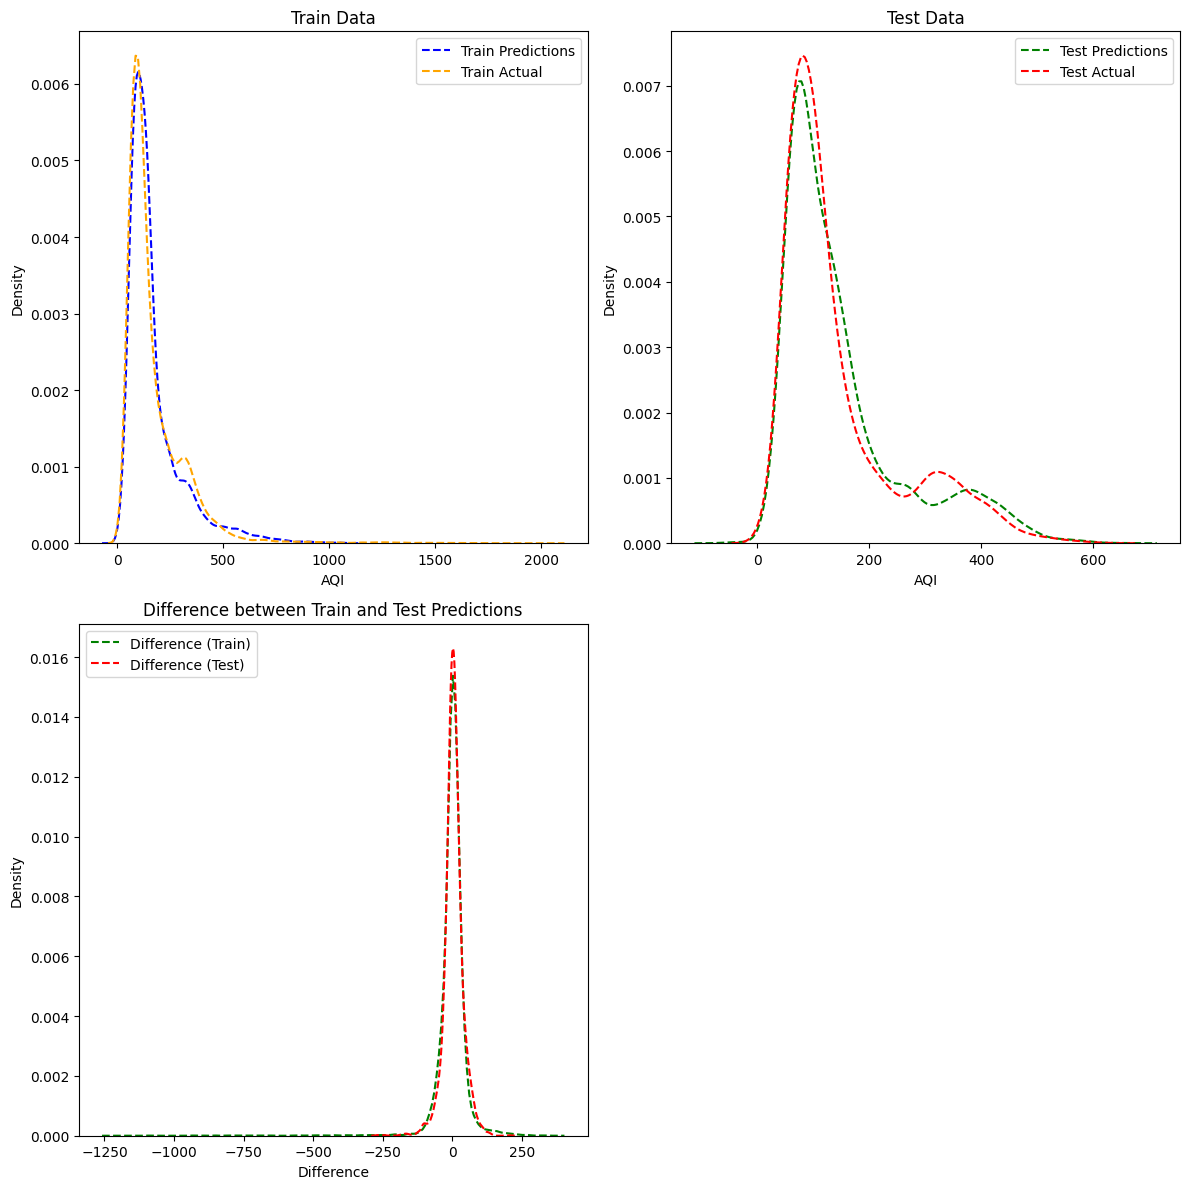

Training Score: 3818.225090345044
Testing Score: 1235.4607470037615
Cross_Validation Score: 5870.506025238296


In [92]:
df_clean = pd.read_csv("clean_data.csv", parse_dates=["Date"], low_memory=False)
df_clean.drop(["AQI_Bucket"], axis=1, inplace=True)
model, train_score, test_score, cv_scores = preprocess_plot_score(df_clean)
print("Training Score:", train_score)
print("Testing Score:", test_score)
print("Cross_Validation Score:", cv_scores)

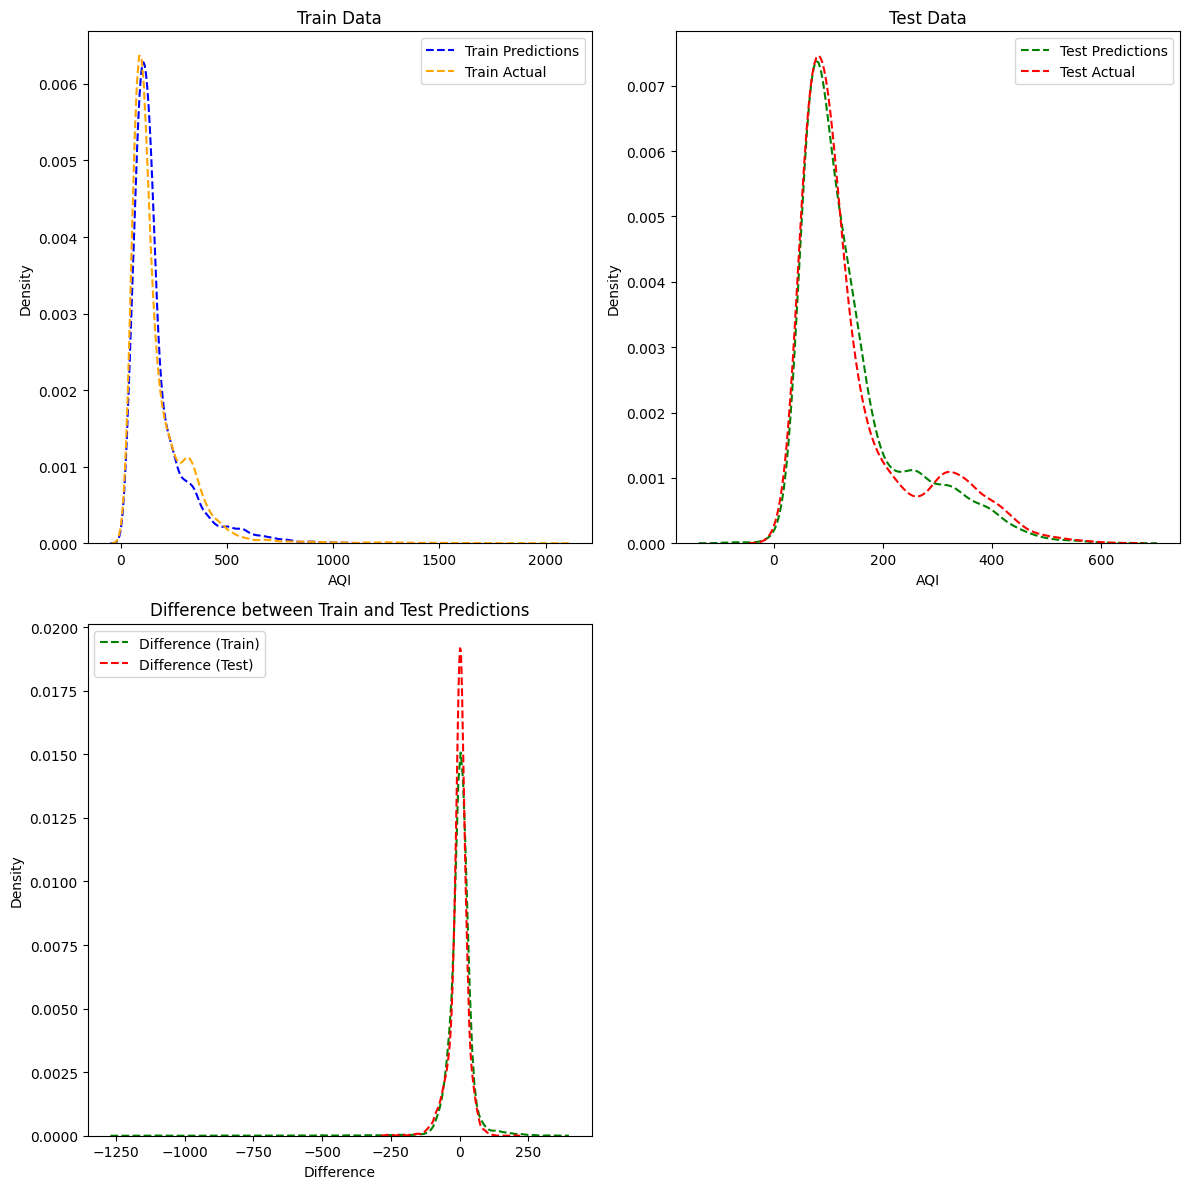

Training Score: 3872.3353965731776
Testing Score: 1145.330974258851
Cross_Validation Score: 4918.5006247016645


In [93]:
df_clean = pd.read_csv("clean_data.csv", parse_dates=["Date"], low_memory=False)
df_clean.drop(["AQI_Bucket"], axis=1, inplace=True)
model, train_score, test_score, cv_scores = preprocess_plot_score(
    df_clean, encoding_option="label", scale=True
)
print("Training Score:", train_score)
print("Testing Score:", test_score)
print("Cross_Validation Score:", cv_scores)

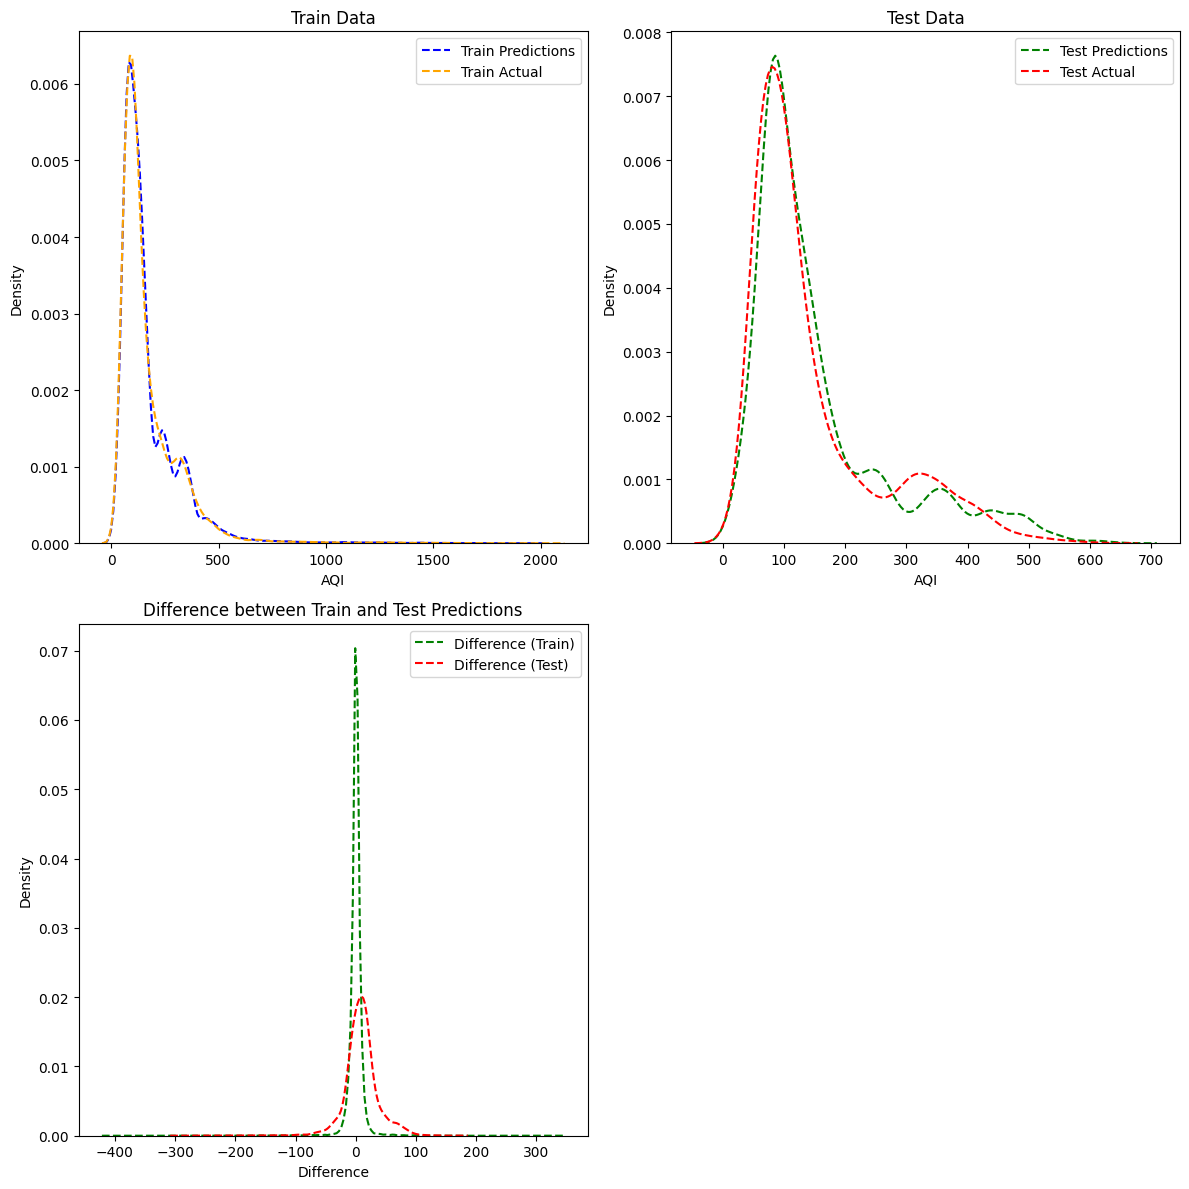

Training Score: 187.72847097585515
Testing Score: 933.5120687726356
Cross_Validation Score: None


In [94]:
df_clean = pd.read_csv("clean_data.csv", parse_dates=["Date"], low_memory=False)
df_clean.drop(["AQI_Bucket"], axis=1, inplace=True)
model, train_score, test_score, cv_scores = preprocess_plot_score(
    df_clean, model=RandomForestRegressor()
)
print("Training Score:", train_score)
print("Testing Score:", test_score)
print("Cross_Validation Score:", cv_scores)

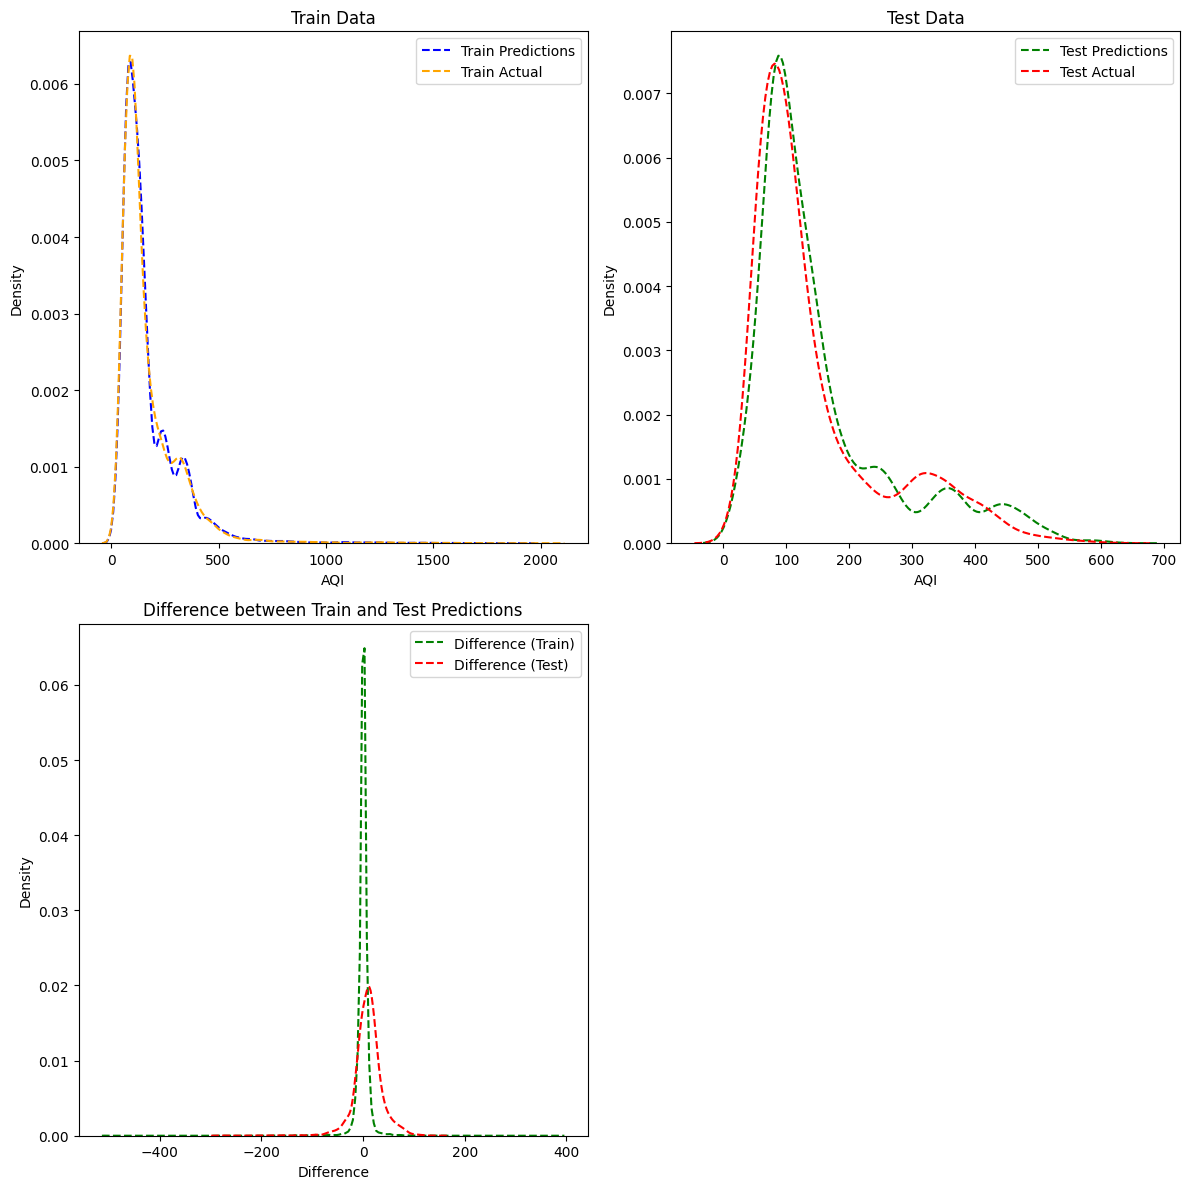

Training Score: 188.53498628772633
Testing Score: 904.2386149899397
Cross_Validation Score: None


In [95]:
df_clean = pd.read_csv("clean_data.csv", parse_dates=["Date"], low_memory=False)
df_clean.drop(["AQI_Bucket"], axis=1, inplace=True)
model, train_score, test_score, cv_scores = preprocess_plot_score(
    df_clean, model=RandomForestRegressor(), encoding_option="label"
)
print("Training Score:", train_score)
print("Testing Score:", test_score)
print("Cross_Validation Score:", cv_scores)

# Modelling and Hypertuning

Following models are selection for training

1. SGDRegressor
2. XGBoostRegressor
3. RandomForestRegressor
4. LBGMRegressor
5. SGDRegressor

In this part, we are going train models, hypertune them and also see best performing model evaluation of neg_mean_squared_error, r2_score. Also, plot the best performing model on the basis of hypertuned parameters.

1. Model Selection
2. Model Training
3. Model Evaluation
4. Model Hypertuning


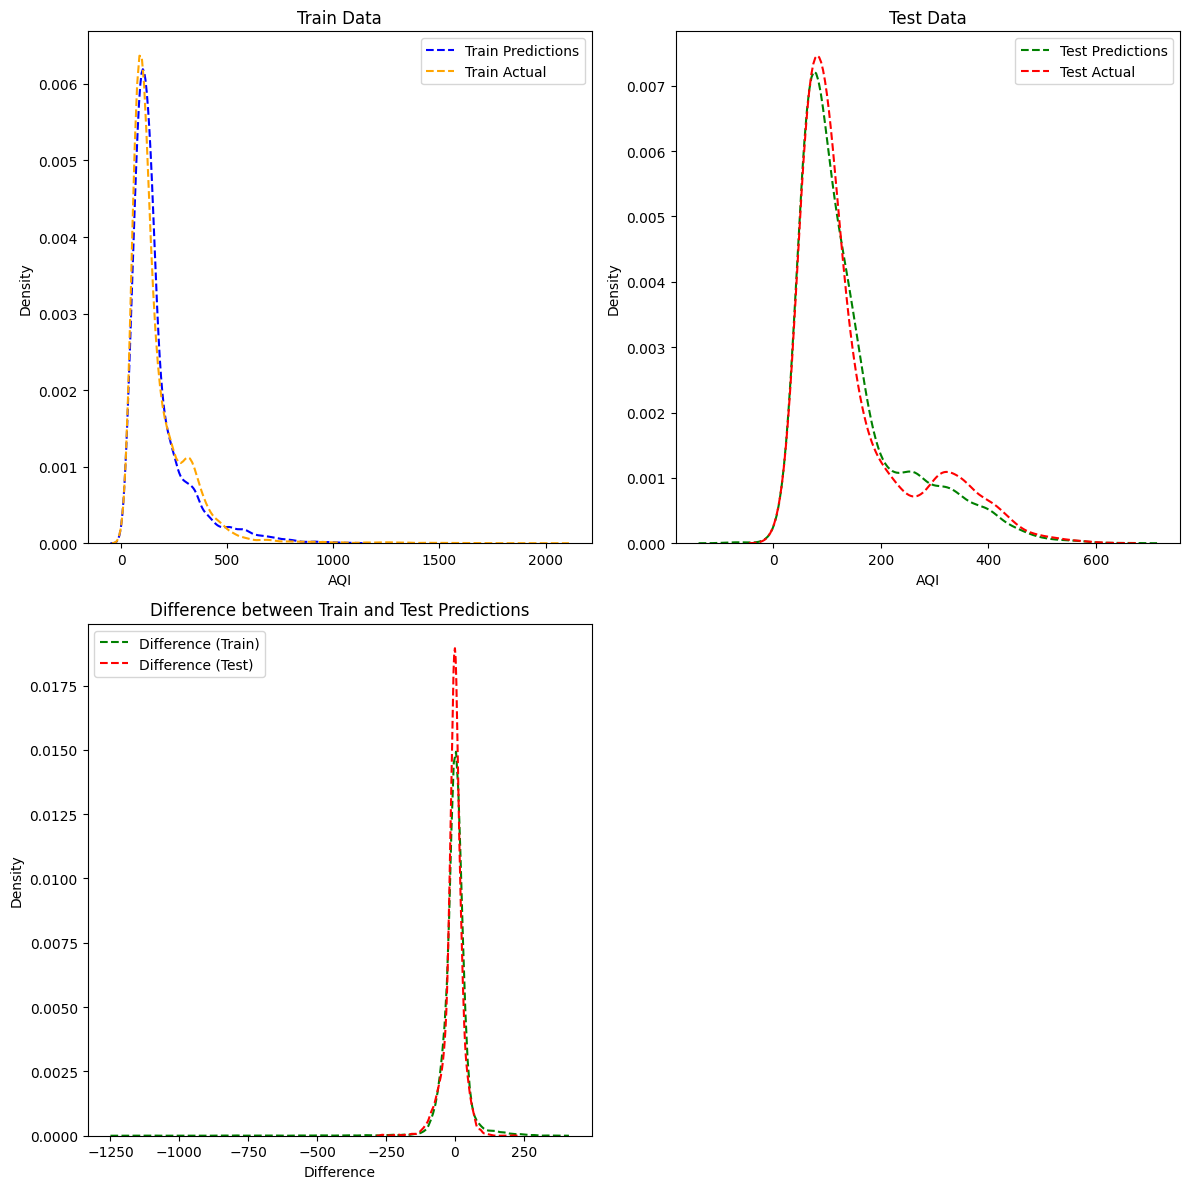

Training Error: 3884.5970384227785
Testing Error: 1164.9571756430723
Cross_Validation Score: 4892.015931848759


In [96]:
df_clean = pd.read_csv("clean_data.csv", parse_dates=["Date"], low_memory=False)
df_clean.drop(["AQI_Bucket"], axis=1, inplace=True)
model, train_score, test_score, cv_scores = preprocess_plot_score(
    df_clean, model=SGDRegressor(), encoding_option="label", scale=True
)
print("Training Error:", train_score)
print("Testing Error:", test_score)
print("Cross_Validation Score:", cv_scores)

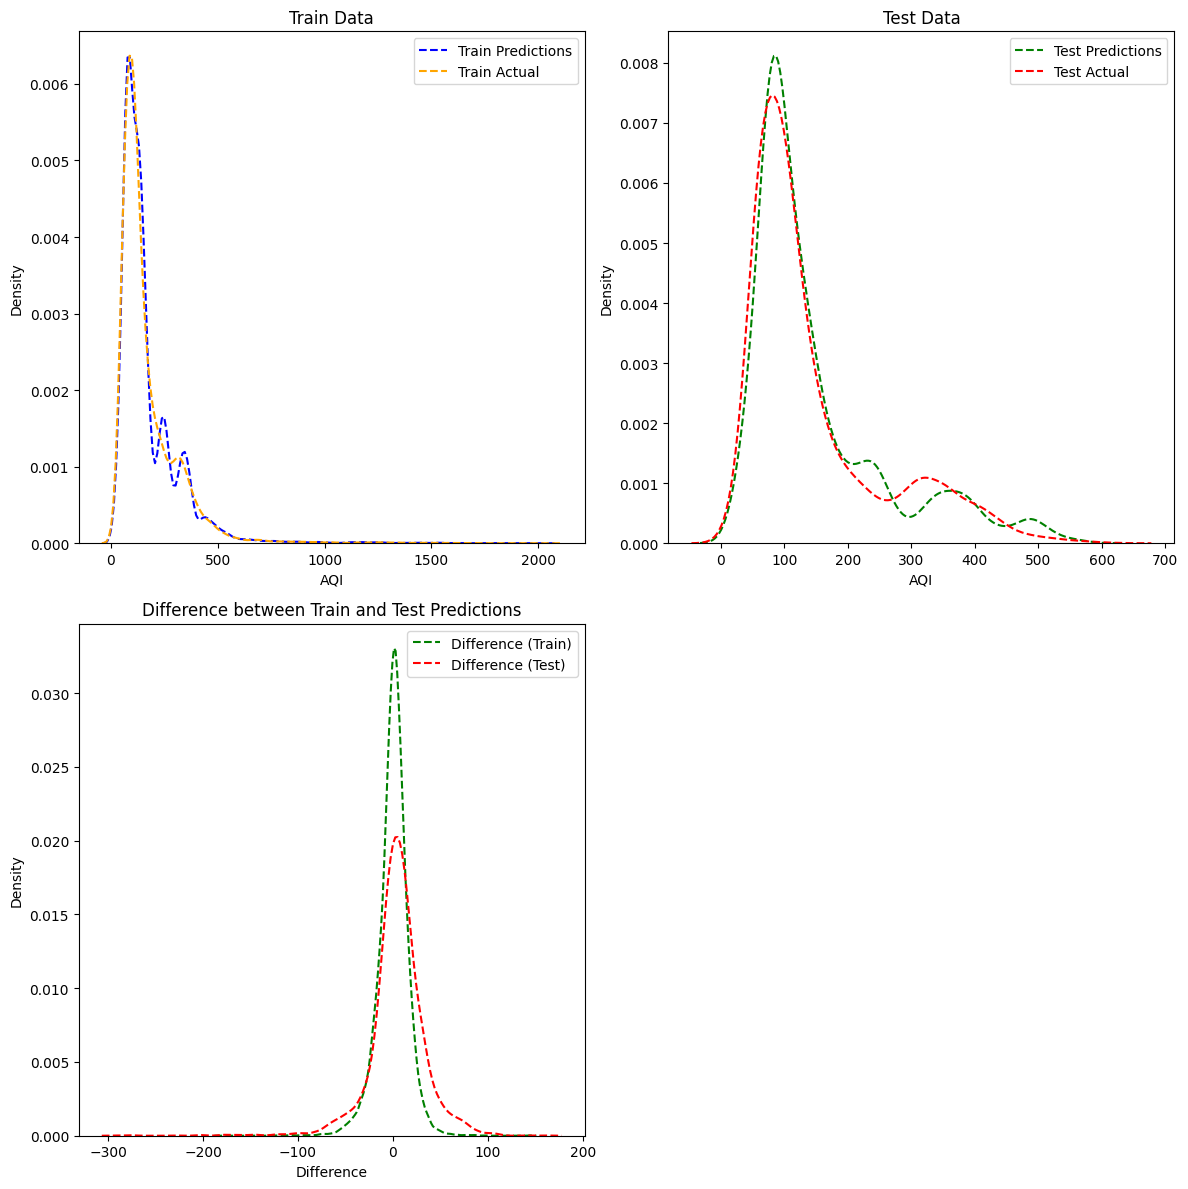

Training Error: 273.35170101949205
Testing Error: 908.0891030621559
Cross_Validation Score: 8573.98746553728


In [97]:
df_clean = pd.read_csv("clean_data.csv", parse_dates=["Date"], low_memory=False)
df_clean.drop(["AQI_Bucket"], axis=1, inplace=True)
model, train_score, test_score, cv_scores = preprocess_plot_score(
    df_clean, model=XGBRegressor(), encoding_option="label", scale=True
)
print("Training Error:", train_score)
print("Testing Error:", test_score)
print("Cross_Validation Score:", cv_scores)

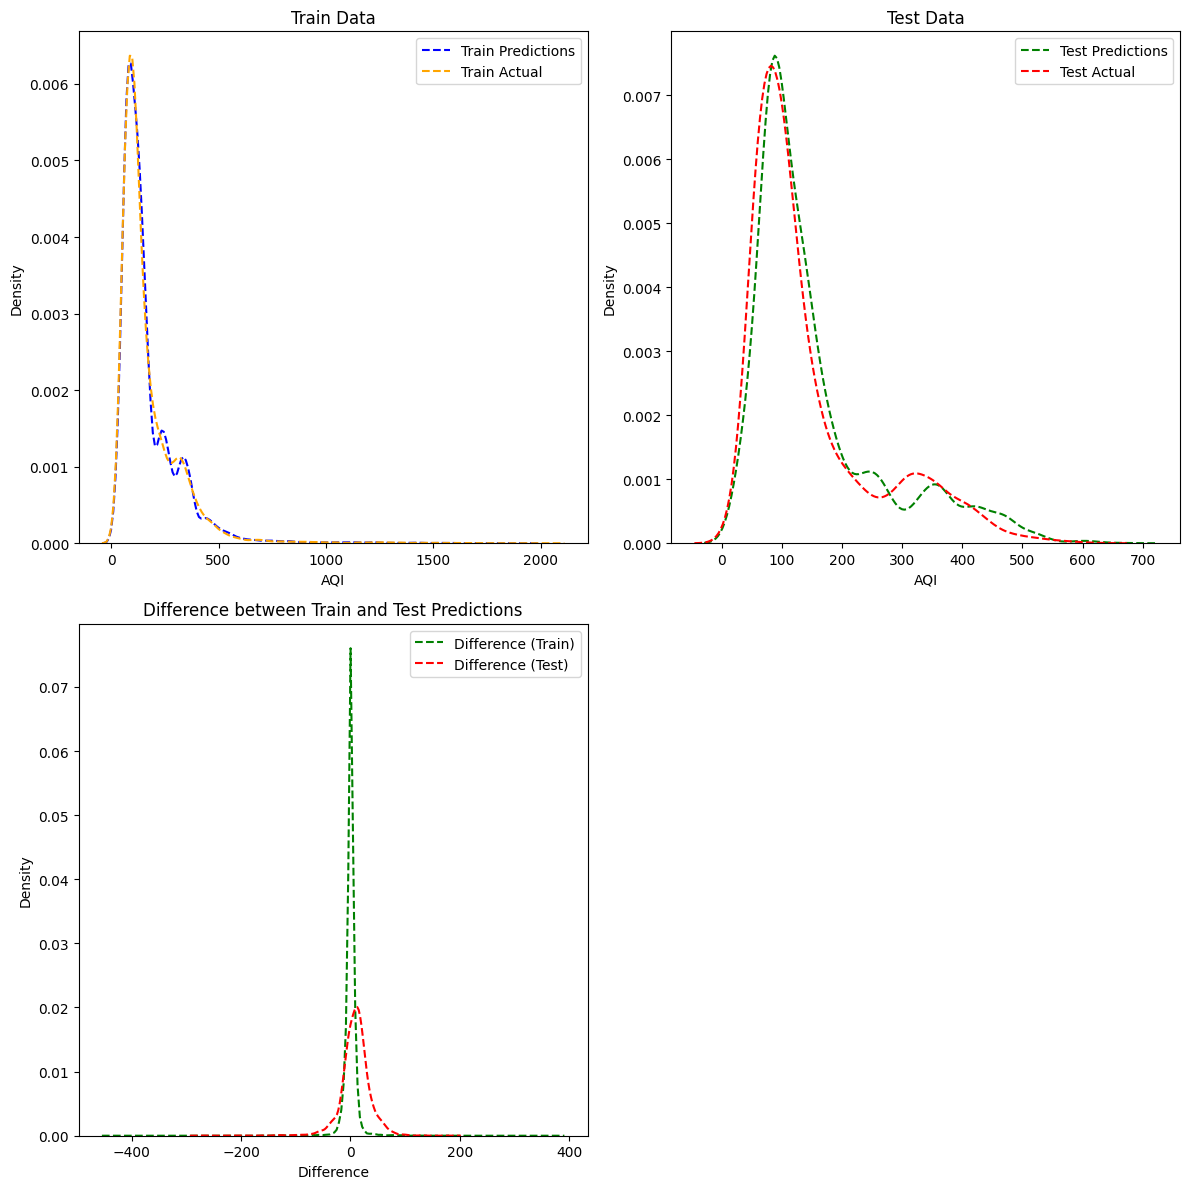

Training Error: 183.5170738229376
Testing Error: 837.4990003822937
Cross_Validation Score: None


In [98]:
df_clean = pd.read_csv("clean_data.csv", parse_dates=["Date"], low_memory=False)
df_clean.drop(["AQI_Bucket"], axis=1, inplace=True)
model, train_score, test_score, cv_scores = preprocess_plot_score(
    df_clean, model=RandomForestRegressor(), encoding_option="label", scale=True
)
print("Training Error:", train_score)
print("Testing Error:", test_score)
print("Cross_Validation Score:", cv_scores)

[LightGBM] [Info] Total Bins 3847
[LightGBM] [Info] Number of data points in the train set: 19880, number of used features: 16
[LightGBM] [Info] Start training from score 171.415241
[LightGBM] [Info] Total Bins 3843
[LightGBM] [Info] Number of data points in the train set: 15904, number of used features: 16
[LightGBM] [Info] Start training from score 158.532508
[LightGBM] [Info] Total Bins 3844
[LightGBM] [Info] Number of data points in the train set: 15904, number of used features: 16
[LightGBM] [Info] Start training from score 185.504464
[LightGBM] [Info] Total Bins 3844
[LightGBM] [Info] Number of data points in the train set: 15904, number of used features: 16
[LightGBM] [Info] Start training from score 166.358652
[LightGBM] [Info] Total Bins 3845
[LightGBM] [Info] Number of data points in the train set: 15904, number of used features: 16
[LightGBM] [Info] Start training from score 177.309985
[LightGBM] [Info] Total Bins 3842
[LightGBM] [Info] Number of data points in the train set

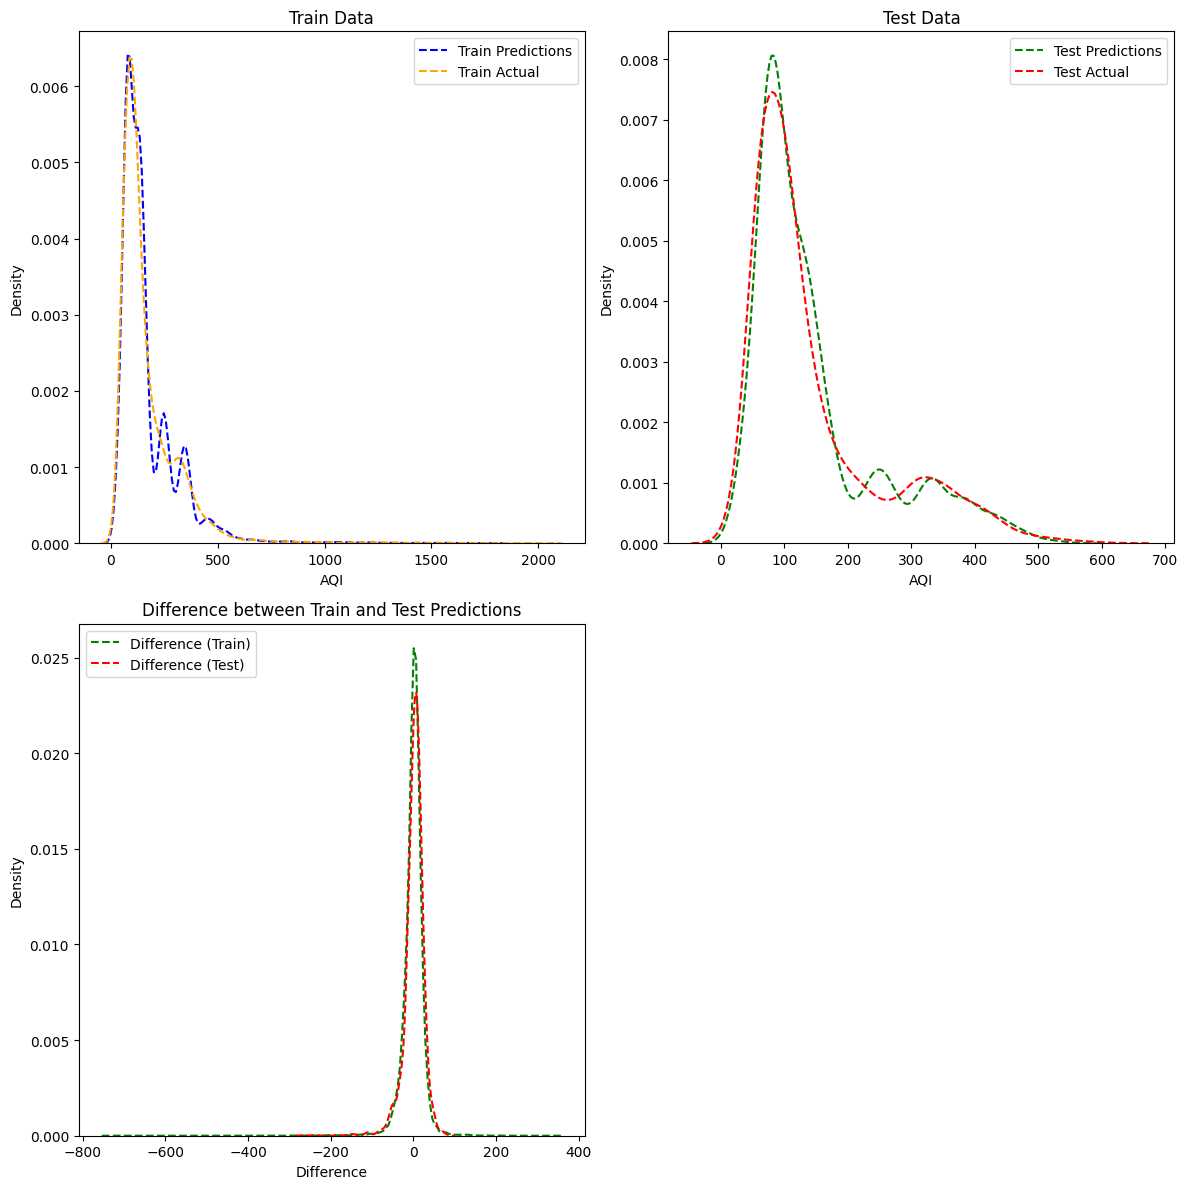

Training Error: 667.4798851436276
Testing Error: 623.6133873798278
Cross_Validation Score: 8883.269482553489


In [99]:
df_clean = pd.read_csv("clean_data.csv", parse_dates=["Date"], low_memory=False)
df_clean.drop(["AQI_Bucket"], axis=1, inplace=True)
model, train_score, test_score, cv_scores = preprocess_plot_score(
    df_clean,
    model=LGBMRegressor(force_row_wise=True),
    encoding_option="label",
    scale=True,
)
print("Training Error:", train_score)
print("Testing Error:", test_score)
print("Cross_Validation Score:", cv_scores)

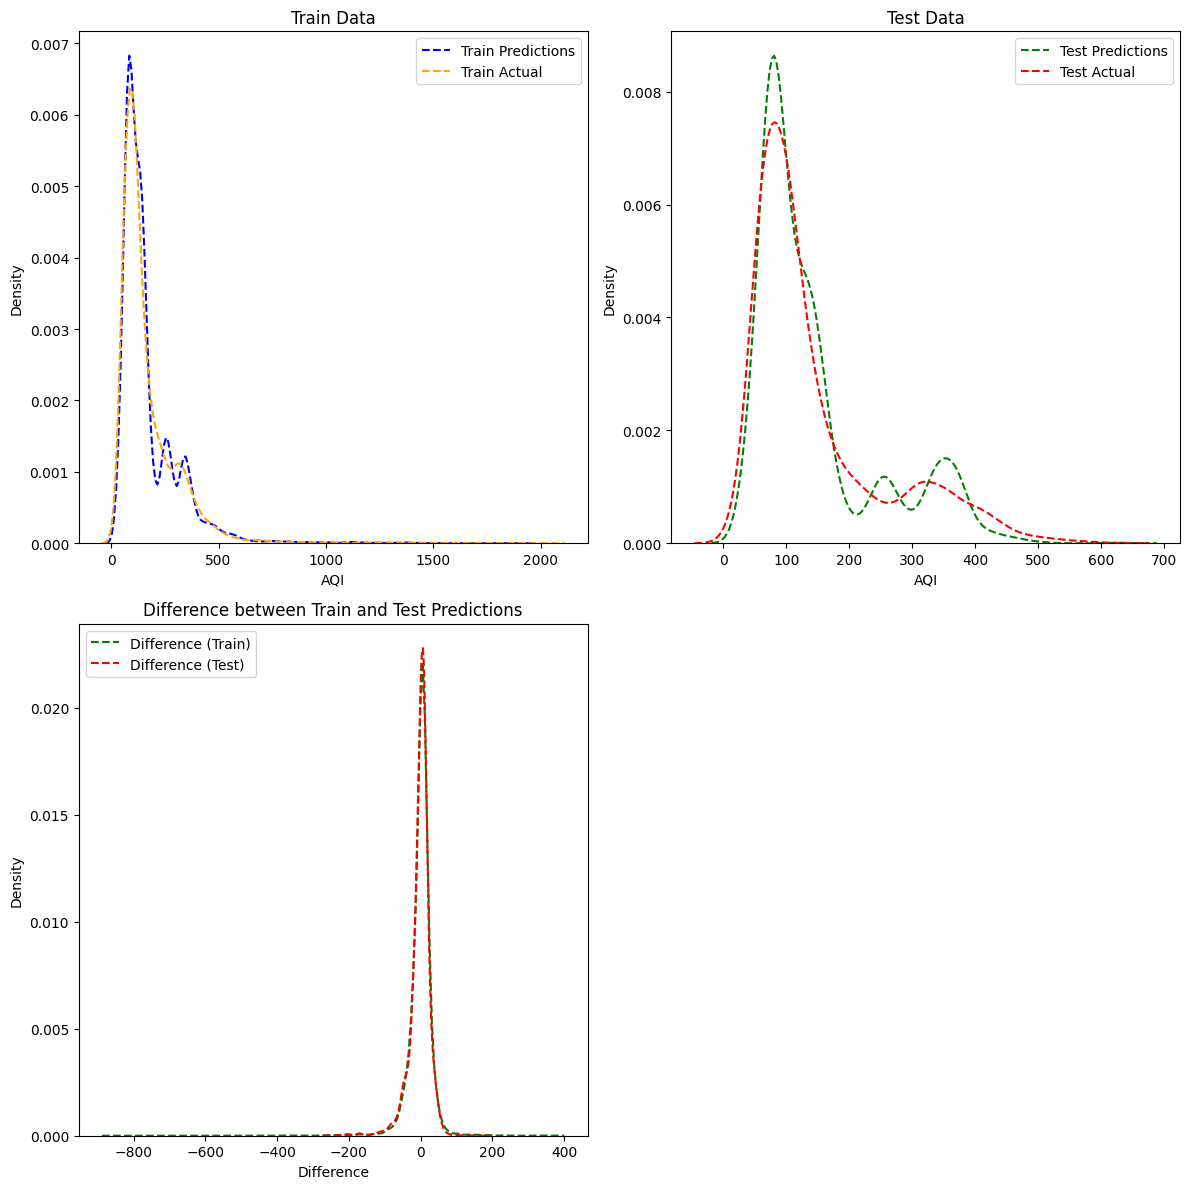

Training Error: 1251.1987460344085
Testing Error: 851.4735721526127
Cross_Validation Score: 7910.138002021429


In [100]:
df_clean = pd.read_csv("clean_data.csv", parse_dates=["Date"], low_memory=False)
df_clean.drop(["AQI_Bucket"], axis=1, inplace=True)
model, train_score, test_score, cv_scores = preprocess_plot_score(
    df_clean, model=GradientBoostingRegressor(), encoding_option="label", scale=True
)
print("Training Error:", train_score)
print("Testing Error:", test_score)
print("Cross_Validation Score:", cv_scores)

In [101]:
def df_preprocess(df, test_size=0.2, encoding_option="label", scale=True):
    """
    @params:
    df: input dataframe
    test_size: (by Default = 0.2)
    encoding_option: (by Default = 'label')
    scale: (by Default = 'True')

    1. This function first split the data into train and test sets, encodes
    it, calculate rolling average.
    2. Above ouput is used to split train and test set into X and y (scaling optional)
    """

    # Perform train-test split, rolling averages calculation, and encoding
    train_df, test_df, encoder = train_test_rolling_avg_encode(
        df, test_size=test_size, encoding_option=encoding_option
    )
    X_train, X_test, y_train, y_test, scaler = df_split_scale(train_df, test_df, scale)
    # Splitting the data and scaling
    return X_train, X_test, y_train, y_test, scaler, encoder

In [102]:
df_clean = pd.read_csv("clean_data.csv", parse_dates=["Date"], low_memory=False)
df_clean.drop(["AQI_Bucket"], axis=1, inplace=True)
X_train, X_test, y_train, y_test, scaler, encoder = df_preprocess(df_clean)

In [103]:
with open("encoder.pkl", "wb") as file:
    pickle.dump(encoder, file)

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [104]:
def hyper_tune_regression_model(
    X_train,
    y_train,
    model_params,
    scoring="neg_mean_squared_error",
    cv=5,
    n_iter=50,
    random_state=None,
):
    """



    Hyper-tunes a regression model using RandomizedSearchCV.

    Parameters:

    X_train: array-like, shape (n_samples, n_features)

        Training data.

    y_train: array-like, shape (n_samples,)

        Target values.

    model: Estimator object.

        The regression model to be hyper-tuned.


    param_grid: dict

        Dictionary with parameters names (string) as keys and distributions or lists of parameters to try.

    scoring: str or callable, default='neg_mean_squared_error'

        A scoring strategy to evaluate the performance of the cross-validated model.

    cv: int, default=5

        Number of cross-validation folds.

    n_iter: int, default=10

        Number of parameter settings that are sampled.

    random_state: int or None, default=None

        Controls the random seed for reproducibility.

    Returns:

    best_model: Estimator object

        The best hyper-tuned model.

    best_params: dict

        The best hyperparameters found during hyperparameter tuning.

    best_score: float

        The scoring of the best hyper-tuned model.

    """

    model = model_params["model"]

    param_grid = model_params["param_grid"]

    # Instantiate RandomizedSearchCV

    random_search = RandomizedSearchCV(
        model,
        param_distributions=param_grid,
        n_iter=n_iter,
        cv=cv,
        scoring=scoring,
        random_state=random_state,
        n_jobs=-1,
    )

    # Fit RandomizedSearchCV to the training data

    random_search.fit(X_train, y_train)

    # Get the best model, best parameters, and best score

    best_model = random_search.best_estimator_

    best_params = random_search.best_params_

    best_score = random_search.best_score_

    # Print the scoring of the best model

    print(f"Best Score: {best_score:.4f}")

    return (best_model, best_params, best_score)

In [105]:
model_params = {
    "SGDRegressor": {
        "model": SGDRegressor(),
        "param_grid": {
            "alpha": [0.0001, 0.001, 0.01],
            "l1_ratio": [0, 0.25, 0.5, 0.75, 1],
            "learning_rate": ["constant", "optimal", "invscaling", "adaptive"],
            "penalty": ["l1", "l2", "elasticnet"],
        },
    },
    "XGBRegressor": {
        "model": XGBRegressor(),
        "param_grid": {
            "n_estimators": [100, 200, 300],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [3, 5, 7],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0],
            "reg_alpha": [0.1, 1.0],
            "reg_lambda": [0.1, 1.0],
        },
    },
    "RandomForestRegressor": {
        "model": RandomForestRegressor(),
        "param_grid": {
            "n_estimators": [100, 200, 300],
            "max_depth": [10, 20, 30],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "min_weight_fraction_leaf": [0.0, 0.1, 0.2],
            "max_features": ["auto", "sqrt", "log2", None],
            "max_leaf_nodes": [None, 10, 20, 30],
            "min_impurity_decrease": [0.0, 0.1, 0.2],
            "bootstrap": [True, False],
            "oob_score": [True, False],
        },
    },
    "LGBMRegressor": {
        "model": LGBMRegressor(force_row_wise=True),
        "param_grid": {
            "boosting_type": ["gbdt"],
            "objective": ["regression"],
            "metric": ["mse"],
            "learning_rate": [0.05, 0.1, 0.2],
            "max_depth": [-1, 3, 5, 7],
            "lambda_l2": [0.1],
            "num_leaves": [31, 50, 100],
            "min_child_samples": [20, 50, 100],
            "subsample": [0.6, 0.7, 0.8, 1.0],
            "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
            "reg_alpha": [0, 0.1, 0.5],
            "reg_lambda": [0, 0.1, 0.5],
            "n_estimators": [50, 100, 200],
        },
    },
    "GradientBoostingRegressor": {
        "model": GradientBoostingRegressor(),
        "param_grid": {
            "n_estimators": [100],
            "learning_rate": [0.01],
            "max_depth": [5, 7],
            "min_samples_split": [5, 10],
            "min_samples_leaf": [2, 4],
        },
    },
}

In [106]:
best_models = []
best_models.append(
    hyper_tune_regression_model(X_train, y_train, model_params["SGDRegressor"])
)
best_models.append(
    hyper_tune_regression_model(X_train, y_train, model_params["XGBRegressor"])
)
best_models.append(
    hyper_tune_regression_model(X_train, y_train, model_params["RandomForestRegressor"])
)
best_models.append(
    hyper_tune_regression_model(X_train, y_train, model_params["LGBMRegressor"])
)

Best Score: -4747.3402
Best Score: -5406.6018
Best Score: -8648.9895
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.5 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.5 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Info] Total Bins 3847
[LightGBM] [Info] Number of data points in the train set: 19880, number of used features: 16
[LightGBM] [Info] Start training from score 171.415241
Best Score: -7504.6297


In [107]:
best_models

[(SGDRegressor(l1_ratio=0.25, learning_rate='optimal'),
  {'penalty': 'l2',
   'learning_rate': 'optimal',
   'l1_ratio': 0.25,
   'alpha': 0.0001},
  np.float64(-4747.340201758413)),
 (XGBRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.1, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=300,
               n_jobs=None, num_parallel_tree=None, ...),
  {'subsample': 0.8,
   'reg_lambda': 0.1,
   're

In [108]:
# Initialize lists to store results for each model
results = []

# Train and evaluate each model
for best_model, _, _ in best_models:
    # Train the model with best parameters
    best_model.fit(X_train, y_train)

    # Make predictions on test data
    y_pred = best_model.predict(X_test)

    # Calculate residuals
    residuals = y_test - y_pred

    # Calculate R^2 score
    r2 = r2_score(y_test, y_pred)

    # Calculate mean squared error
    mse = mean_squared_error(y_test, y_pred)

    # Store results for the current model
    results.append(
        {
            "model": best_model,
            "y_true": y_test,
            "y_pred": y_pred,
            "residuals": residuals,
            "r2_score": r2,
            "mse": mse,
        }
    )

# Print test scores for each model
for i, result in enumerate(results):
    print(f"Model {i+1}:")
    print(f"  R^2 Score: {result['r2_score']:.4f}")
    print(f"  Mean Squared Error: {result['mse']:.4f}")

[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.5 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.5 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Info] Total Bins 3847
[LightGBM] [Info] Number of data points in the train set: 19880, number of used features: 16
[LightGBM] [Info] Start training from score 171.415241
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.5 will be ignored. Current value: lambda_l2=0.1
Model 1:
  R^2 Score: 0.8581
  Mean Squared Error: 1645.0574
Model 2:
  R^2 Score: 0.9317
  Mean Squared Error: 791.6119
Model 3:
  R^2 Score: 0.9174
  Mean Squared Error: 957.6390
Model 4:
  R^2 Score: 0.9443
  Mean Squared Error: 645.1639


In [109]:
def plot_regression_diagnostic_plots(y_true, y_pred, residuals):
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))

    # Scatter Plot of Actual vs. Predicted Values
    sns.scatterplot(x=y_pred, y=y_true, ax=axes[0, 0])
    axes[0, 0].plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        color="red",
        linestyle="--",
    )
    axes[0, 0].set_title("Actual vs. Predicted")
    axes[0, 0].set_xlabel("Predicted")
    axes[0, 0].set_ylabel("Actual")

    # Residual Plot
    sns.scatterplot(x=y_pred, y=residuals, ax=axes[0, 1])
    axes[0, 1].axhline(y=0, color="r", linestyle="--")
    axes[0, 1].set_title("Residual Plot")
    axes[0, 1].set_xlabel("Predicted")
    axes[0, 1].set_ylabel("Residuals")

    # KDE Plot of y_true and y_pred
    sns.kdeplot(y_true, label="True", ax=axes[1, 0])
    sns.kdeplot(y_pred, label="Predicted", ax=axes[1, 0])
    axes[1, 0].set_title("KDE Plot of True vs. Predicted")
    axes[1, 0].set_xlabel("Value")
    axes[1, 0].set_ylabel("Density")
    axes[1, 0].legend()

    # Histogram of Residuals
    sns.histplot(residuals, ax=axes[1, 1], kde=True)
    axes[1, 1].set_title("Histogram of Residuals")
    axes[1, 1].set_xlabel("Residuals")

    # Q-Q Plot
    import scipy.stats as stats

    stats.probplot(residuals, dist="norm", plot=axes[2, 0])
    axes[2, 0].set_title("Q-Q Plot")

    # Fitted vs. Residual Plot
    fig.delaxes(axes[2, 1])

    # Show plots
    plt.tight_layout()
    plt.show()

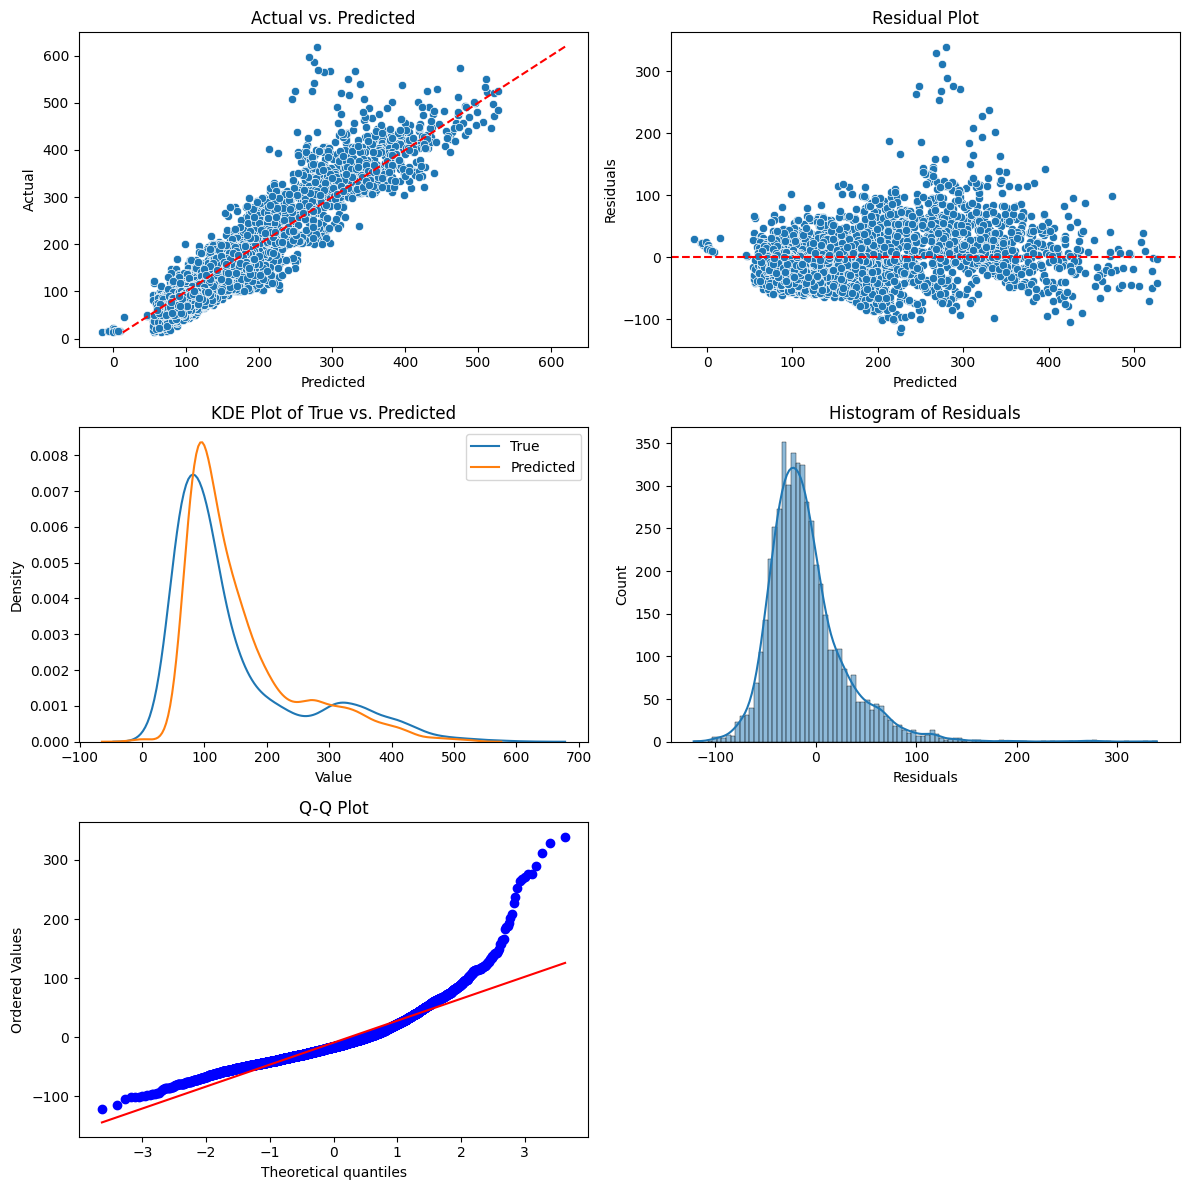

In [110]:
plot_regression_diagnostic_plots(
    results[0]["y_true"], results[0]["y_pred"], results[0]["residuals"]
)

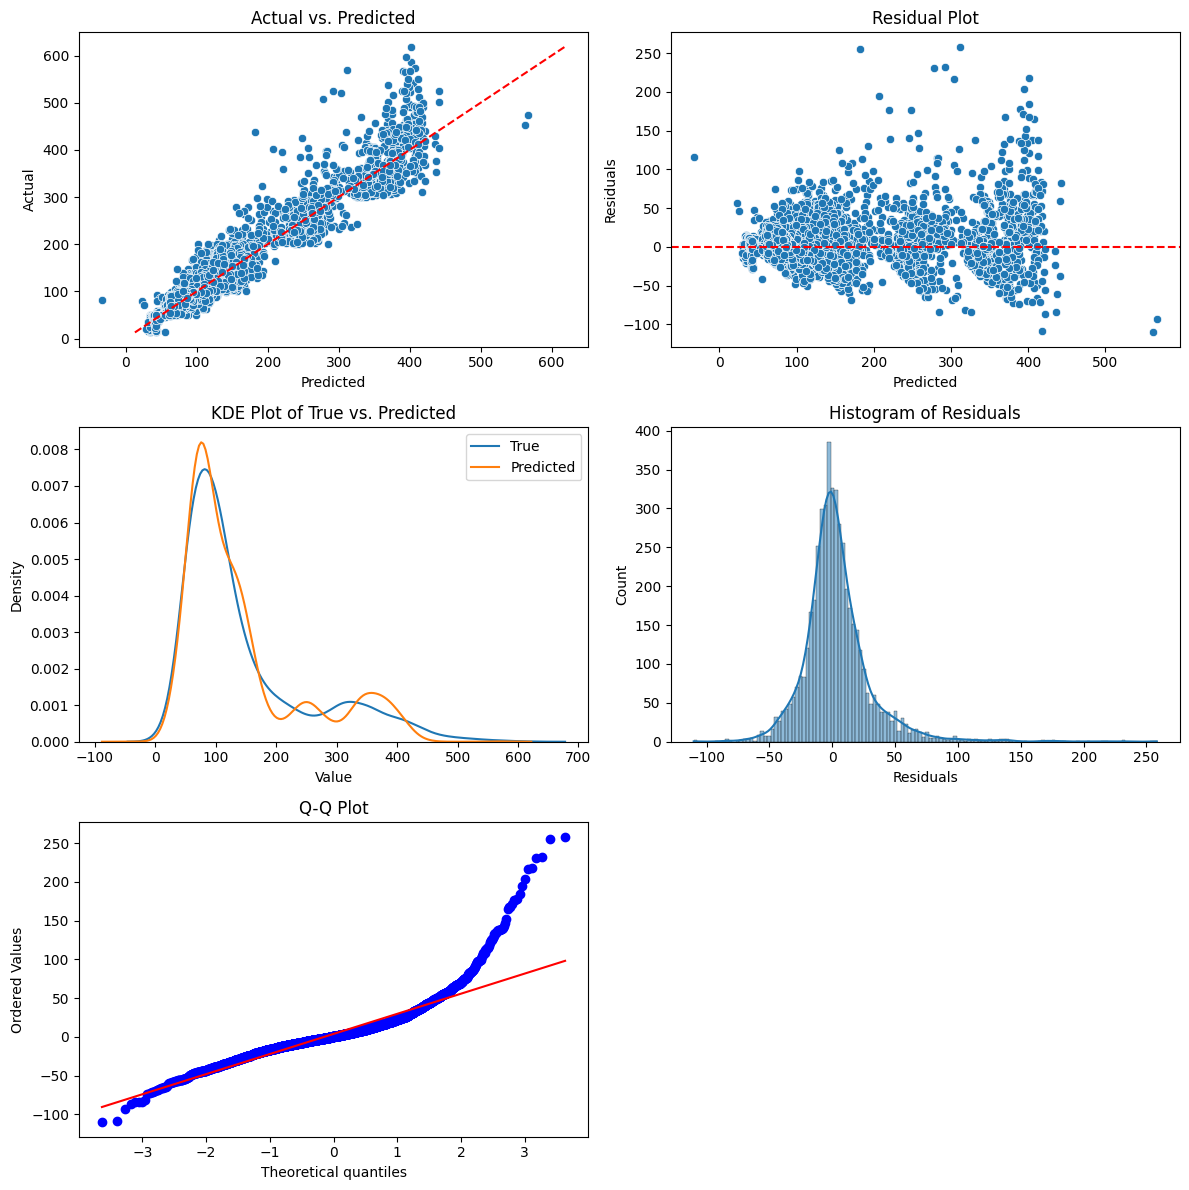

In [111]:
plot_regression_diagnostic_plots(
    results[1]["y_true"], results[1]["y_pred"], results[1]["residuals"]
)

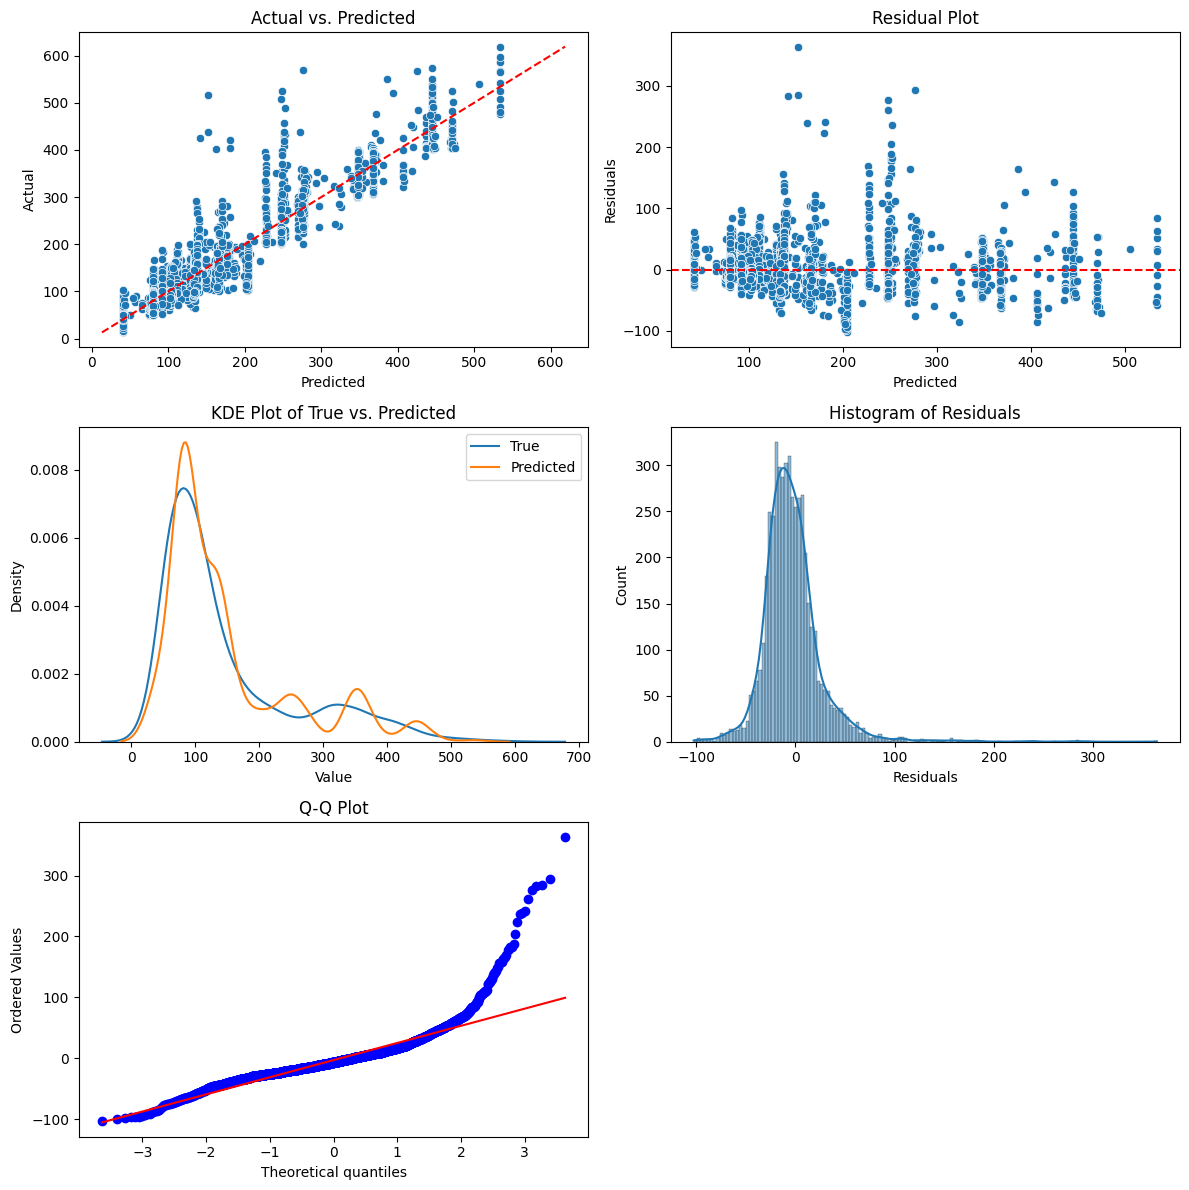

In [112]:
plot_regression_diagnostic_plots(
    results[2]["y_true"], results[2]["y_pred"], results[2]["residuals"]
)

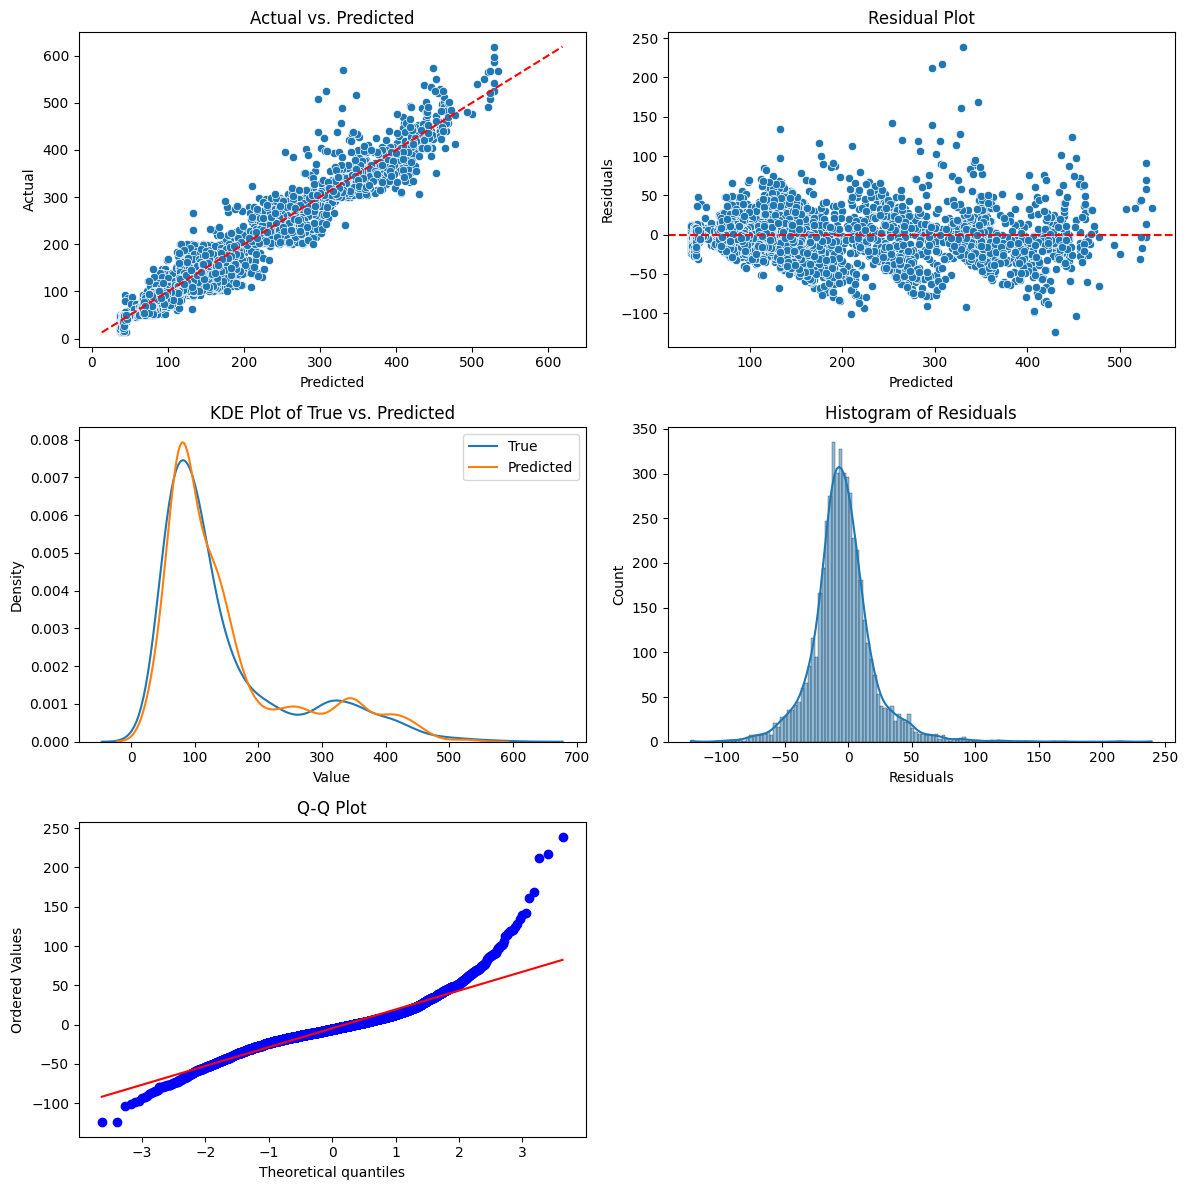

In [113]:
plot_regression_diagnostic_plots(
    results[3]["y_true"], results[3]["y_pred"], results[3]["residuals"]
)

In [114]:
%%time
best_models_1 = []
best_models_1.append(hyper_tune_regression_model(X_train, y_train, model_params['XGBRegressor'], n_iter = 200))

Best Score: -5387.9578
CPU times: total: 13.7 s
Wall time: 7min 18s


In [115]:
%%time
best_models_1.append(hyper_tune_regression_model(X_train, y_train, model_params['GradientBoostingRegressor'], n_iter = 30))

Best Score: -9866.9624
CPU times: total: 58 s
Wall time: 7min 18s


In [ ]:
%%time
best_models_1.append(hyper_tune_regression_model(X_train, y_train, model_params['RandomForestRegressor'], n_iter = 100))

In [ ]:
best_models_1

In [ ]:
results_1 = []

# Train and evaluate each model
for i, (best_model, _, _) in enumerate(best_models_1):
    # Train the model with best parameters
    best_model.fit(X_train, y_train)
    model_filename = f"model_no_{i + 1}.pkl"

    # Serialize the model to disk
    with open(model_filename, "wb") as f:
        pickle.dump(best_model, f)

    # Make predictions on test data
    y_pred = best_model.predict(X_test)

    # Calculate residuals
    residuals = y_test - y_pred

    # Calculate R^2 score
    r2 = r2_score(y_test, y_pred)

    # Calculate mean squared error
    mse = mean_squared_error(y_test, y_pred)

    # Store results_1 for the current model
    results_1.append(
        {
            "model_filename": model_filename,  # Store the file path instead of the model object
            "y_true": y_test,
            "y_pred": y_pred,
            "residuals": residuals,
            "r2_score": r2,
            "mse": mse,
        }
    )

# Print test scores for each model
for i, result in enumerate(results_1):
    print(f"Model {i+1}:")
    print(f"  R^2 Score: {result['r2_score']:.4f}")
    print(f"  Mean Squared Error: {result['mse']:.4f}")

In [ ]:
plot_regression_diagnostic_plots(
    results_1[0]["y_true"], results_1[0]["y_pred"], results_1[0]["residuals"]
)

In [ ]:
plot_regression_diagnostic_plots(
    results_1[1]["y_true"], results_1[1]["y_pred"], results_1[1]["residuals"]
)

In [ ]:
plot_regression_diagnostic_plots(
    results_1[2]["y_true"], results_1[2]["y_pred"], results_1[2]["residuals"]
)

In [ ]:
# %pip freeze > requirements.txt

In [ ]:
city_list = df["City"].unique().tolist()
print(city_list)

with open("city_list.pkl", "wb") as f:
    pickle.dump(city_list, f)

In [ ]:
feature_cols = train_df.columns.tolist()
feature_cols.pop(7)
print(feature_cols)

with open("feature_cols.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

# Model Interpretation


In [ ]:
# Train the Random Forest Regressor model
rf_model = pickle.load(open("model_no_3.pkl", "rb"))
rf_model.fit(X_train, y_train)

In [ ]:
# Get feature importances from the trained model
feature_importances = rf_model.feature_importances_

# Get the names of the features
feature_names = feature_cols

# Sort the features based on their importance scores
sorted_indices = feature_importances.argsort()
sorted_feature_importances = feature_importances[sorted_indices]
sorted_feature_names = [feature_names[i] for i in sorted_indices]

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(sorted_feature_names, sorted_feature_importances)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance Plot")
plt.show()

In [ ]:
import numpy as np

# Get the feature importances from the trained RandomForest model
feature_importances = rf_model.feature_importances_

# Compute contributions for each test instance
contributions = X_test * feature_importances  # Element-wise multiplication

# Get predicted probabilities or values
predictions = rf_model.predict(X_test)

# Compute contributions for the training set
train_contributions = X_train * feature_importances  # Element-wise multiplication

# Get predictions for the training set
train_predictions = rf_model.predict(X_train)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

# Load dataset
data = load_iris()
X, y = data.data, data.target

# Train a Random Forest model
model = RandomForestClassifier()
model.fit(X, y)

# Get feature importances
feature_importances = model.feature_importances_

# Bar plot of feature importances
plt.figure(figsize=(10, 5))
sns.barplot(x=np.arange(len(feature_importances)), y=feature_importances)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Feature Importances in Random Forest Model")
plt.show()
